In [2]:
import pandas as pd
from pathlib import Path
import re

def _canon(s: str) -> str:
    """Lowercase and remove non-alphanumerics for flexible header matching."""
    return re.sub(r'[^0-9a-z]+', '', str(s).lower())

def _attempt_map_columns(df, verbose=True):
    """
    Try to map a file *with headers* to ['time','rawpsi','tide_m','temp'].
    Returns (df_renamed, success_bool).
    """
    # Clean column names
    clean_cols = []
    for c in df.columns:
        c0 = str(c).replace("\ufeff", "").strip()
        c0 = re.sub(r'\s*\(\s*', '(', c0)  # "tide (m)" -> "tide(m)"
        c0 = re.sub(r'\s*\)\s*', ')', c0)  # "temperature (degC )" -> "temperature(degC)"
        clean_cols.append(c0)
    df.columns = clean_cols

    if verbose:
        print("Detected columns:", list(df.columns))

    # Known header variants
    targets = {
        "time":   {"time","datetime","timestamp","date","datestamp"},
        "rawpsi": {"pressurepsi","pressure","psi","pressurespsi","pressure(psi)"},
        "tide_m": {"tide","tidem","tide_m","tide(m)"},
        "temp":   {"temp","temperature","temperaturedegc","temperature(c)","temperature(degc)","tempc"},
    }

    rename_map = {}
    canon_to_src = { _canon(c): c for c in df.columns }

    for want, variants in targets.items():
        found = None
        # Exact variant match
        for v in variants:
            if v in canon_to_src:
                found = canon_to_src[v]
                break
        # Heuristics if needed
        if found is None:
            for k, src in canon_to_src.items():
                if want == "rawpsi" and (k.startswith("pressure") or k.endswith("psi") or "psi" in k):
                    found = src; break
                if want == "tide_m" and ("tide" in k):
                    found = src; break
                if want == "temp" and ("temp" in k or "temperature" in k):
                    found = src; break
                if want == "time" and ("time" in k or "date" in k or "stamp" in k):
                    found = src; break
        if found is not None:
            rename_map[found] = want

    if verbose:
        print("Column mapping:", rename_map)

    df2 = df.rename(columns=rename_map)
    required = ["time","rawpsi","tide_m","temp"]
    success = all(c in df2.columns for c in required)
    return df2, success

def convert_F2025_to_MJ03F(
    infile: str,
    outfile: str = 'MJ03F2025NANO.Data',
    *,
    rho_seawater=1025.0,
    g=9.80665,
    m_per_psi=0.67,        # set to None for physics-accurate (~0.6859215 m/psi)
    write_header=False,    # <<< make output headerless to match your reader
    verbose=True,
):
    """
    Convert an F2025_* pressure/tide/temp file to MJ03F-style:
      input columns (order): Time, Pressure(psi), tide(m), temperature(degC)
      output columns:        time, rawpsi, depth, temp

    depth (m) = rawpsi * m_per_psi - tide(m)
    """
    # Pass 1: try reading with header and map columns
    df = pd.read_csv(infile, sep=None, engine="python")
    df_try, ok = _attempt_map_columns(df.copy(), verbose=verbose)

    # If mapping failed, it's likely headerless: re-read with known schema
    if not ok:
        if verbose:
            print("No usable header detected. Re-reading as headerless...")
        df_try = pd.read_csv(
            infile, sep=None, engine="python",
            header=None, names=["time","rawpsi","tide_m","temp"]
        )

    # Parse types
    df_try["time"] = pd.to_datetime(df_try["time"], errors="coerce")
    df_try = df_try.dropna(subset=["time"]).sort_values("time")
    for c in ["rawpsi","tide_m","temp"]:
        df_try[c] = pd.to_numeric(df_try[c], errors="coerce")

    # If m_per_psi is None, compute physics-based conversion (≈0.6859215 m/psi @ 1025 kg/m³)
    if m_per_psi is None:
        PSI_TO_PA = 6894.757
        m_per_psi = PSI_TO_PA / (rho_seawater * g)

    # Detided depth
    df_try["depth"] = df_try["rawpsi"] * m_per_psi - df_try["tide_m"]

    out = df_try[["time","rawpsi","depth","temp"]].copy()

    # --- Ensure your downstream reader (header=None) is happy ---
    # 1) Format time consistently
    out["time"] = out["time"].dt.strftime("%Y-%m-%d %H:%M:%S")
    # 2) Write without header if requested
    Path(outfile).parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(outfile, index=False, header=write_header)  # <<< key change

    if verbose:
        print(f"m_per_psi used: {m_per_psi:.9f} m/psi")
        print(f"Wrote: {outfile} ({len(out)} rows) | header={write_header}")

    return out, outfile

# --- Run it (edit the filenames if needed) ---
if __name__ == "__main__":
    inpath  = "B2025_all.dat"           # your input file
    outpath = "MJ03B2025NANO.Data"      # desired output filename
    out_df, out_file = convert_F2025_to_MJ03F(
        inpath, outfile=outpath,
        m_per_psi=0.67, write_header=False, verbose=True
    )
    print(f"Done: {out_file}")


Detected columns: ['2025-01-01 00:00:00', '2274.667690067', '-0.398059994', '3.143778931']
Column mapping: {}
No usable header detected. Re-reading as headerless...
m_per_psi used: 0.670000000 m/psi
Wrote: MJ03B2025NANO.Data (1485526 rows) | header=False
Done: MJ03B2025NANO.Data


In [3]:
combined_df3=pd.read_pickle('/data/wsd02/maleen_data/Data2503.pkl')
combined_df2=pd.read_pickle('/data/wsd02/maleen_data/Data2502.pkl')
combined_df4=pd.read_pickle('/data/wsd02/maleen_data/Data2504.pkl')

In [4]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03F*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
cp = pd.concat(df_list, ignore_index=True).sort_values('time')

cp['time'] = pd.to_datetime(cp['time'])
cp['p']= (cp['depth']/0.67)
cp = cp.reset_index()
cp = cp.drop(columns=["index"])

In [5]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03E*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
ep = pd.concat(df_list, ignore_index=True).sort_values('time')

ep['time'] = pd.to_datetime(ep['time'])
ep['p']= (ep['depth']/0.67)
ep = ep.reset_index()
ep = ep.drop(columns=["index"])

In [6]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03B*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
wp = pd.concat(df_list, ignore_index=True).sort_values('time')

wp['time'] = pd.to_datetime(wp['time'])
wp['p']= (wp['depth']/0.67)
wp = wp.reset_index()
wp = wp.drop(columns=["index"])

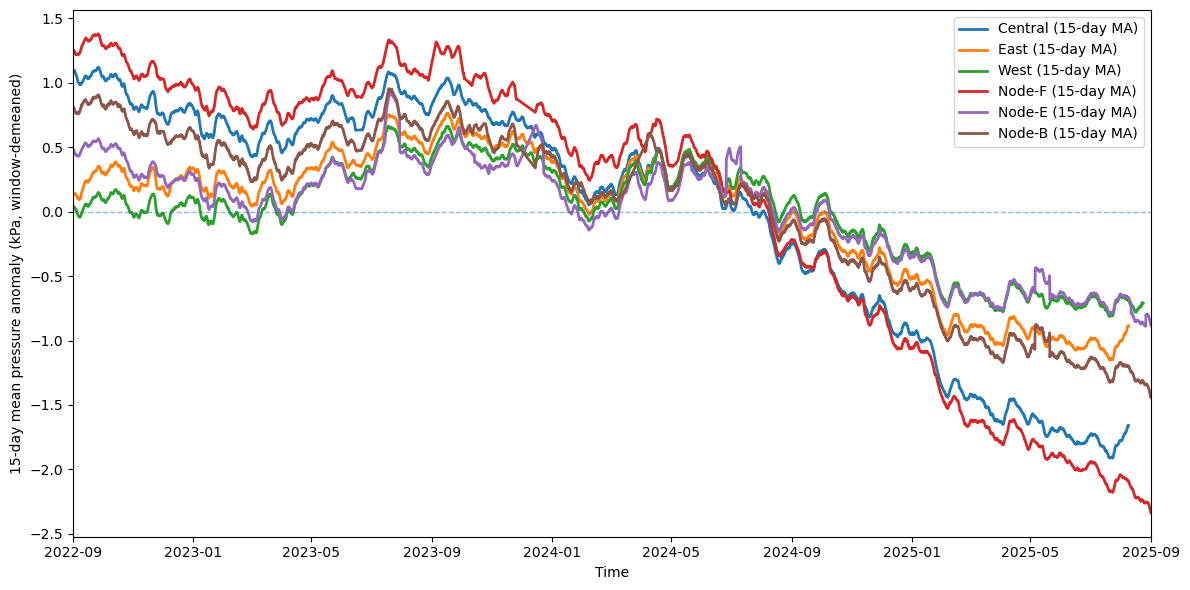

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

PSI_TO_KPA = 6.894757
COL_KPA = 'Corrected Pressure (kPa)'

start = pd.Timestamp('2022-09-01')
end   = pd.Timestamp('2025-09-01')

def to_ma15d(df, tcol, vcol, *, unit='kpa'):
    x = df[[tcol, vcol]].copy()
    x[tcol] = pd.to_datetime(x[tcol], errors='coerce')
    x = x.dropna(subset=[tcol]).sort_values(tcol)
    v = x[vcol].astype(float)
    if unit.lower() == 'psi':
        v = v * PSI_TO_KPA
    s = pd.Series(v.values, index=x[tcol])
    return s.rolling('15D', center=True, min_periods=1).mean()

def rebase_to_window(ma, start, end):
    w = ma.loc[start:end]
    return ma - w.mean()

# 15-day moving averages
ma_c  = to_ma15d(combined_df4, 'DateTime', COL_KPA, unit='kpa')
ma_e  = to_ma15d(combined_df2, 'DateTime', COL_KPA, unit='kpa')
ma_w  = to_ma15d(combined_df3, 'DateTime', COL_KPA, unit='kpa')
ma_cp = to_ma15d(cp,          'time',     'p',      unit='psi')  # cp.p is psi
ma_ep = to_ma15d(ep,          'time',     'p',      unit='psi')  # cp.p is psi
ma_wp = to_ma15d(wp,          'time',     'p',      unit='psi')  # cp.p is psi

# Re-baseline within the plotted window
ma_c  = rebase_to_window(ma_c,  start, end)
ma_e  = rebase_to_window(ma_e,  start, end)
ma_w  = rebase_to_window(ma_w,  start, end)
ma_cp = rebase_to_window(ma_cp, start, end)
ma_ep = rebase_to_window(ma_ep, start, end)
ma_wp = rebase_to_window(ma_wp, start, end)

# Plot only the window
plt.figure(figsize=(12, 6))
for s, name in [(ma_c, 'Central'), (ma_e, 'East'), (ma_w, 'West'), (ma_cp, 'Node-F'),(ma_ep, 'Node-E'),(ma_wp, 'Node-B')]:
    sw = s.loc[start:end]
    if not sw.empty:
        plt.plot(sw.index, sw.values, linewidth=2, label=f'{name} (15-day MA)')

plt.axhline(0, lw=1, ls='--', alpha=0.5)
plt.xlim(start, end)
plt.xlabel('Time')
plt.ylabel('15-day mean pressure anomaly (kPa, window-demeaned)')
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
# Save Node-F (F-node) pressure series to CSV
sw_f = ma_cp.loc[start:end].copy()

# Make a tidy DataFrame: time column + value column
df_f = sw_f.rename("pressure_anomaly_kPa_15dMA").to_frame()
df_f = df_f.reset_index().rename(columns={df_f.columns[0]: "Record Time"})

# Optional: make time timezone-naive ISO string (comment out if you want timezone kept)
# df_f["Record Time"] = pd.to_datetime(df_f["Record Time"]).dt.tz_convert(None)

out_csv = "F_node_pressure.csv"
df_f.to_csv(out_csv, index=False)

print(f"Saved {len(df_f)} rows to {out_csv}")


Saved 5837043 rows to F_node_pressure.csv


In [8]:
ma_cp

time
2016-01-01 00:00:00    17.013886
2016-01-01 00:00:15    17.013883
2016-01-01 00:00:30    17.013879
2016-01-01 00:00:45    17.013875
2016-01-01 00:01:00    17.013871
                         ...    
2025-09-15 00:27:00    -2.544110
2025-09-15 00:27:15    -2.544108
2025-09-15 00:27:30    -2.544105
2025-09-15 00:27:45    -2.544102
2025-09-15 00:28:00    -2.544099
Length: 19357227, dtype: float64

In [17]:
import numpy as np
import pandas as pd

# ---------- Config ----------
# Define your three fit segments (edit as needed)
SEGMENTS = [
    ("2022-09-01", "2023-09-01"),
    ("2023-09-01", "2025-09-01"),
#    ("2024-07-01", "2025-09-01"),
]
TOL = "2H"      # asof merge tolerance
MIN_PTS = 25    # minimum points per segment to fit

# ---------- Helpers ----------
def asof_merge_pn_pe_pc(ma_c, ma_e, ma_cp, ma_ep, ma_wp, ma_w, tol="2H"):
    """
    Align Pn (ma_c), Pe (ma_e), Pc (ma_cp) onto a common timeline (Pn) for drift fitting.
    Ensures the time column is named 'time' and sorted. Drops duplicates & NaNs.
    """

    def s2df(s, name):
        # ensure datetime index, drop bad stamps
        s = s.dropna()
        s.index = pd.to_datetime(s.index, errors="coerce")
        s = s[~s.index.isna()]
        # make a DataFrame with a guaranteed 'time' column
        df = s.rename(name).rename_axis("time").reset_index()
        # normalize timezone if present
        try:
            df["time"] = df["time"].dt.tz_convert(None)
        except Exception:
            try:
                df["time"] = df["time"].dt.tz_localize(None)
            except Exception:
                pass
        # sort & de-dup
        df = df.sort_values("time")
        df = df[~df["time"].duplicated(keep="first")]
        return df

    pn = s2df(ma_c,  "Pn")   # Pn (ma_c)
    pe = s2df(ma_e,  "Pe")   # Pe (ma_e)
    pc = s2df(ma_cp, "Pc")   # Pc (ma_cp)
    ep = s2df(ma_ep, "ep")
    wp = s2df(ma_wp, "wp")
    pw = s2df(ma_w,  "Pw")
    
    # as-of merges on sorted 'time' column, progressively requiring columns
    m = pd.merge_asof(pn, pe, on="time", direction="nearest", tolerance=pd.Timedelta(tol))
    m = pd.merge_asof(m.dropna(subset=["Pe"]).sort_values("time"),
                      pc, on="time", direction="nearest", tolerance=pd.Timedelta(tol))
    m = pd.merge_asof(m.dropna(subset=["Pc"]).sort_values("time"),
                      ep, on="time", direction="nearest", tolerance=pd.Timedelta(tol))
    m = pd.merge_asof(m.dropna(subset=["ep"]).sort_values("time"),
                      wp, on="time", direction="nearest", tolerance=pd.Timedelta(tol))
    m = pd.merge_asof(m.dropna(subset=["wp"]).sort_values("time"),
                      pw, on="time", direction="nearest", tolerance=pd.Timedelta(tol))    

    # keep rows with all aligned signals present
    m = (m.dropna(subset=["Pe", "Pc", "ep", "wp", "Pw"])
           .sort_values("time")
           .reset_index(drop=True))

    # nice column order
    cols = ["time", "Pn", "Pe", "Pc", "ep", "wp", "Pw"]
    m = m[[c for c in cols if c in m.columns]]

    return m


def fit_segment(df_seg):
    """
    Fit (Pn - Pe) ≈ a + b*(Pc - meanPc) + c*t', where t' is time (days) around the segment center.
    Returns dict with a,b,c and diagnostics.
    """
    # Demean within the segment to stabilize a; keep Pe in the difference
    dPn = df_seg["Pn"] - df_seg["Pn"].mean()
    dPe = df_seg["Pe"] - df_seg["Pe"].mean()
    dPc = df_seg["Pc"] - df_seg["Pc"].mean()

    Y = (dPn - dPe).to_numpy(dtype=float)
    X = dPc.to_numpy(dtype=float)

    t_mid = df_seg["time"].iloc[0] + (df_seg["time"].iloc[-1] - df_seg["time"].iloc[0]) / 2
    t_days = (df_seg["time"] - t_mid).dt.total_seconds().to_numpy() / 86400.0

    # Design: [1, X, t']
    A = np.column_stack([np.ones_like(X), X, t_days])
    a, b, c = np.linalg.lstsq(A, Y, rcond=None)[0]  # Y ≈ a + b*X + c*t'

    Yhat = A @ np.array([a,b,c])
    resid = Y - Yhat
    rmse = float(np.sqrt(np.mean(resid**2)))

    return {
        "a": float(a), "b": float(b), "c": float(c),  # c is drift rate kPa/day (Pn minus Pe)
        "rmse_kPa": rmse,
        "n": int(len(df_seg)),
        "t_mid": t_mid,
    }

def build_piecewise_correction(times, segments, fits):
    """
    Build a continuous, piecewise-linear drift correction for Pn using c (kPa/day) per segment.
    `times` should be the merged["time"] Series. We return a Series indexed by the SAME ROW INDEX
    (not by the datetime values) to avoid boolean-index alignment issues.
    """
    # Ensure Series of datetimes, no tz
    times = pd.to_datetime(times, errors="coerce")
    try:
        times = times.dt.tz_convert(None)
    except Exception:
        try:
            times = times.dt.tz_localize(None)
        except Exception:
            pass

    # Correction lives on the same *row index* as `times`
    out = pd.Series(0.0, index=times.index, dtype=float)
    base = 0.0  # cumulative continuity offset carried across segments

    for (seg_start, seg_end), f in zip(segments, fits):
        seg_start = pd.Timestamp(seg_start)
        seg_end   = pd.Timestamp(seg_end)

        # Boolean mask WITH THE SAME INDEX AS `out`
        mask = (times >= seg_start) & (times < seg_end)
        if not mask.any():
            continue

        # Time relative to segment center, in days (Series -> use .dt.total_seconds())
        t_days = (times[mask] - f["t_mid"]).dt.total_seconds() / 86400.0

        # Raw segment correction about the center
        seg_corr = f["c"] * t_days  # kPa

        # Shift to enforce continuity at boundaries
        start_days = (seg_start - f["t_mid"]).total_seconds() / 86400.0
        end_days   = (seg_end   - f["t_mid"]).total_seconds() / 86400.0
        start_val  = f["c"] * start_days
        end_val    = f["c"] * end_days

        seg_corr = seg_corr + (base - start_val)

        # Write back on the SAME index as mask/out
        out.loc[mask] = seg_corr.values

        # Carry continuity forward
        base = base + (end_val - start_val)

    return out



# ---------- Run ----------
# 1) Align series (expects ma_c, ma_e, ma_cp exist from your earlier code)
merged = asof_merge_pn_pe_pc(ma_c, ma_e, ma_cp, ma_ep, ma_wp, ma_w, tol=TOL)





Pn RAW+DRIFT model FIT over 2023-03-01 to 2025-09-01
a (kPa)           = -0.0839
b (kPa/kPa)       = 0.8443   # Pc coupling (RAW)
c (kPa/yr)        = -0.0043   # linear drift rate
RMSE (kPa)        = 0.0326
N (15d-MA points) = 4591


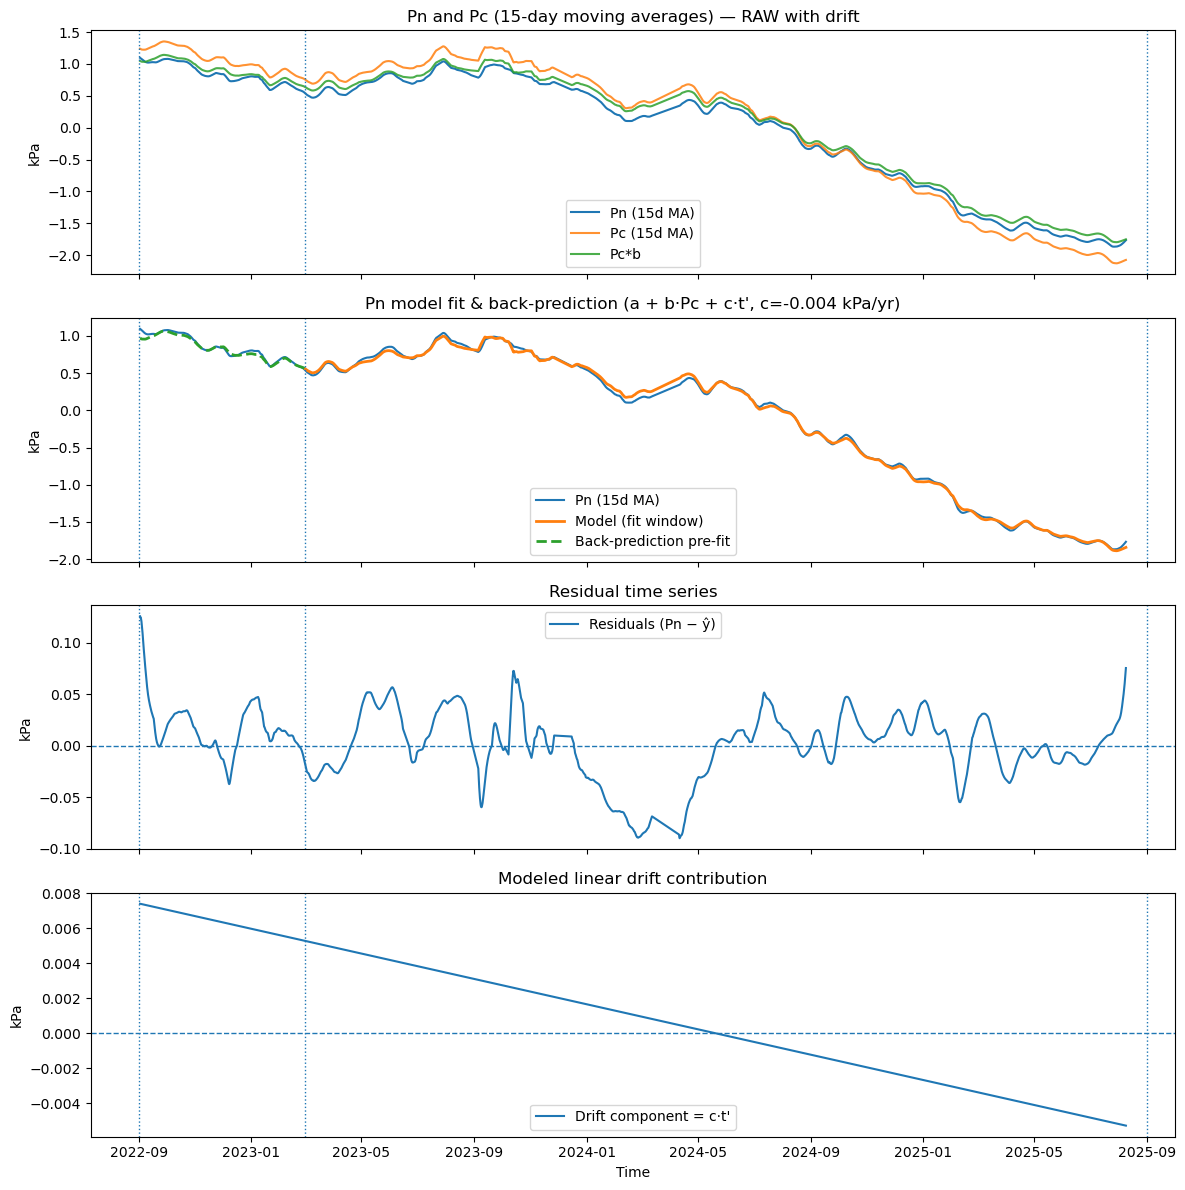

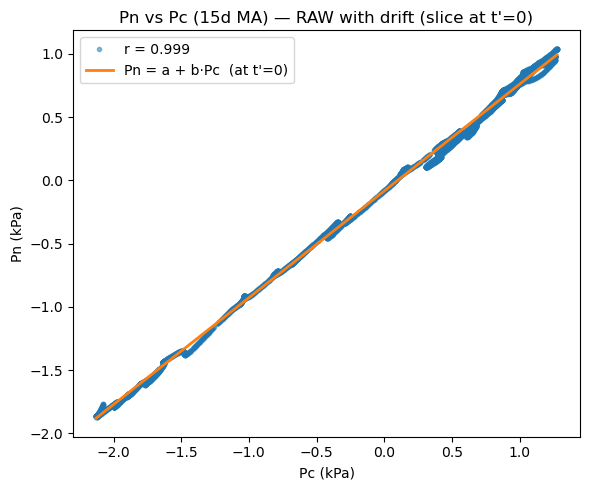

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) windows + prep -----------
show0 = pd.Timestamp('2022-09-01')   # show from here (adds the prior year)
t0    = pd.Timestamp('2023-03-01')   # fit start
t1    = pd.Timestamp('2025-09-01')   # fit end (exclusive)

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
# drop tz to avoid mixed tz errors
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

df = df.dropna(subset=["time", "Pn", "Pc"]).sort_values("time")

# Keep a display window covering the extra year + fit window
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No data in the combined show window (2022-09 to 2025-09).")

# 15-day moving average (time-based) for smoother comparisons
tmp_show = df_show.set_index("time").sort_index()
ma_full = tmp_show[["Pn", "Pc"]].rolling("15D").mean().dropna().copy()
ma_full["time"] = ma_full.index

# Extract the fit subset from the MA data (strictly in-window)
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("Pn model fit window (2023-03 to 2025-09) has no data after filtering/MA.")

# ----------- 1) time regressor (center time, keep Pc RAW) -----------
t_mid_fit = ma_fit.index[0] + (ma_fit.index[-1] - ma_fit.index[0]) / 2
# years relative to mid-fit
ma_fit["tprime_years"] = (ma_fit.index - t_mid_fit).total_seconds() / (365.25 * 86400.0)

# ----------- 2) RAW-with-drift fit: Pn = a + b*Pc + c*t' -----------
y = ma_fit["Pn"].to_numpy(float)
X = np.column_stack([
    np.ones(len(ma_fit)),                 # intercept a
    ma_fit["Pc"].to_numpy(float),         # RAW Pc (no demeaning)
    ma_fit["tprime_years"].to_numpy(float) # time term t'
])
coef, *_ = np.linalg.lstsq(X, y, rcond=None)
a_n, b_n, c_n = coef

# Diagnostics on the FIT window
ma_fit["Pn_hat"] = X @ coef
ma_fit["resid"]  = y - ma_fit["Pn_hat"]

print(f"\nPn RAW+DRIFT model FIT over {t0.date()} to {t1.date()}")
print(f"a (kPa)           = {a_n:.4f}")
print(f"b (kPa/kPa)       = {b_n:.4f}   # Pc coupling (RAW)")
print(f"c (kPa/yr)        = {c_n:.4f}   # linear drift rate")
print(f"RMSE (kPa)        = {np.sqrt(np.mean(ma_fit['resid']**2)):.4f}")
print(f"N (15d-MA points) = {len(ma_fit)}")

# ----------- 3) apply across FULL (show) window with SAME t' centering -----------
ma_full["tprime_years"] = (ma_full.index - t_mid_fit).total_seconds() / (365.25 * 86400.0)
ma_full["Pn_hat"] = (a_n
                     + b_n * ma_full["Pc"].to_numpy(float)
                     + c_n * ma_full["tprime_years"].to_numpy(float))
ma_full["resid"]  = ma_full["Pn"] - ma_full["Pn_hat"]
ma_full["drift_component"] = c_n * ma_full["tprime_years"]

# Masks for plotting
pre_mask  = ma_full.index < t0
fit_mask  = (ma_full.index >= t0) & (ma_full.index < t1)

# ----------- 4) plots -----------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# (a) 15-day MAs: Pn and Pc across FULL window
axes[0].plot(ma_full["time"], ma_full["Pn"], label="Pn (15d MA)")
axes[0].plot(ma_full["time"], ma_full["Pc"], label="Pc (15d MA)", alpha=0.85)
axes[0].plot(ma_full["time"], ma_full["Pc"]*b_n, label="Pc*b", alpha=0.85)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("Pn and Pc (15-day moving averages) — RAW with drift")

# (b) Pn vs model (solid in fit window, dashed back-prediction pre-fit)
axes[1].plot(ma_full["time"], ma_full["Pn"], label="Pn (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "Pn_hat"],
             label="Model (fit window)", linewidth=2)
axes[1].plot(ma_full.loc[pre_mask, "time"], ma_full.loc[pre_mask, "Pn_hat"],
             linestyle="--", linewidth=2, label="Back-prediction pre-fit")
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title(f"Pn model fit & back-prediction (a + b·Pc + c·t', c={c_n:.3f} kPa/yr)")

# (c) residuals across FULL window
axes[2].plot(ma_full["time"], ma_full["resid"], label="Residuals (Pn − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].legend(loc="best")
axes[2].set_title("Residual time series")

# (d) isolated drift component
axes[3].plot(ma_full["time"], ma_full["drift_component"], label="Drift component = c·t'")
axes[3].axhline(0, ls="--", lw=1)
axes[3].set_ylabel("kPa"); axes[3].set_xlabel("Time"); axes[3].legend(loc="best")
axes[3].set_title("Modeled linear drift contribution")

# window markers
for ax in axes:
    ax.axvline(show0, ls=":", lw=1)
    ax.axvline(t0,    ls=":", lw=1)
    ax.axvline(t1,    ls=":", lw=1)

plt.tight_layout(); plt.show()

# ----------- 5) cross-plot: Pc vs Pn (FIT window, RAW X) -----------
r = np.corrcoef(ma_fit["Pc"], ma_fit["Pn"])[0, 1]
plt.figure(figsize=(6,5))
plt.plot(ma_fit["Pc"], ma_fit["Pn"], '.', alpha=0.5, label=f"r = {r:.3f}")
xg = np.linspace(ma_fit["Pc"].min(), ma_fit["Pc"].max(), 200)
yg = a_n + b_n * xg                 # at t' = 0 (mid-fit)
plt.plot(xg, yg, lw=2, label="Pn = a + b·Pc  (at t'=0)")
plt.xlabel("Pc (kPa)"); plt.ylabel("Pn (kPa)")
plt.title("Pn vs Pc (15d MA) — RAW with drift (slice at t'=0)")
plt.legend(); plt.tight_layout(); plt.show()


In [20]:
# ----------- 6) start→finish depth deltas (cm) using first/last 30 points -----------
CM_PER_KPA = 9.94  # cm per kPa (positive pressure => deeper)

def window_means(s, n=30):
    s = s.dropna()
    n = min(n, len(s)//2) if len(s) >= 2 else 0
    if n == 0:
        return np.nan, np.nan, None, None
    first = s.iloc[:n].mean()
    last  = s.iloc[-n:].mean()
    return first, last, s.index[0], s.index[-1]

# Series (kPa)
Pn_kPa   = ma_full["Pn"]
Pc_kPa   = ma_full["Pc"]
drift_kPa = ma_full["drift_component"]  # c_n * t'

# (1) Before drift correction: use raw Pn MA
f1, l1, t_first, t_last = window_means(Pn_kPa, n=30)
d_depth_before_cm = (l1 - f1) * CM_PER_KPA

# (2) After drift correction: remove modeled linear drift from Pn
Pn_dc_kPa = (Pn_kPa - drift_kPa)
f2, l2, _, _ = window_means(Pn_dc_kPa, n=30)
d_depth_after_cm = (l2 - f2) * CM_PER_KPA

# (3) Reference (assumed drift-free) station used for fitting: Pc
f3, l3, _, _ = window_means(Pc_kPa, n=30)
d_depth_ref_cm = (l3 - f3) * CM_PER_KPA

print("\nDepth change (first 30 vs last 30 points of 15-day MAs)")
print(f"Window start: {t_first:%Y-%m-%d}, window end: {t_last:%Y-%m-%d}")
print(f"  • BEFORE drift correction (Pn raw):           {d_depth_before_cm:+.2f} cm  ( + = deeper )")
print(f"  • AFTER  drift correction (Pn − c·t′):        {d_depth_after_cm:+.2f} cm")
print(f"  • Reference (no-drift) station (Pc) change:   {d_depth_ref_cm:+.2f} cm")

# Optional: bundle into a small summary DataFrame you can reuse/log
summary = pd.DataFrame({
    "metric": ["before_drift", "after_drift", "reference_Pc"],
    "delta_depth_cm": [d_depth_before_cm, d_depth_after_cm, d_depth_ref_cm]
})
print("\nSummary (cm):")
print(summary.to_string(index=False))

# ----------- 6b) also print start/end depths (cm) for each case -----------

def to_depth_cm(p_kpa):  # +kPa => deeper (cm)
    return p_kpa * CM_PER_KPA

rows = []

def add_row(label, p_first, p_last):
    d_first = to_depth_cm(p_first) if np.isfinite(p_first) else np.nan
    d_last  = to_depth_cm(p_last)  if np.isfinite(p_last)  else np.nan
    d_delta = d_last - d_first
    rows.append({
        "metric": label,
        "start_depth_cm": d_first,
        "end_depth_cm": d_last,
        "delta_depth_cm": d_delta
    })

add_row("Pn BEFORE drift", f1, l1)
add_row("Pn AFTER drift",  f2, l2)
add_row("Reference Pc",    f3, l3)

depth_summary = pd.DataFrame(rows)

print("\nStart/End Depths (using first/last 30-point MAs; + = deeper):")
for _, r in depth_summary.iterrows():
    print(f"  • {r['metric']:<16}  start = {r['start_depth_cm']:+.2f} cm, "
          f"end = {r['end_depth_cm']:+.2f} cm,  Δ = {r['delta_depth_cm']:+.2f} cm")

# (optional) keep as variable for later saving/plotting
# depth_summary




Depth change (first 30 vs last 30 points of 15-day MAs)
Window start: 2022-09-02, window end: 2025-08-09
  • BEFORE drift correction (Pn raw):           -28.54 cm  ( + = deeper )
  • AFTER  drift correction (Pn − c·t′):        -28.41 cm
  • Reference (no-drift) station (Pc) change:   -32.97 cm

Summary (cm):
      metric  delta_depth_cm
before_drift      -28.536169
 after_drift      -28.410727
reference_Pc      -32.972741

Start/End Depths (using first/last 30-point MAs; + = deeper):
  • Pn BEFORE drift   start = +10.63 cm, end = -17.91 cm,  Δ = -28.54 cm
  • Pn AFTER drift    start = +10.56 cm, end = -17.85 cm,  Δ = -28.41 cm
  • Reference Pc      start = +12.20 cm, end = -20.77 cm,  Δ = -32.97 cm


In [49]:
# Create DataFrame with time and drift-corrected pressure
output_df = pd.DataFrame({
    'time': Pc_kPa.index,
    'pressure_kPa': Pc_kPa.values
})

# Save to CSV
output_file = 'Pc_drifcor.csv'
output_df.to_csv(output_file, index=False)
print(f"\nSaved {len(output_df)} records to {output_file}")
print(f"Columns: {list(output_df.columns)}")
print(f"\nFirst few rows:")
print(output_df.head())


Saved 5600 records to Pc_drifcor.csv
Columns: ['time', 'pressure_kPa']

First few rows:
                 time  pressure_kPa
0 2022-09-02 11:45:00      1.239792
1 2022-09-02 15:45:00      1.238478
2 2022-09-02 19:45:00      1.236705
3 2022-09-02 23:45:00      1.235661
4 2022-09-03 03:45:00      1.233970


In [21]:
# Create DataFrame with time and drift-corrected pressure
output_df = pd.DataFrame({
    'time': Pn_dc_kPa.index,
    'pressure_drift_corrected_kPa': Pn_dc_kPa.values
})

# Save to CSV
output_file = 'Pn_drifcor.csv'
output_df.to_csv(output_file, index=False)
print(f"\nSaved {len(output_df)} records to {output_file}")
print(f"Columns: {list(output_df.columns)}")
print(f"\nFirst few rows:")
print(output_df.head())


Saved 5600 records to Pn_drifcor.csv
Columns: ['time', 'pressure_drift_corrected_kPa']

First few rows:
                 time  pressure_drift_corrected_kPa
0 2022-09-02 11:45:00                      1.088396
1 2022-09-02 15:45:00                      1.086190
2 2022-09-02 19:45:00                      1.085087
3 2022-09-02 23:45:00                      1.083782
4 2022-09-03 03:45:00                      1.081601


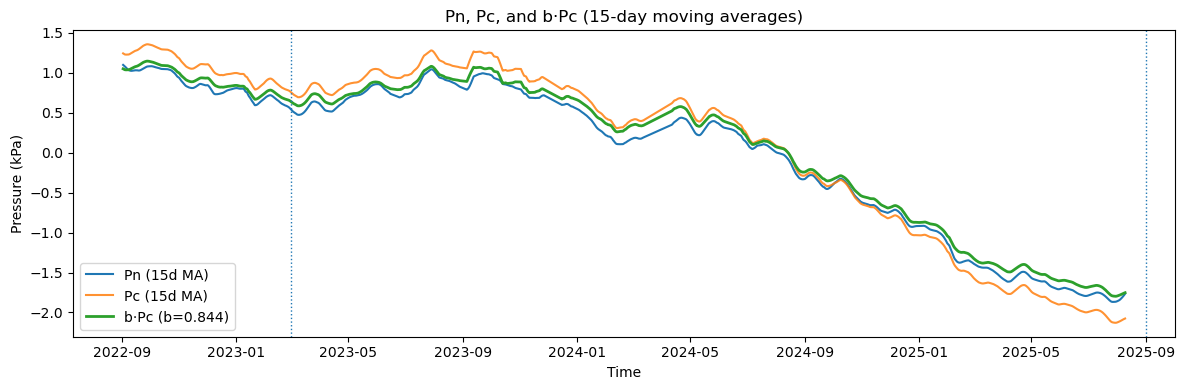

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- windows ----
show0 = pd.Timestamp('2022-09-01')
t0    = pd.Timestamp('2023-03-01')
t1    = pd.Timestamp('2025-09-01')

# ---- prep ----
df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass
df = df.dropna(subset=["time","Pn","Pc"]).sort_values("time")

# show window + 15d MA
x = df[(df["time"] >= show0) & (df["time"] < t1)].set_index("time").sort_index()
ma = x[["Pn","Pc"]].rolling("15D").mean().dropna()

# fit window to estimate b in: Pn = a + b*Pc + c*t'
fit = ma[(ma.index >= t0) & (ma.index < t1)].copy()
t_mid = fit.index[0] + (fit.index[-1] - fit.index[0]) / 2
tprime = (fit.index - t_mid).total_seconds() / (365.25*86400.0)
X = np.column_stack([np.ones(len(fit)), fit["Pc"].to_numpy(float), tprime.to_numpy(float)])
y = fit["Pn"].to_numpy(float)
a, b, c = np.linalg.lstsq(X, y, rcond=None)[0]

# compute b*Pc over the full MA series
ma["b_times_Pc"] = b * ma["Pc"].to_numpy(float)

# ---- one plot ----
plt.figure(figsize=(12,4))
plt.plot(ma.index, ma["Pn"], label="Pn (15d MA)")
plt.plot(ma.index, ma["Pc"], label="Pc (15d MA)", alpha=0.85)
plt.plot(ma.index, ma["b_times_Pc"], label=f"b·Pc (b={b:.3f})", linewidth=2)
plt.axvline(t0, ls=":", lw=1); plt.axvline(t1, ls=":", lw=1)
plt.ylabel("Pressure (kPa)"); plt.xlabel("Time")
plt.title("Pn, Pc, and b·Pc (15-day moving averages)")
plt.legend(); plt.tight_layout(); plt.show()



Pn RAW model FIT over 2023-03-01 to 2025-09-01
a_n (kPa)         = -0.0837
b_n (kPa/kPa)     = 0.8470   # Pc coupling
RMSE (kPa)        = 0.0326
N (15d-MA points) = 4591


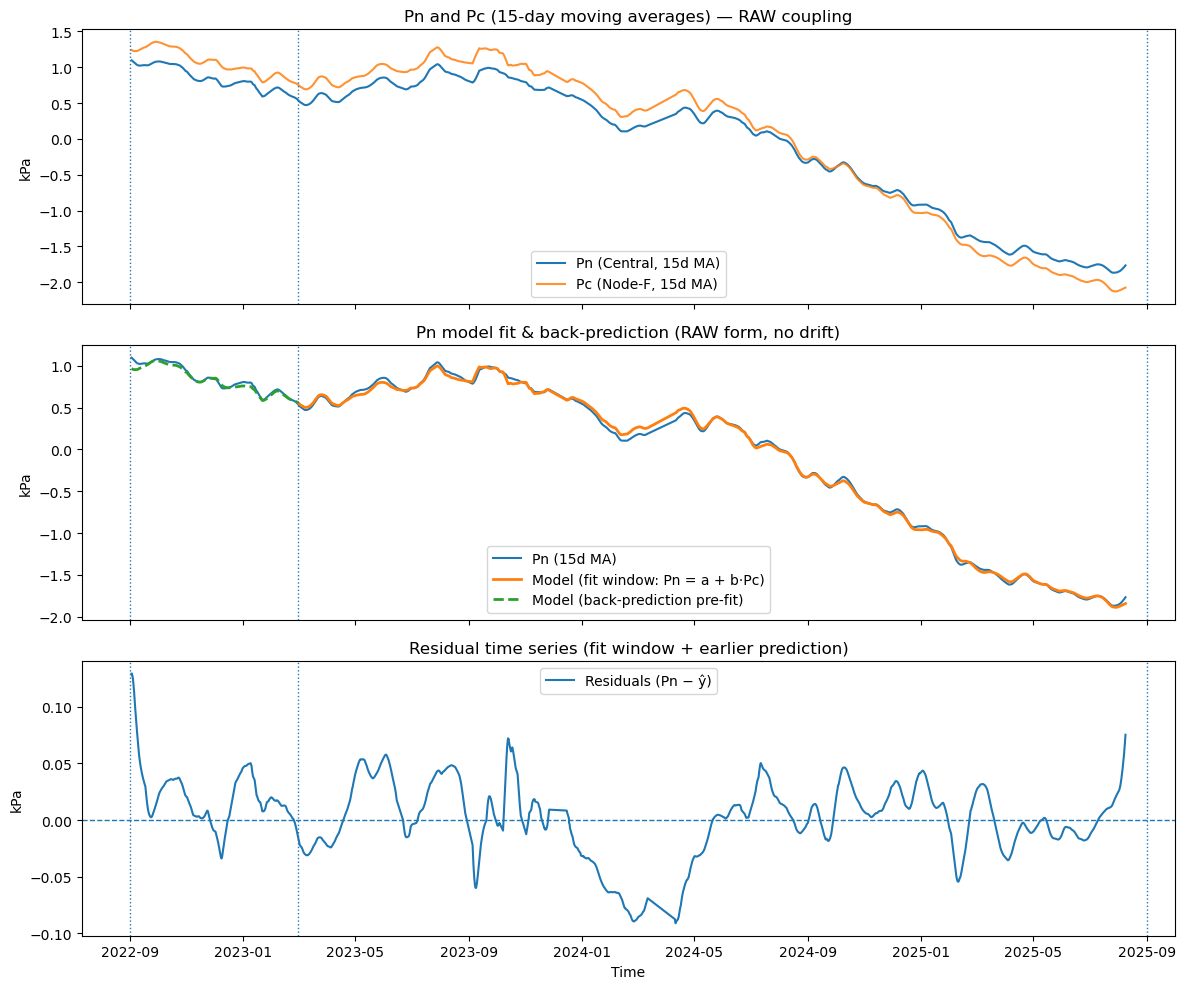

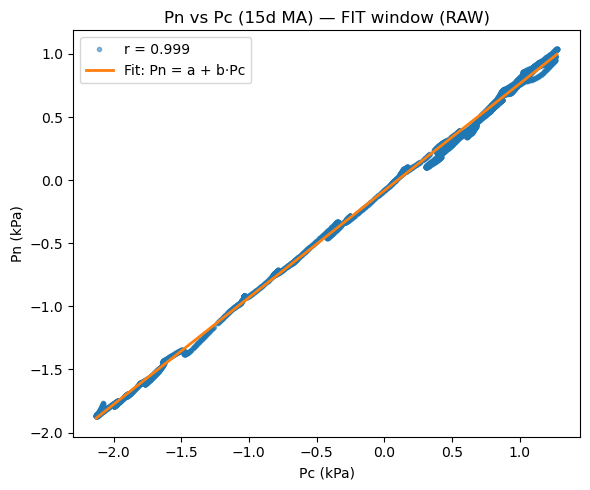

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) windows + prep -----------
show0 = pd.Timestamp('2022-09-01')   # show from here (adds the prior year)
t0    = pd.Timestamp('2023-03-01')   # fit start
t1    = pd.Timestamp('2025-09-01')   # fit end (exclusive)

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# drop tz to avoid mixed tz errors
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

df = df.dropna(subset=["time", "Pn", "Pc"]).sort_values("time")

# Keep a display window covering the extra year + fit window
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No data in the combined show window (2022-09 to 2025-09).")

# 15-day moving average (time-based) for smoother comparisons
tmp_show = df_show.set_index("time").sort_index()
ma_full = tmp_show[["Pn", "Pc"]].rolling("15D").mean().dropna().copy()
ma_full["time"] = ma_full.index

# Extract the fit subset from the MA data (strictly in-window)
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("Pn model fit window (2023-03 to 2025-09) has no data after filtering/MA.")

# ----------- 1) RAW fit on the FIT window: Pn = a + b*Pc -----------
y = ma_fit["Pn"].to_numpy(float)
X = np.column_stack([np.ones(len(ma_fit)), ma_fit["Pc"].to_numpy(float)])
coef, *_ = np.linalg.lstsq(X, y, rcond=None)
a_n, b_n = coef

# Diagnostics on the FIT window
ma_fit["Pn_hat"] = X @ coef
ma_fit["resid"]  = y - ma_fit["Pn_hat"]

print(f"\nPn RAW model FIT over {t0.date()} to {t1.date()}")
print(f"a_n (kPa)         = {a_n:.4f}")
print(f"b_n (kPa/kPa)     = {b_n:.4f}   # Pc coupling")
print(f"RMSE (kPa)        = {np.sqrt(np.mean(ma_fit['resid']**2)):.4f}")
print(f"N (15d-MA points) = {len(ma_fit)}")

# ----------- 2) Apply RAW fit across FULL (show) window -----------
ma_full["Pn_hat"] = a_n + b_n * ma_full["Pc"].to_numpy(float)
ma_full["resid"]  = ma_full["Pn"] - ma_full["Pn_hat"]

# Masks for plotting (to style fit vs back-prediction differently)
pre_mask  = ma_full.index < t0   # 2022-09 -> 2023-03 (model prediction)
fit_mask  = (ma_full.index >= t0) & (ma_full.index < t1)

# ----------- 3) plots -----------
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# (a) 15-day MAs: Pn and Pc across FULL window
axes[0].plot(ma_full["time"], ma_full["Pn"], label="Pn (Central, 15d MA)")
axes[0].plot(ma_full["time"], ma_full["Pc"], label="Pc (Node-F, 15d MA)", alpha=0.85)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("Pn and Pc (15-day moving averages) — RAW coupling")

# (b) Pn vs model (solid in fit window, dashed back-prediction pre-fit)
axes[1].plot(ma_full["time"], ma_full["Pn"], label="Pn (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "Pn_hat"],
             label="Model (fit window: Pn = a + b·Pc)", linewidth=2)
axes[1].plot(ma_full.loc[pre_mask, "time"], ma_full.loc[pre_mask, "Pn_hat"],
             linestyle="--", linewidth=2, label="Model (back-prediction pre-fit)")
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title("Pn model fit & back-prediction (RAW form, no drift)")

# (c) residuals across FULL window (note: pre-fit are prediction errors)
axes[2].plot(ma_full["time"], ma_full["resid"], label="Residuals (Pn − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].set_xlabel("Time"); axes[2].legend(loc="best")
axes[2].set_title("Residual time series (fit window + earlier prediction)")

# window markers
for ax in axes:
    ax.axvline(show0, ls=":", lw=1)  # start of display window
    ax.axvline(t0,    ls=":", lw=1)  # start of fit window
    ax.axvline(t1,    ls=":", lw=1)  # end of fit window

plt.tight_layout(); plt.show()

# ----------- 4) quick cross-plot: Pc vs Pn (FIT window only, RAW form) -----------
r = np.corrcoef(ma_fit["Pc"], ma_fit["Pn"])[0, 1]
plt.figure(figsize=(6,5))
plt.plot(ma_fit["Pc"], ma_fit["Pn"], '.', alpha=0.5, label=f"r = {r:.3f}")
xg = np.linspace(ma_fit["Pc"].min(), ma_fit["Pc"].max(), 200)
yg = a_n + b_n * xg
plt.plot(xg, yg, lw=2, label="Fit: Pn = a + b·Pc")
plt.xlabel("Pc (kPa)"); plt.ylabel("Pn (kPa)")
plt.title("Pn vs Pc (15d MA) — FIT window (RAW)")
plt.legend(); plt.tight_layout(); plt.show()



Pe RAW+DRIFT model FIT over 2023-03-01 to 2025-09-01
a (kPa)     = 0.0081
b (kPa/kPa) = 0.7182   # Pc coupling (RAW)
c (kPa/yr)  = 0.3335   # linear drift rate
RMSE (kPa)  = 0.0388
N (15d-MA)  = 4591


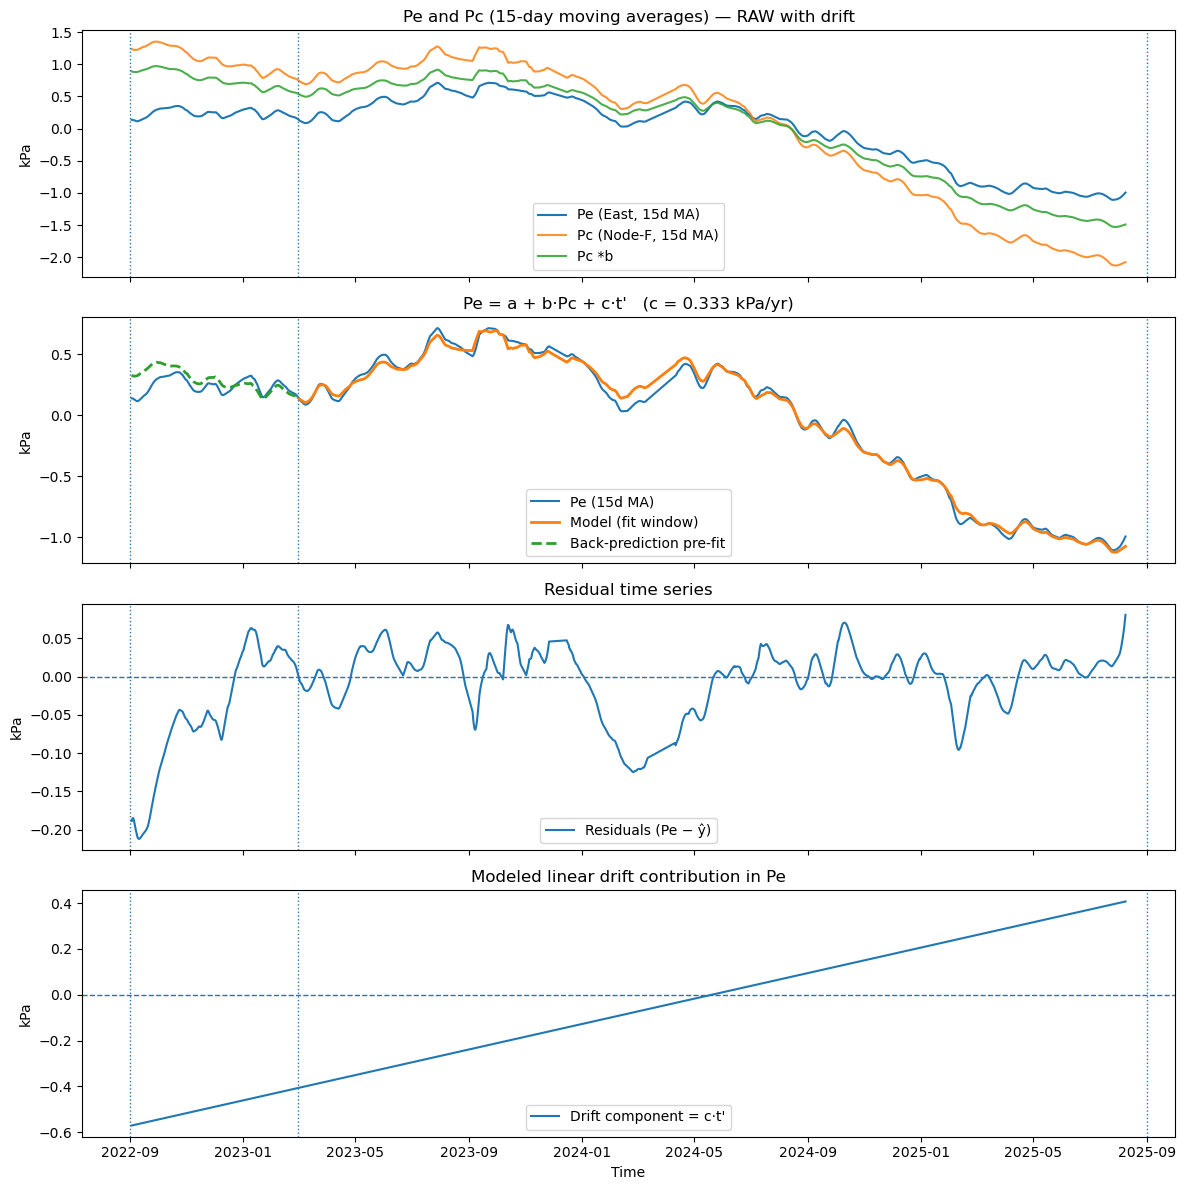

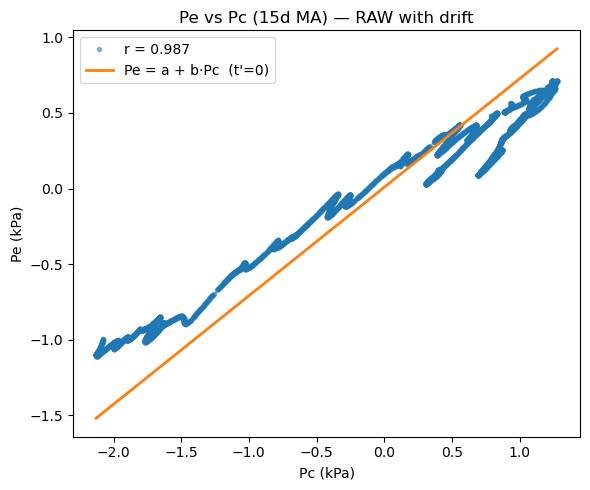

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) windows + prep -----------
show0 = pd.Timestamp('2022-09-01')
t0    = pd.Timestamp('2023-03-01')
t1    = pd.Timestamp('2025-09-01')

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

df = df.dropna(subset=["time", "Pe", "Pc"]).sort_values("time")

# show window
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No data in the combined show window (2022-09 to 2025-09).")

# 15-day moving average
tmp_show = df_show.set_index("time").sort_index()
ma_full = tmp_show[["Pe", "Pc"]].rolling("15D").mean().dropna().copy()
ma_full["time"] = ma_full.index

# fit subset
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("Pe model fit window (2023-03 to 2025-09) has no data after filtering/MA.")

# ----------- 1) time regressor (keep Pc RAW) -----------
t_mid_fit = ma_fit.index[0] + (ma_fit.index[-1] - ma_fit.index[0]) / 2
ma_fit["tprime_years"] = (ma_fit.index - t_mid_fit).total_seconds() / (365.25 * 86400.0)

# ----------- 2) RAW-with-drift fit: Pe = a + b*Pc + c*t' -----------
y = ma_fit["Pe"].to_numpy(float)
X = np.column_stack([
    np.ones(len(ma_fit)),                   # a
    ma_fit["Pc"].to_numpy(float),           # b * Pc  (RAW)
    ma_fit["tprime_years"].to_numpy(float)  # c * t'
])
coef, *_ = np.linalg.lstsq(X, y, rcond=None)
a_e, b_e, c_e = coef

# Diagnostics on FIT window
ma_fit["Pe_hat"] = X @ coef
ma_fit["resid"]  = y - ma_fit["Pe_hat"]

print(f"\nPe RAW+DRIFT model FIT over {t0.date()} to {t1.date()}")
print(f"a (kPa)     = {a_e:.4f}")
print(f"b (kPa/kPa) = {b_e:.4f}   # Pc coupling (RAW)")
print(f"c (kPa/yr)  = {c_e:.4f}   # linear drift rate")
print(f"RMSE (kPa)  = {np.sqrt(np.mean(ma_fit['resid']**2)):.4f}")
print(f"N (15d-MA)  = {len(ma_fit)}")

# ----------- 3) apply across FULL window (same t' centering) -----------
ma_full["tprime_years"] = (ma_full.index - t_mid_fit).total_seconds() / (365.25 * 86400.0)
ma_full["Pe_hat"] = (a_e
                     + b_e * ma_full["Pc"].to_numpy(float)
                     + c_e * ma_full["tprime_years"].to_numpy(float))
ma_full["resid"]  = ma_full["Pe"] - ma_full["Pe_hat"]
ma_full["drift_component"] = c_e * ma_full["tprime_years"]

# Masks
pre_mask = ma_full.index < t0
fit_mask = (ma_full.index >= t0) & (ma_full.index < t1)

# ----------- 4) plots -----------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# (a) series
axes[0].plot(ma_full["time"], ma_full["Pe"], label="Pe (East, 15d MA)")
axes[0].plot(ma_full["time"], ma_full["Pc"], label="Pc (Node-F, 15d MA)", alpha=0.85)
axes[0].plot(ma_full["time"], ma_full["Pc"]*b_e, label="Pc *b", alpha=0.85)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("Pe and Pc (15-day moving averages) — RAW with drift")

# (b) model vs data
axes[1].plot(ma_full["time"], ma_full["Pe"], label="Pe (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "Pe_hat"],
             label="Model (fit window)", linewidth=2)
axes[1].plot(ma_full.loc[pre_mask, "time"], ma_full.loc[pre_mask, "Pe_hat"],
             linestyle="--", linewidth=2, label="Back-prediction pre-fit")
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title(f"Pe = a + b·Pc + c·t'   (c = {c_e:.3f} kPa/yr)")

# (c) residuals
axes[2].plot(ma_full["time"], ma_full["resid"], label="Residuals (Pe − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].legend(loc="best")
axes[2].set_title("Residual time series")

# (d) drift component
axes[3].plot(ma_full["time"], ma_full["drift_component"], label="Drift component = c·t'")
axes[3].axhline(0, ls="--", lw=1)
axes[3].set_ylabel("kPa"); axes[3].set_xlabel("Time"); axes[3].legend(loc="best")
axes[3].set_title("Modeled linear drift contribution in Pe")

# markers
for ax in axes:
    ax.axvline(show0, ls=":", lw=1)
    ax.axvline(t0,    ls=":", lw=1)
    ax.axvline(t1,    ls=":", lw=1)

plt.tight_layout(); plt.show()

# ----------- 5) cross-plot: Pc vs Pe (FIT window; slice at t'=0) -----------
r = np.corrcoef(ma_fit["Pc"], ma_fit["Pe"])[0, 1]
plt.figure(figsize=(6,5))
plt.plot(ma_fit["Pc"], ma_fit["Pe"], '.', alpha=0.5, label=f"r = {r:.3f}")
xg = np.linspace(ma_fit["Pc"].min(), ma_fit["Pc"].max(), 200)
yg = a_e + b_e * xg                    # at t' = 0
plt.plot(xg, yg, lw=2, label="Pe = a + b·Pc  (t'=0)")
plt.xlabel("Pc (kPa)"); plt.ylabel("Pe (kPa)")
plt.title("Pe vs Pc (15d MA) — RAW with drift")
plt.legend(); plt.tight_layout(); plt.show()


In [25]:
# ----------- 6) start→finish depth metrics for Pe/Pc (cm) -----------
CM_PER_KPA = 9.94  # cm per kPa ( +kPa => deeper )

def window_means(s, n=30):
    s = s.dropna()
    n = min(n, len(s)//2) if len(s) >= 2 else 0
    if n == 0:
        return np.nan, np.nan, None, None
    first = s.iloc[:n].mean()
    last  = s.iloc[-n:].mean()
    return first, last, s.index[0], s.index[-1]

def to_depth_cm(p_kpa):
    return p_kpa * CM_PER_KPA

# Series (kPa)
Pe_kPa     = ma_full["Pe"]
Pc_kPa     = ma_full["Pc"]
drift_kPa  = ma_full["drift_component"]  # c_n * t' for Pe model

# (1) BEFORE drift: raw Pe MA
f1, l1, t_first, t_last = window_means(Pe_kPa, n=30)
d_depth_before_cm = (l1 - f1) * CM_PER_KPA

# (2) AFTER drift: remove modeled linear drift
Pe_dc_kPa = Pe_kPa - drift_kPa
f2, l2, _, _ = window_means(Pe_dc_kPa, n=30)
d_depth_after_cm = (l2 - f2) * CM_PER_KPA

# (3) Reference (assumed no drift) used for fitting: Pc
f3, l3, _, _ = window_means(Pc_kPa, n=30)
d_depth_ref_cm = (l3 - f3) * CM_PER_KPA

print("\nDepth change (first 30 vs last 30 of 15-day MAs) — Pe/Pc")
print(f"Window start: {t_first:%Y-%m-%d}, window end: {t_last:%Y-%m-%d}")
print(f"  • BEFORE drift correction (Pe raw):           {d_depth_before_cm:+.2f} cm  ( + = deeper )")
print(f"  • AFTER  drift correction (Pe − c·t′):        {d_depth_after_cm:+.2f} cm")
print(f"  • Reference (no-drift) station (Pc) change:   {d_depth_ref_cm:+.2f} cm")

# ----------- 6b) also print start/end depths (cm) -----------
rows = []
def add_row(label, p_first, p_last):
    d_first = to_depth_cm(p_first) if np.isfinite(p_first) else np.nan
    d_last  = to_depth_cm(p_last)  if np.isfinite(p_last)  else np.nan
    rows.append({
        "metric": label,
        "start_depth_cm": d_first,
        "end_depth_cm": d_last,
        "delta_depth_cm": d_last - d_first
    })

add_row("Pe BEFORE drift", f1, l1)
add_row("Pe AFTER drift",  f2, l2)
add_row("Reference Pc",    f3, l3)

depth_summary_pe = pd.DataFrame(rows)

print("\nStart/End Depths (first/last 30-point MAs; + = deeper):")
for _, r in depth_summary_pe.iterrows():
    print(f"  • {r['metric']:<16}  start = {r['start_depth_cm']:+.2f} cm, "
          f"end = {r['end_depth_cm']:+.2f} cm,  Δ = {r['delta_depth_cm']:+.2f} cm")

# Optional: keep the summary table around
# depth_summary_pe



Depth change (first 30 vs last 30 of 15-day MAs) — Pe/Pc
Window start: 2022-09-02, window end: 2025-08-09
  • BEFORE drift correction (Pe raw):           -11.54 cm  ( + = deeper )
  • AFTER  drift correction (Pe − c·t′):        -21.22 cm
  • Reference (no-drift) station (Pc) change:   -32.97 cm

Start/End Depths (first/last 30-point MAs; + = deeper):
  • Pe BEFORE drift   start = +1.29 cm, end = -10.25 cm,  Δ = -11.54 cm
  • Pe AFTER drift    start = +6.95 cm, end = -14.27 cm,  Δ = -21.22 cm
  • Reference Pc      start = +12.20 cm, end = -20.77 cm,  Δ = -32.97 cm


In [26]:
# Create DataFrame with time and drift-corrected pressure
output_df = pd.DataFrame({
    'time': Pe_dc_kPa.index,
    'pressure_drift_corrected_kPa': Pe_dc_kPa.values
})

# Save to CSV
output_file = 'Pe_drifcor.csv'
output_df.to_csv(output_file, index=False)
print(f"\nSaved {len(output_df)} records to {output_file}")
print(f"Columns: {list(output_df.columns)}")
print(f"\nFirst few rows:")
print(output_df.head())


Saved 5600 records to Pe_drifcor.csv
Columns: ['time', 'pressure_drift_corrected_kPa']

First few rows:
                 time  pressure_drift_corrected_kPa
0 2022-09-02 11:45:00                      0.709636
1 2022-09-02 15:45:00                      0.708727
2 2022-09-02 19:45:00                      0.708697
3 2022-09-02 23:45:00                      0.708554
4 2022-09-03 03:45:00                      0.707647


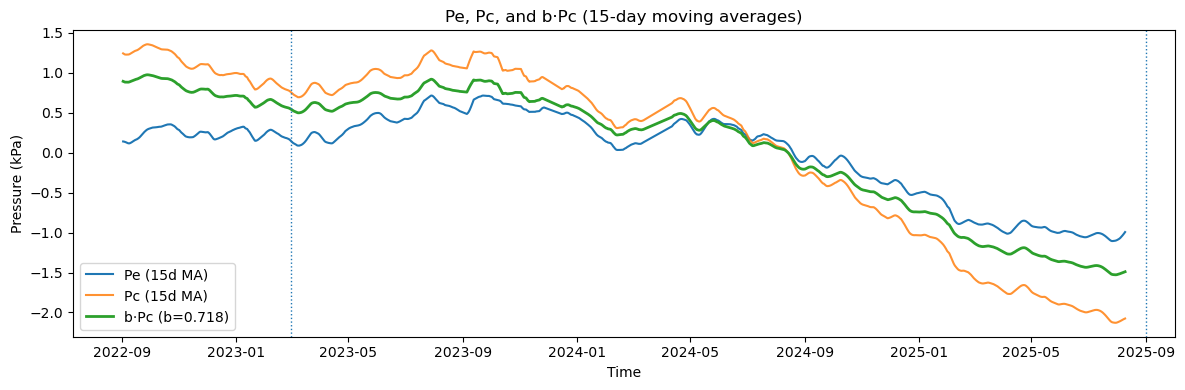

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- windows ----
show0 = pd.Timestamp('2022-09-01')
t0    = pd.Timestamp('2023-03-01')
t1    = pd.Timestamp('2025-09-01')

# ---- prep ----
df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass
df = df.dropna(subset=["time","Pe","Pc"]).sort_values("time")

# show window + 15d MA
x = df[(df["time"] >= show0) & (df["time"] < t1)].set_index("time").sort_index()
ma = x[["Pe","Pc"]].rolling("15D").mean().dropna()

# fit window to estimate b in: Pe = a + b*Pc + c*t'
fit = ma[(ma.index >= t0) & (ma.index < t1)].copy()
if fit.empty:
    raise ValueError("Pe fit window (2023-03 to 2025-09) has no data after MA.")
t_mid = fit.index[0] + (fit.index[-1] - fit.index[0]) / 2
tprime = (fit.index - t_mid).total_seconds() / (365.25*86400.0)

X = np.column_stack([np.ones(len(fit)), fit["Pc"].to_numpy(float), tprime.to_numpy(float)])
y = fit["Pe"].to_numpy(float)
a, b, c = np.linalg.lstsq(X, y, rcond=None)[0]

# compute b*Pc over the full MA series
ma["b_times_Pc"] = b * ma["Pc"].to_numpy(float)

# ---- one plot ----
plt.figure(figsize=(12,4))
plt.plot(ma.index, ma["Pe"], label="Pe (15d MA)")
plt.plot(ma.index, ma["Pc"], label="Pc (15d MA)", alpha=0.85)
plt.plot(ma.index, ma["b_times_Pc"], label=f"b·Pc (b={b:.3f})", linewidth=2)
plt.axvline(t0, ls=":", lw=1); plt.axvline(t1, ls=":", lw=1)
plt.ylabel("Pressure (kPa)"); plt.xlabel("Time")
plt.title("Pe, Pc, and b·Pc (15-day moving averages)")
plt.legend(); plt.tight_layout(); plt.show()



Pe RAW model FIT over 2023-03-01 to 2025-09-01 (no drift)
a (kPa)           = -0.0107
b (kPa/kPa)       = 0.5114   # Pc coupling (RAW)
RMSE (kPa)        = 0.0929
N (15d-MA points) = 4591


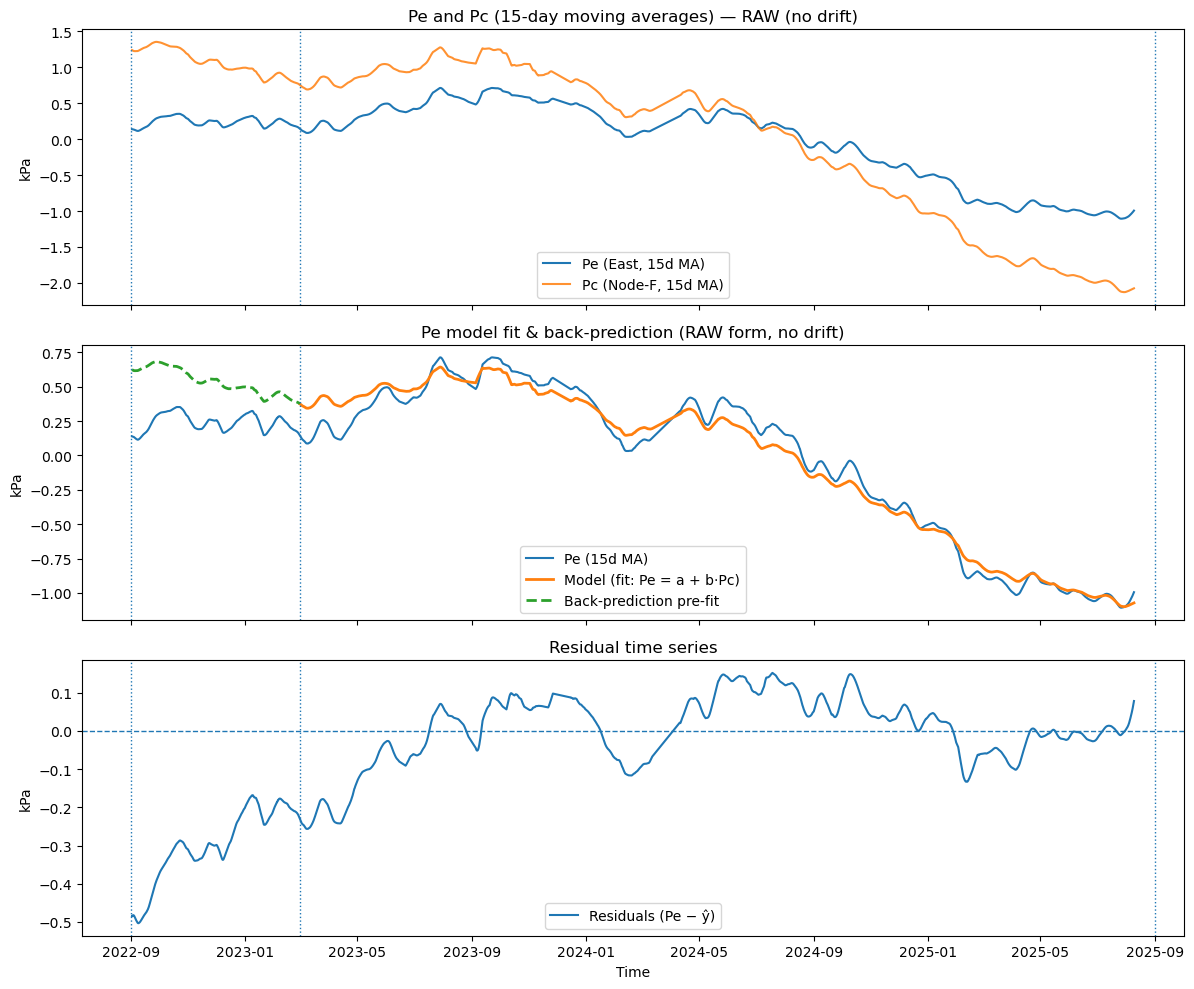

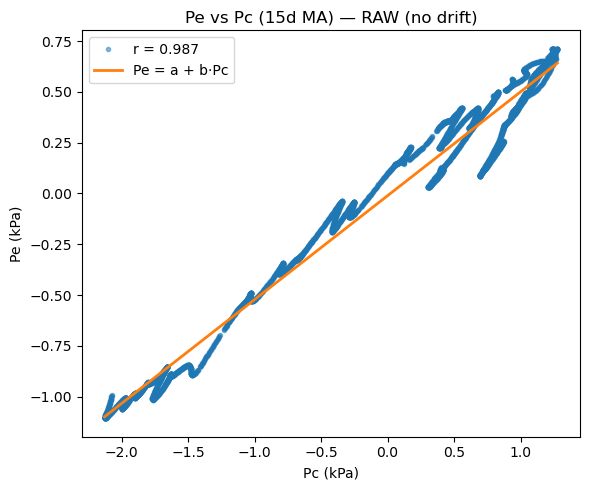

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) windows + prep -----------
show0 = pd.Timestamp('2022-09-01')   # show from here
t0    = pd.Timestamp('2023-03-01')   # fit start
t1    = pd.Timestamp('2025-09-01')   # fit end (exclusive)

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# drop tz to avoid mixed tz errors
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

df = df.dropna(subset=["time", "Pe", "Pc"]).sort_values("time")

# show window covering extra year + fit window
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No data in the combined show window (2022-09 to 2025-09).")

# 15-day moving average (time-based)
tmp_show = df_show.set_index("time").sort_index()
ma_full = tmp_show[["Pe", "Pc"]].rolling("15D").mean().dropna().copy()
ma_full["time"] = ma_full.index

# fit subset
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("Pe model fit window (2023-03 to 2025-09) has no data after filtering/MA.")

# ----------- 1) RAW fit (no drift): Pe = a + b*Pc -----------
y = ma_fit["Pe"].to_numpy(float)
X = np.column_stack([np.ones(len(ma_fit)), ma_fit["Pc"].to_numpy(float)])
coef, *_ = np.linalg.lstsq(X, y, rcond=None)
a_e, b_e = coef

# diagnostics on FIT window
ma_fit["Pe_hat"] = X @ coef
ma_fit["resid"]  = y - ma_fit["Pe_hat"]

print(f"\nPe RAW model FIT over {t0.date()} to {t1.date()} (no drift)")
print(f"a (kPa)           = {a_e:.4f}")
print(f"b (kPa/kPa)       = {b_e:.4f}   # Pc coupling (RAW)")
print(f"RMSE (kPa)        = {np.sqrt(np.mean(ma_fit['resid']**2)):.4f}")
print(f"N (15d-MA points) = {len(ma_fit)}")

# ----------- 2) apply across FULL window -----------
ma_full["Pe_hat"] = a_e + b_e * ma_full["Pc"].to_numpy(float)
ma_full["resid"]  = ma_full["Pe"] - ma_full["Pe_hat"]

# masks for plotting
pre_mask = ma_full.index < t0
fit_mask = (ma_full.index >= t0) & (ma_full.index < t1)

# ----------- 3) plots -----------
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# (a) time series
axes[0].plot(ma_full["time"], ma_full["Pe"], label="Pe (East, 15d MA)")
axes[0].plot(ma_full["time"], ma_full["Pc"], label="Pc (Node-F, 15d MA)", alpha=0.85)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("Pe and Pc (15-day moving averages) — RAW (no drift)")

# (b) model vs data
axes[1].plot(ma_full["time"], ma_full["Pe"], label="Pe (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "Pe_hat"],
             label="Model (fit: Pe = a + b·Pc)", linewidth=2)
axes[1].plot(ma_full.loc[pre_mask, "time"], ma_full.loc[pre_mask, "Pe_hat"],
             linestyle="--", linewidth=2, label="Back-prediction pre-fit")
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title("Pe model fit & back-prediction (RAW form, no drift)")

# (c) residuals
axes[2].plot(ma_full["time"], ma_full["resid"], label="Residuals (Pe − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].set_xlabel("Time"); axes[2].legend(loc="best")
axes[2].set_title("Residual time series")

# window markers
for ax in axes:
    ax.axvline(show0, ls=":", lw=1)
    ax.axvline(t0,    ls=":", lw=1)
    ax.axvline(t1,    ls=":", lw=1)

plt.tight_layout(); plt.show()

# ----------- 4) cross-plot (fit window) -----------
r = np.corrcoef(ma_fit["Pc"], ma_fit["Pe"])[0, 1]
plt.figure(figsize=(6,5))
plt.plot(ma_fit["Pc"], ma_fit["Pe"], '.', alpha=0.5, label=f"r = {r:.3f}")
xg = np.linspace(ma_fit["Pc"].min(), ma_fit["Pc"].max(), 200)
yg = a_e + b_e * xg
plt.plot(xg, yg, lw=2, label="Pe = a + b·Pc")
plt.xlabel("Pc (kPa)"); plt.ylabel("Pe (kPa)")
plt.title("Pe vs Pc (15d MA) — RAW (no drift)")
plt.legend(); plt.tight_layout(); plt.show()



Pe RAW+DRIFT FIT over 2023-03-01 to 2025-09-01
a (kPa)     = -0.0325
b (kPa/kPa) = 1.1341   # coupling to ep (RAW)
c (kPa/yr)  = -0.1625   # linear drift rate in Pe
RMSE (kPa)  = 0.0746
N (15d-MA)  = 4591


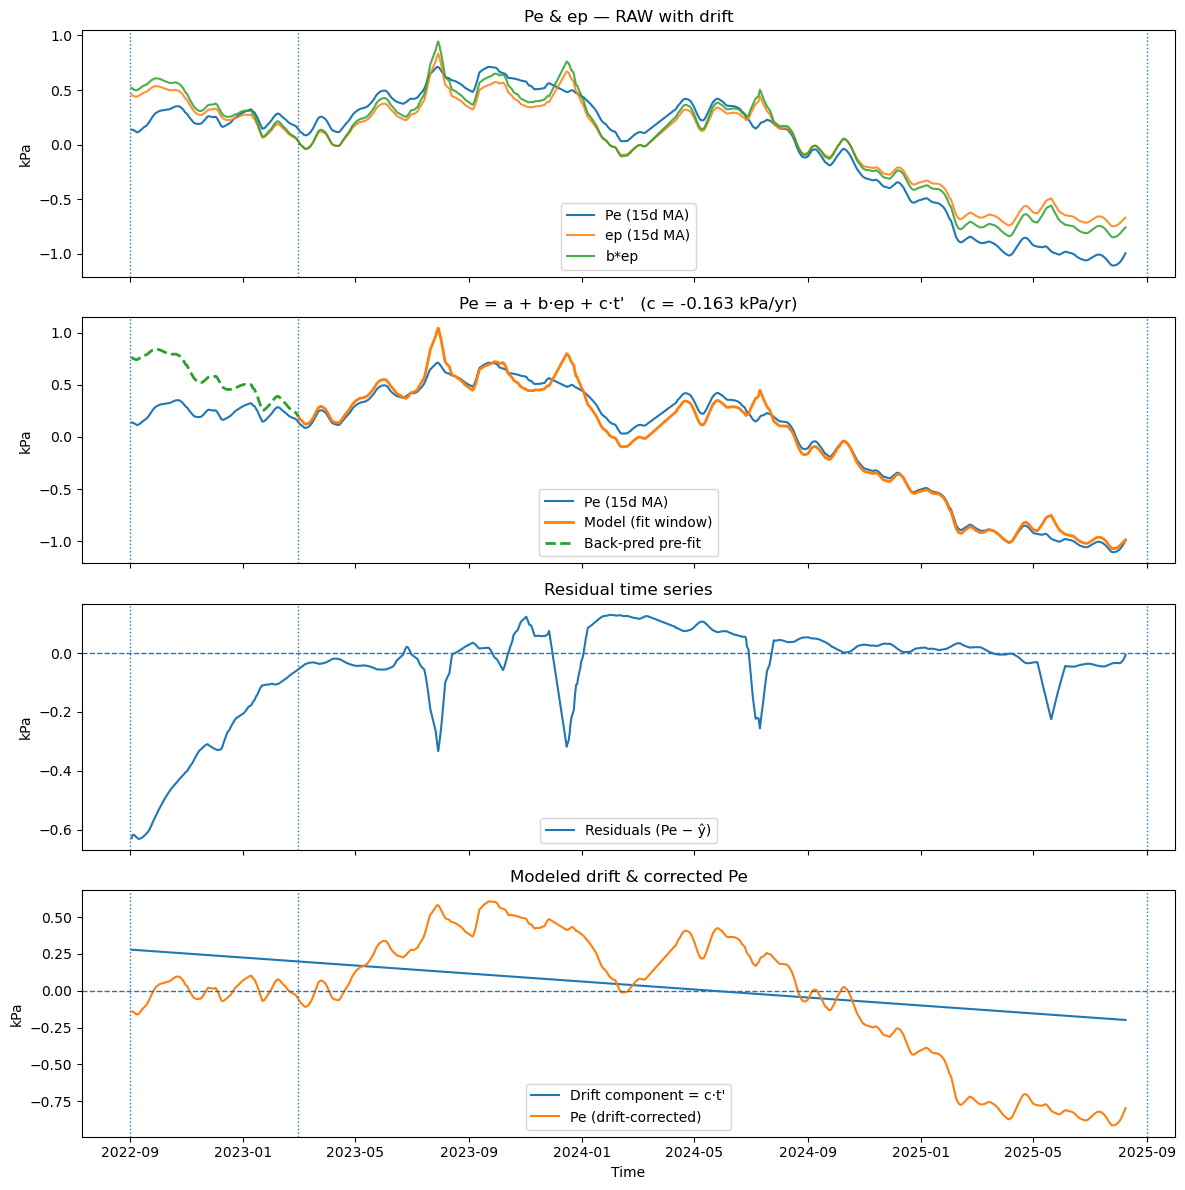

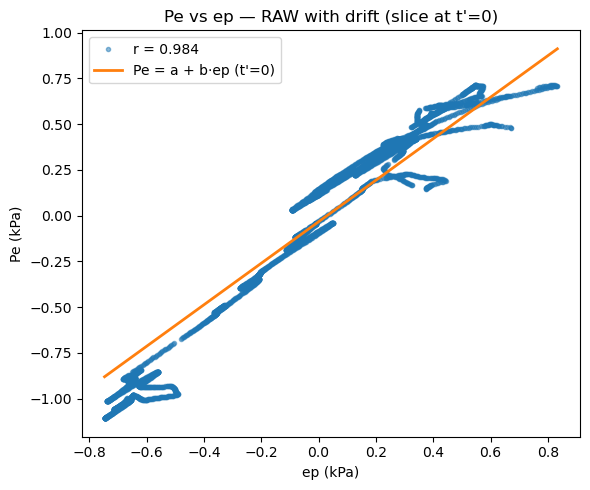

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) windows + prep -----------
show0 = pd.Timestamp('2022-09-01')   # display starts here (adds prior year)
t0    = pd.Timestamp('2023-03-01')   # fit start
t1    = pd.Timestamp('2025-09-01')   # fit end (exclusive)

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

# Keep rows with Pe (drifting) and ep (drift-free)
df = df.dropna(subset=["time", "Pe", "ep"]).sort_values("time")

# Show window
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("Show window (2022-09..2025-09) has no data.")

# 15-day moving average (optional smoothing—doesn't affect 'raw' vs 'centered')
tmp_show = df_show.set_index("time").sort_index()
ma_full = tmp_show[["Pe", "ep"]].rolling("15D").mean().dropna().copy()
ma_full["time"] = ma_full.index

# Fit subset
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("Fit window (2023-03..2025-09) has no data after MA.")

# ----------- 1) RAW + DRIFT: regressors -----------
t_mid_fit = ma_fit.index[0] + (ma_fit.index[-1] - ma_fit.index[0]) / 2
to_years = 365.25 * 86400.0
ma_fit["tprime_years"] = (ma_fit.index - t_mid_fit).total_seconds() / to_years  # centered years

# ----------- 2) Fit Pe = a + b*ep + c*t' -----------
y = ma_fit["Pe"].to_numpy(float)
X = np.column_stack([
    np.ones(len(ma_fit)),                     # a
    ma_fit["ep"].to_numpy(float),             # b * ep  (RAW, no demeaning)
    ma_fit["tprime_years"].to_numpy(float),   # c * t'
])
coef, *_ = np.linalg.lstsq(X, y, rcond=None)
a_e, b_e, c_e = coef

# Diagnostics
ma_fit["Pe_hat"] = X @ coef
ma_fit["resid"]  = y - ma_fit["Pe_hat"]

print(f"\nPe RAW+DRIFT FIT over {t0.date()} to {t1.date()}")
print(f"a (kPa)     = {a_e:.4f}")
print(f"b (kPa/kPa) = {b_e:.4f}   # coupling to ep (RAW)")
print(f"c (kPa/yr)  = {c_e:.4f}   # linear drift rate in Pe")
print(f"RMSE (kPa)  = {np.sqrt(np.mean(ma_fit['resid']**2)):.4f}")
print(f"N (15d-MA)  = {len(ma_fit)}")

# ----------- 3) Apply across FULL window (same time centering) -----------
ma_full["tprime_years"] = (ma_full.index - t_mid_fit).total_seconds() / to_years
ma_full["Pe_hat"] = a_e + b_e * ma_full["ep"].to_numpy(float) + c_e * ma_full["tprime_years"].to_numpy(float)
ma_full["resid"]  = ma_full["Pe"] - ma_full["Pe_hat"]
ma_full["drift_component"] = c_e * ma_full["tprime_years"]
ma_full["Pe_driftcorr"] = ma_full["Pe"] - ma_full["drift_component"]

# Masks
pre_mask = ma_full.index < t0
fit_mask = (ma_full.index >= t0) & (ma_full.index < t1)

# ----------- 4) Plots -----------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(ma_full["time"], ma_full["Pe"], label="Pe (15d MA)")
axes[0].plot(ma_full["time"], ma_full["ep"], label="ep (15d MA)", alpha=0.85)
axes[0].plot(ma_full["time"], ma_full["ep"]*b_e, label="b*ep", alpha=0.85)
axes[0].set_ylabel("kPa"); axes[0].legend(); axes[0].set_title("Pe & ep — RAW with drift")

axes[1].plot(ma_full["time"], ma_full["Pe"], label="Pe (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "Pe_hat"], label="Model (fit window)", lw=2)
axes[1].plot(ma_full.loc[pre_mask, "time"], ma_full.loc[pre_mask, "Pe_hat"], ls="--", lw=2, label="Back-pred pre-fit")
axes[1].set_ylabel("kPa"); axes[1].legend()
axes[1].set_title(f"Pe = a + b·ep + c·t'   (c = {c_e:.3f} kPa/yr)")

axes[2].plot(ma_full["time"], ma_full["resid"], label="Residuals (Pe − ŷ)")
axes[2].axhline(0, ls="--", lw=1); axes[2].legend(); axes[2].set_ylabel("kPa")
axes[2].set_title("Residual time series")

axes[3].plot(ma_full["time"], ma_full["drift_component"], label="Drift component = c·t'")
axes[3].plot(ma_full["time"], ma_full["Pe_driftcorr"], label="Pe (drift-corrected)")
axes[3].axhline(0, ls="--", lw=1); axes[3].legend(); axes[3].set_ylabel("kPa"); axes[3].set_xlabel("Time")
axes[3].set_title("Modeled drift & corrected Pe")

for ax in axes:
    ax.axvline(show0, ls=":", lw=1); ax.axvline(t0, ls=":", lw=1); ax.axvline(t1, ls=":", lw=1)

plt.tight_layout(); plt.show()

# ----------- 5) Cross-plot at t'=0 (mid-fit) -----------
r = np.corrcoef(ma_fit["ep"], ma_fit["Pe"])[0, 1]
plt.figure(figsize=(6,5))
plt.plot(ma_fit["ep"], ma_fit["Pe"], ".", alpha=0.5, label=f"r = {r:.3f}")
xg = np.linspace(ma_fit["ep"].min(), ma_fit["ep"].max(), 200)
yg = a_e + b_e * xg    # slice at t' = 0
plt.plot(xg, yg, lw=2, label="Pe = a + b·ep (t'=0)")
plt.xlabel("ep (kPa)"); plt.ylabel("Pe (kPa)")
plt.title("Pe vs ep — RAW with drift (slice at t'=0)")
plt.legend(); plt.tight_layout(); plt.show()


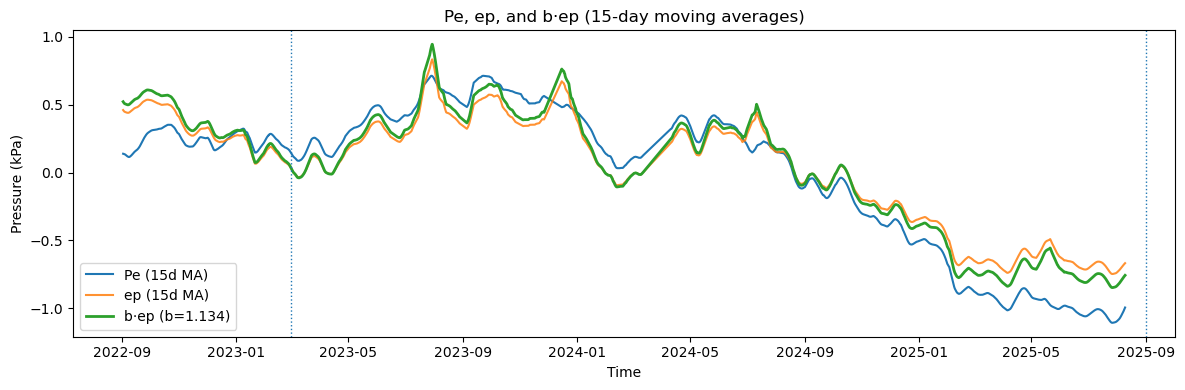

corr(ep, b·ep) = 0.9999999999999998


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- windows ----
show0 = pd.Timestamp('2022-09-01')
t0    = pd.Timestamp('2023-03-01')
t1    = pd.Timestamp('2025-09-01')

# ---- prep ----
df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass
df = df.dropna(subset=["time","Pe","ep"]).sort_values("time")

# show window + 15d MA
x  = df[(df["time"] >= show0) & (df["time"] < t1)].set_index("time").sort_index()
ma = x[["Pe","ep"]].rolling("15D").mean().dropna()

# fit window to estimate b in: Pe = a + b*ep + c*t'
fit = ma[(ma.index >= t0) & (ma.index < t1)].copy()
if fit.empty:
    raise ValueError("Pe/ep fit window has no data after MA.")
t_mid  = fit.index[0] + (fit.index[-1] - fit.index[0]) / 2
tprime = (fit.index - t_mid).total_seconds() / (365.25*86400.0)

X = np.column_stack([np.ones(len(fit)), fit["ep"].to_numpy(float), tprime.to_numpy(float)])
y = fit["Pe"].to_numpy(float)
a, b, c = np.linalg.lstsq(X, y, rcond=None)[0]

# b*ep over the full MA series (same indexing!)
ma["b_times_ep"] = b * ma["ep"].to_numpy(float)

# ---- one plot ----
plt.figure(figsize=(12,4))
plt.plot(ma.index, ma["Pe"], label="Pe (15d MA)")
plt.plot(ma.index, ma["ep"], label="ep (15d MA)", alpha=0.85)
plt.plot(ma.index, ma["b_times_ep"], label=f"b·ep (b={b:.3f})", linewidth=2)
plt.axvline(t0, ls=":", lw=1); plt.axvline(t1, ls=":", lw=1)
plt.ylabel("Pressure (kPa)"); plt.xlabel("Time")
plt.title("Pe, ep, and b·ep (15-day moving averages)")
plt.legend(); plt.tight_layout(); plt.show()

# (optional sanity check: must be ~1.0)
print("corr(ep, b·ep) =", np.corrcoef(ma["ep"].values, ma["b_times_ep"].values)[0,1])



Pe RAW (no drift) FIT over 2023-03-01 to 2025-09-01
a (kPa)     = -0.0287
b (kPa/kPa) = 1.3704   # coupling to ep (RAW)
RMSE (kPa)  = 0.1010
N (15d-MA)  = 4591


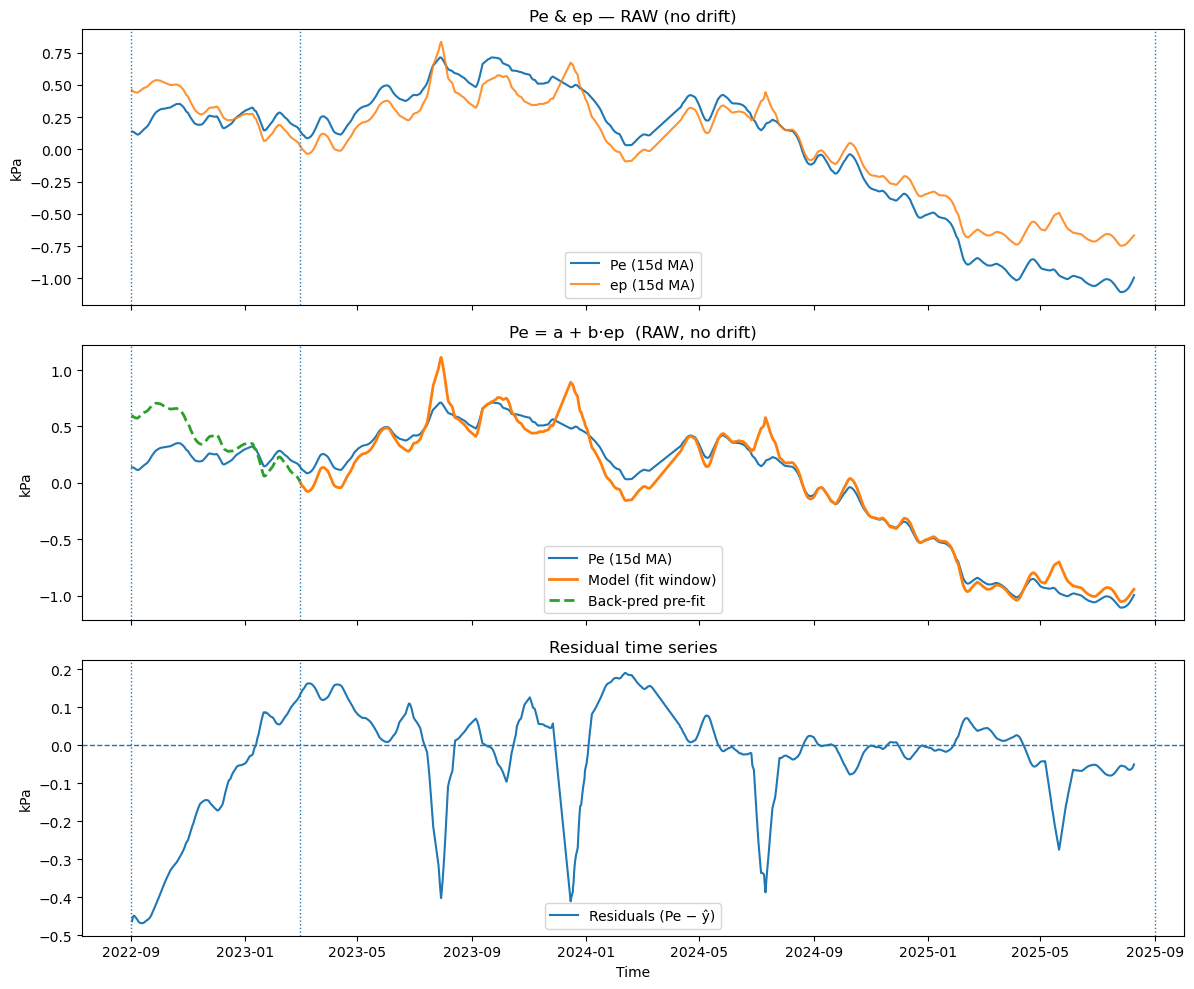

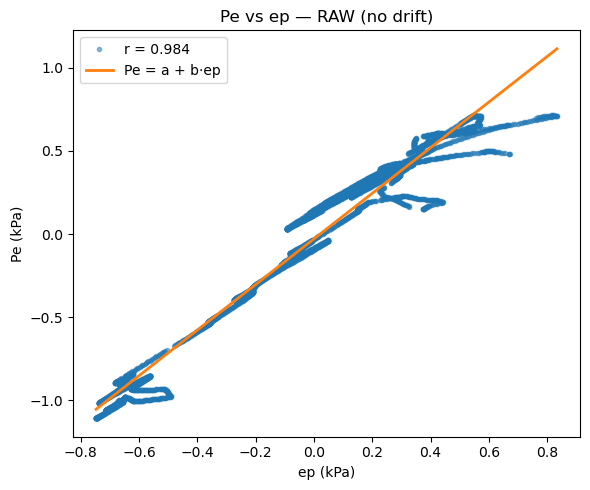

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) windows + prep -----------
show0 = pd.Timestamp('2022-09-01')
t0    = pd.Timestamp('2023-03-01')
t1    = pd.Timestamp('2025-09-01')

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

df = df.dropna(subset=["time", "Pe", "ep"]).sort_values("time")

df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("Show window (2022-09..2025-09) has no data.")

tmp_show = df_show.set_index("time").sort_index()
ma_full = tmp_show[["Pe", "ep"]].rolling("15D").mean().dropna().copy()
ma_full["time"] = ma_full.index

ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("Fit window (2023-03..2025-09) has no data after MA.")

# ----------- 1) RAW (no drift): Pe = a + b*ep -----------
y = ma_fit["Pe"].to_numpy(float)
X = np.column_stack([np.ones(len(ma_fit)), ma_fit["ep"].to_numpy(float)])
coef, *_ = np.linalg.lstsq(X, y, rcond=None)
a_e, b_e = coef

ma_fit["Pe_hat"] = X @ coef
ma_fit["resid"]  = y - ma_fit["Pe_hat"]

print(f"\nPe RAW (no drift) FIT over {t0.date()} to {t1.date()}")
print(f"a (kPa)     = {a_e:.4f}")
print(f"b (kPa/kPa) = {b_e:.4f}   # coupling to ep (RAW)")
print(f"RMSE (kPa)  = {np.sqrt(np.mean(ma_fit['resid']**2)):.4f}")
print(f"N (15d-MA)  = {len(ma_fit)}")

# ----------- 2) Apply across FULL window -----------
ma_full["Pe_hat"] = a_e + b_e * ma_full["ep"].to_numpy(float)
ma_full["resid"]  = ma_full["Pe"] - ma_full["Pe_hat"]

pre_mask = ma_full.index < t0
fit_mask = (ma_full.index >= t0) & (ma_full.index < t1)

# ----------- 3) Plots -----------
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(ma_full["time"], ma_full["Pe"], label="Pe (15d MA)")
axes[0].plot(ma_full["time"], ma_full["ep"], label="ep (15d MA)", alpha=0.85)
axes[0].set_ylabel("kPa"); axes[0].legend(); axes[0].set_title("Pe & ep — RAW (no drift)")

axes[1].plot(ma_full["time"], ma_full["Pe"], label="Pe (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "Pe_hat"], label="Model (fit window)", lw=2)
axes[1].plot(ma_full.loc[pre_mask, "time"], ma_full.loc[pre_mask, "Pe_hat"], ls="--", lw=2, label="Back-pred pre-fit")
axes[1].set_ylabel("kPa"); axes[1].legend()
axes[1].set_title("Pe = a + b·ep  (RAW, no drift)")

axes[2].plot(ma_full["time"], ma_full["resid"], label="Residuals (Pe − ŷ)")
axes[2].axhline(0, ls="--", lw=1); axes[2].legend(); axes[2].set_ylabel("kPa"); axes[2].set_xlabel("Time")
axes[2].set_title("Residual time series")

for ax in axes:
    ax.axvline(show0, ls=":", lw=1); ax.axvline(t0, ls=":", lw=1); ax.axvline(t1, ls=":", lw=1)

plt.tight_layout(); plt.show()

# ----------- 4) Cross-plot (fit window) -----------
r = np.corrcoef(ma_fit["ep"], ma_fit["Pe"])[0, 1]
plt.figure(figsize=(6,5))
plt.plot(ma_fit["ep"], ma_fit["Pe"], ".", alpha=0.5, label=f"r = {r:.3f}")
xg = np.linspace(ma_fit["ep"].min(), ma_fit["ep"].max(), 200)
yg = a_e + b_e * xg
plt.plot(xg, yg, lw=2, label="Pe = a + b·ep")
plt.xlabel("ep (kPa)"); plt.ylabel("Pe (kPa)")
plt.title("Pe vs ep — RAW (no drift)")
plt.legend(); plt.tight_layout(); plt.show()



ep ~ a + b·Pc + c·t'   (t' centered in FIT: 2022-09..2025-09)
a (kPa)     = -0.0166
b (kPa/kPa) = 0.5011   # coupling to Pc (central)
c (kPa/yr)  = 0.2125   # linear drift rate in ep
RMSE (kPa)  = 0.0967
N (15d-MA)  = 5600


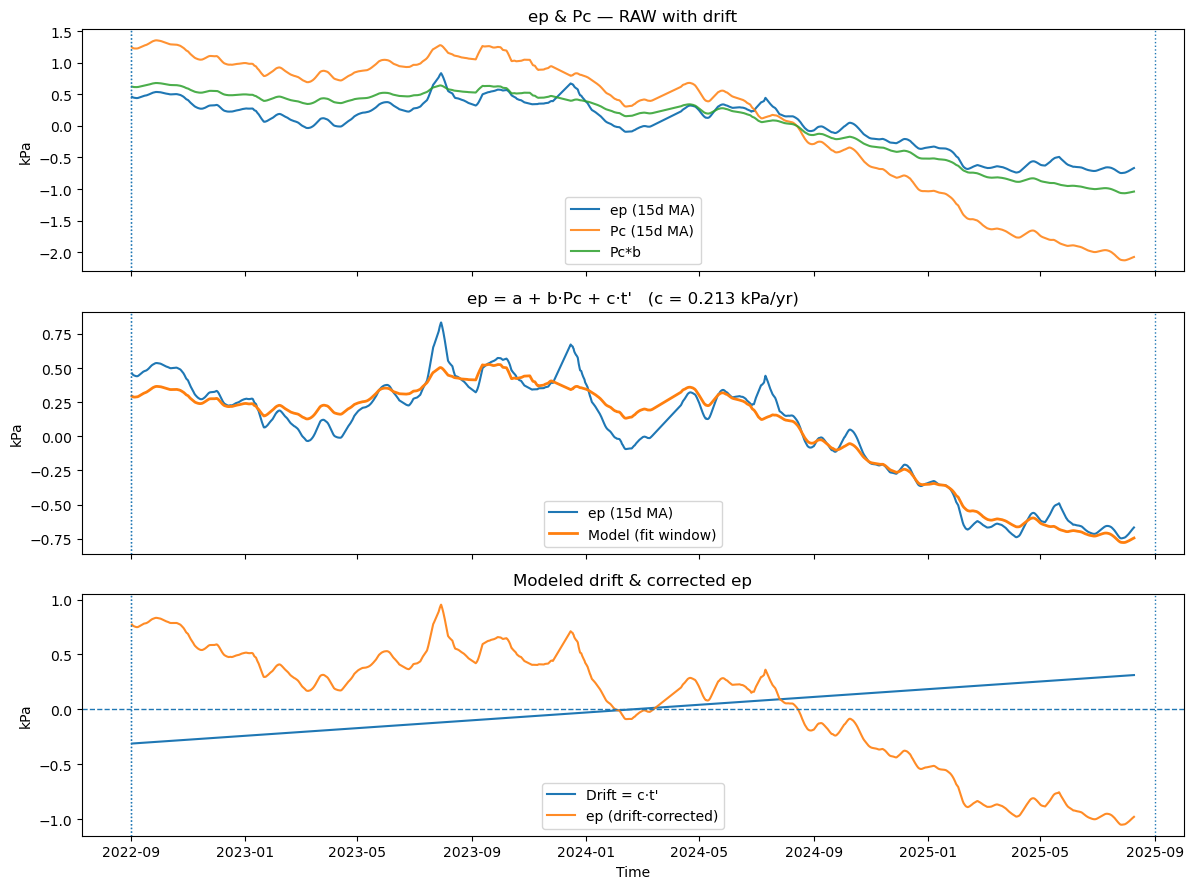

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- windows ----------
show0 = pd.Timestamp('2022-09-01')   # display starts (adds prior year)
t0    = pd.Timestamp('2022-09-01')   # FIT start
t1    = pd.Timestamp('2025-09-01')   # FIT end (exclusive)
to_years = 365.25 * 86400.0

# ---------- prep ----------
df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

# need Pc (central) and ep (east)
df = df.dropna(subset=["time", "Pc", "ep"]).sort_values("time")

# show window
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No Pc/ep data in 2022-09..2025-09 window.")

# 15-day moving average (optional smoothing)
ma_full = (df_show.set_index("time")[["Pc", "ep"]]
           .rolling("15D").mean()
           .dropna()
           .copy())
ma_full["time"] = ma_full.index

# ---------- FIT (2022-09..2025-09) ----------
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("FIT window (2022-09..2025-09) empty after 15d MA.")

# centered time regressor (Pc stays RAW)
t_mid_fit = ma_fit.index[0] + (ma_fit.index[-1] - ma_fit.index[0]) / 2
ma_fit["tprime_years"] = (ma_fit.index - t_mid_fit).total_seconds() / to_years

# ep = a + b*Pc + c*t'
y = ma_fit["ep"].to_numpy(float)
X = np.column_stack([
    np.ones(len(ma_fit)),                 # a
    ma_fit["Pc"].to_numpy(float),         # b * Pc (RAW)
    ma_fit["tprime_years"].to_numpy(float) # c * t'
])
(a, b, c), *_ = np.linalg.lstsq(X, y, rcond=None)

# Diagnostics (FIT window)
ma_fit["ep_hat"] = X @ np.array([a, b, c])
ma_fit["resid"]  = y - ma_fit["ep_hat"]
rmse = float(np.sqrt(np.mean(ma_fit["resid"]**2)))

print("\nep ~ a + b·Pc + c·t'   (t' centered in FIT: 2022-09..2025-09)")
print(f"a (kPa)     = {a:.4f}")
print(f"b (kPa/kPa) = {b:.4f}   # coupling to Pc (central)")
print(f"c (kPa/yr)  = {c:.4f}   # linear drift rate in ep")
print(f"RMSE (kPa)  = {rmse:.4f}")
print(f"N (15d-MA)  = {len(ma_fit)}")

# ---------- Apply across FULL show window ----------
ma_full["tprime_years"] = (ma_full.index - t_mid_fit).total_seconds() / to_years
ma_full["ep_hat"] = a + b*ma_full["Pc"].to_numpy(float) + c*ma_full["tprime_years"].to_numpy(float)
ma_full["drift_component"] = c * ma_full["tprime_years"]
ma_full["ep_driftcorr"] = ma_full["ep"] - ma_full["drift_component"]

# ---------- Plots ----------
fit_mask = (ma_full.index >= t0) & (ma_full.index < t1)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(ma_full["time"], ma_full["ep"], label="ep (15d MA)")
axes[0].plot(ma_full["time"], ma_full["Pc"], label="Pc (15d MA)", alpha=0.85)
axes[0].plot(ma_full["time"], ma_full["Pc"]*b, label="Pc*b", alpha=0.85)
axes[0].set_ylabel("kPa"); axes[0].legend(); axes[0].set_title("ep & Pc — RAW with drift")

axes[1].plot(ma_full["time"], ma_full["ep"], label="ep (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "ep_hat"], lw=2, label="Model (fit window)")
axes[1].set_ylabel("kPa"); axes[1].legend()
axes[1].set_title(f"ep = a + b·Pc + c·t'   (c = {c:.3f} kPa/yr)")

axes[2].plot(ma_full["time"], ma_full["drift_component"], label="Drift = c·t'")
axes[2].plot(ma_full["time"], ma_full["ep_driftcorr"], label="ep (drift-corrected)", alpha=0.9)
axes[2].axhline(0, ls="--", lw=1); axes[2].set_ylabel("kPa"); axes[2].set_xlabel("Time")
axes[2].legend(); axes[2].set_title("Modeled drift & corrected ep")

for ax in axes:
    ax.axvline(show0, ls=":", lw=1); ax.axvline(t0, ls=":", lw=1); ax.axvline(t1, ls=":", lw=1)

plt.tight_layout(); plt.show()

# Params for reuse
ep_model_with_drift = {"a": a, "b": b, "c": c, "t_mid_fit": t_mid_fit}


In [33]:
# ----------- 6) start→finish depth metrics for ep/Pc (cm) -----------
CM_PER_KPA = 9.94  # cm per kPa ( +kPa => deeper )

def window_means(s, n=30):
    s = s.dropna()
    n = min(n, len(s)//2) if len(s) >= 2 else 0
    if n == 0:
        return np.nan, np.nan, None, None
    first = s.iloc[:n].mean()
    last  = s.iloc[-n:].mean()
    return first, last, s.index[0], s.index[-1]

def to_depth_cm(p_kpa):
    return p_kpa * CM_PER_KPA

# Series (kPa)
ep_kPa     = ma_full["ep"]
Pc_kPa     = ma_full["Pc"]
drift_kPa  = ma_full["drift_component"]   # c * t'
ep_dc_kPa  = ma_full["ep_driftcorr"]      # already ep - drift

# (1) BEFORE drift correction: raw ep
f1, l1, t_first, t_last = window_means(ep_kPa, n=30)
d_before_cm = (l1 - f1) * CM_PER_KPA

# (2) AFTER drift correction: drift-corrected ep
f2, l2, _, _ = window_means(ep_dc_kPa, n=30)
d_after_cm = (l2 - f2) * CM_PER_KPA

# (3) Reference (assumed drift-free) used for fitting: Pc
f3, l3, _, _ = window_means(Pc_kPa, n=30)
d_ref_cm = (l3 - f3) * CM_PER_KPA

print("\nDepth change (first 30 vs last 30 of 15-day MAs) — ep/Pc")
print(f"Window start: {t_first:%Y-%m-%d}, window end: {t_last:%Y-%m-%d}")
print(f"  • BEFORE drift correction (ep raw):           {d_before_cm:+.2f} cm  ( + = deeper )")
print(f"  • AFTER  drift correction (ep − c·t′):        {d_after_cm:+.2f} cm")
print(f"  • Reference (no-drift) station (Pc) change:   {d_ref_cm:+.2f} cm")

# ----------- 6b) also print start/end depths (cm) -----------
rows = []
def add_row(label, p_first, p_last):
    d_first = to_depth_cm(p_first) if np.isfinite(p_first) else np.nan
    d_last  = to_depth_cm(p_last)  if np.isfinite(p_last)  else np.nan
    rows.append({
        "metric": label,
        "start_depth_cm": d_first,
        "end_depth_cm": d_last,
        "delta_depth_cm": d_last - d_first
    })

add_row("ep BEFORE drift", f1, l1)
add_row("ep AFTER drift",  f2, l2)
add_row("Reference Pc",    f3, l3)

depth_summary_ep = pd.DataFrame(rows)

print("\nStart/End Depths (first/last 30-point MAs; + = deeper):")
for _, r in depth_summary_ep.iterrows():
    print(f"  • {r['metric']:<16}  start = {r['start_depth_cm']:+.2f} cm, "
          f"end = {r['end_depth_cm']:+.2f} cm,  Δ = {r['delta_depth_cm']:+.2f} cm")

# Optional: keep the summary df for logging/saving
# depth_summary_ep



Depth change (first 30 vs last 30 of 15-day MAs) — ep/Pc
Window start: 2022-09-02, window end: 2025-08-09
  • BEFORE drift correction (ep raw):           -11.27 cm  ( + = deeper )
  • AFTER  drift correction (ep − c·t′):        -17.44 cm
  • Reference (no-drift) station (Pc) change:   -32.97 cm

Start/End Depths (first/last 30-point MAs; + = deeper):
  • ep BEFORE drift   start = +4.44 cm, end = -6.83 cm,  Δ = -11.27 cm
  • ep AFTER drift    start = +7.52 cm, end = -9.92 cm,  Δ = -17.44 cm
  • Reference Pc      start = +12.20 cm, end = -20.77 cm,  Δ = -32.97 cm


In [34]:
# Create DataFrame with time and drift-corrected pressure
output_df = pd.DataFrame({
    'time': ep_dc_kPa.index,
    'pressure_drift_corrected_kPa': ep_dc_kPa.values
})

# Save to CSV
output_file = 'ep_drifcor.csv'
output_df.to_csv(output_file, index=False)
print(f"\nSaved {len(output_df)} records to {output_file}")
print(f"Columns: {list(output_df.columns)}")
print(f"\nFirst few rows:")
print(output_df.head())


Saved 5600 records to ep_drifcor.csv
Columns: ['time', 'pressure_drift_corrected_kPa']

First few rows:
                 time  pressure_drift_corrected_kPa
0 2022-09-02 11:45:00                      0.771865
1 2022-09-02 15:45:00                      0.769723
2 2022-09-02 19:45:00                      0.767898
3 2022-09-02 23:45:00                      0.766867
4 2022-09-03 03:45:00                      0.765162



ep ~ a + b·Pc   (RAW; no drift; FIT: 2022-09..2025-09)
a (kPa)     = -0.0040
b (kPa/kPa) = 0.3454   # coupling to Pc (central)
RMSE (kPa)  = 0.1216
N (15d-MA)  = 5600


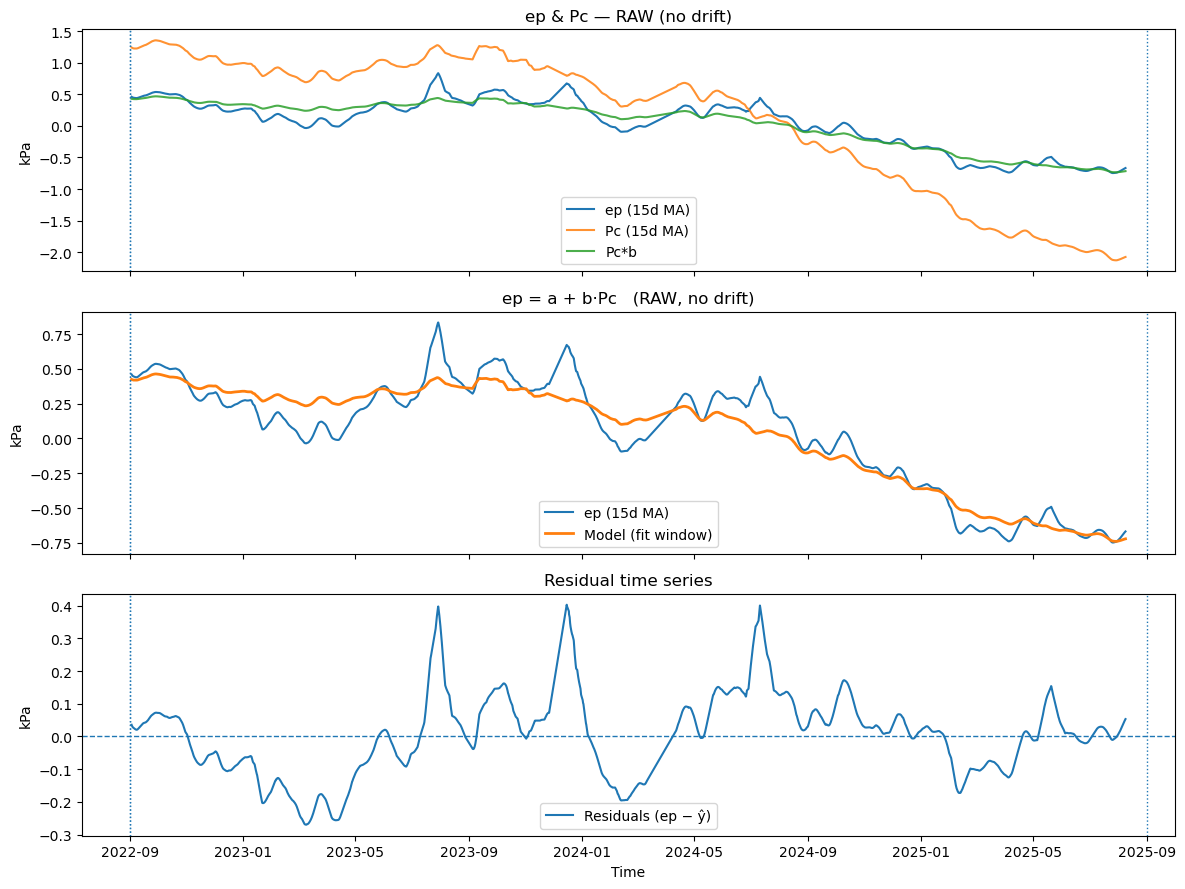

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- windows ----------
show0 = pd.Timestamp('2022-09-01')
t0    = pd.Timestamp('2022-09-01')
t1    = pd.Timestamp('2025-09-01')

# ---------- prep ----------
df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

df = df.dropna(subset=["time", "Pc", "ep"]).sort_values("time")

df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No Pc/ep data in 2022-09..2025-09 window.")

ma_full = (df_show.set_index("time")[["Pc", "ep"]]
           .rolling("15D").mean()
           .dropna()
           .copy())
ma_full["time"] = ma_full.index

# ---------- FIT (2022-09..2025-09) ----------
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("FIT window (2022-09..2025-09) empty after 15d MA.")

# ep = a + b*Pc
y = ma_fit["ep"].to_numpy(float)
X = np.column_stack([np.ones(len(ma_fit)), ma_fit["Pc"].to_numpy(float)])
(a, b), *_ = np.linalg.lstsq(X, y, rcond=None)

# Diagnostics (FIT window)
ma_fit["ep_hat"] = X @ np.array([a, b])
ma_fit["resid"]  = y - ma_fit["ep_hat"]
rmse = float(np.sqrt(np.mean(ma_fit["resid"]**2)))

print("\nep ~ a + b·Pc   (RAW; no drift; FIT: 2022-09..2025-09)")
print(f"a (kPa)     = {a:.4f}")
print(f"b (kPa/kPa) = {b:.4f}   # coupling to Pc (central)")
print(f"RMSE (kPa)  = {rmse:.4f}")
print(f"N (15d-MA)  = {len(ma_fit)}")

# ---------- Apply across FULL show window ----------
ma_full["ep_hat"] = a + b*ma_full["Pc"].to_numpy(float)
ma_full["resid"]  = ma_full["ep"] - ma_full["ep_hat"]

# ---------- Plots ----------
fit_mask = (ma_full.index >= t0) & (ma_full.index < t1)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(ma_full["time"], ma_full["ep"], label="ep (15d MA)")
axes[0].plot(ma_full["time"], ma_full["Pc"], label="Pc (15d MA)", alpha=0.85)
axes[0].plot(ma_full["time"], ma_full["Pc"]*b, label="Pc*b", alpha=0.85)
axes[0].set_ylabel("kPa"); axes[0].legend(); axes[0].set_title("ep & Pc — RAW (no drift)")

axes[1].plot(ma_full["time"], ma_full["ep"], label="ep (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "ep_hat"], lw=2, label="Model (fit window)")
axes[1].set_ylabel("kPa"); axes[1].legend()
axes[1].set_title("ep = a + b·Pc   (RAW, no drift)")

axes[2].plot(ma_full["time"], ma_full["resid"], label="Residuals (ep − ŷ)")
axes[2].axhline(0, ls="--", lw=1); axes[2].set_ylabel("kPa"); axes[2].set_xlabel("Time")
axes[2].legend(); axes[2].set_title("Residual time series")

for ax in axes:
    ax.axvline(show0, ls=":", lw=1); ax.axvline(t0, ls=":", lw=1); ax.axvline(t1, ls=":", lw=1)

plt.tight_layout(); plt.show()

# Params for reuse
ep_model_no_drift = {"a": a, "b": b}



wp ~ a + b·Pc + c·t'   (RAW Pc; t' centered in FIT: 2022-09..2025-09)
a (kPa)     = 0.0032
b (kPa/kPa) = 0.6437   # coupling to Pc
c (kPa/yr)  = 0.0662   # linear drift rate
RMSE (kPa)  = 0.0530
N (15d-MA)  = 5600


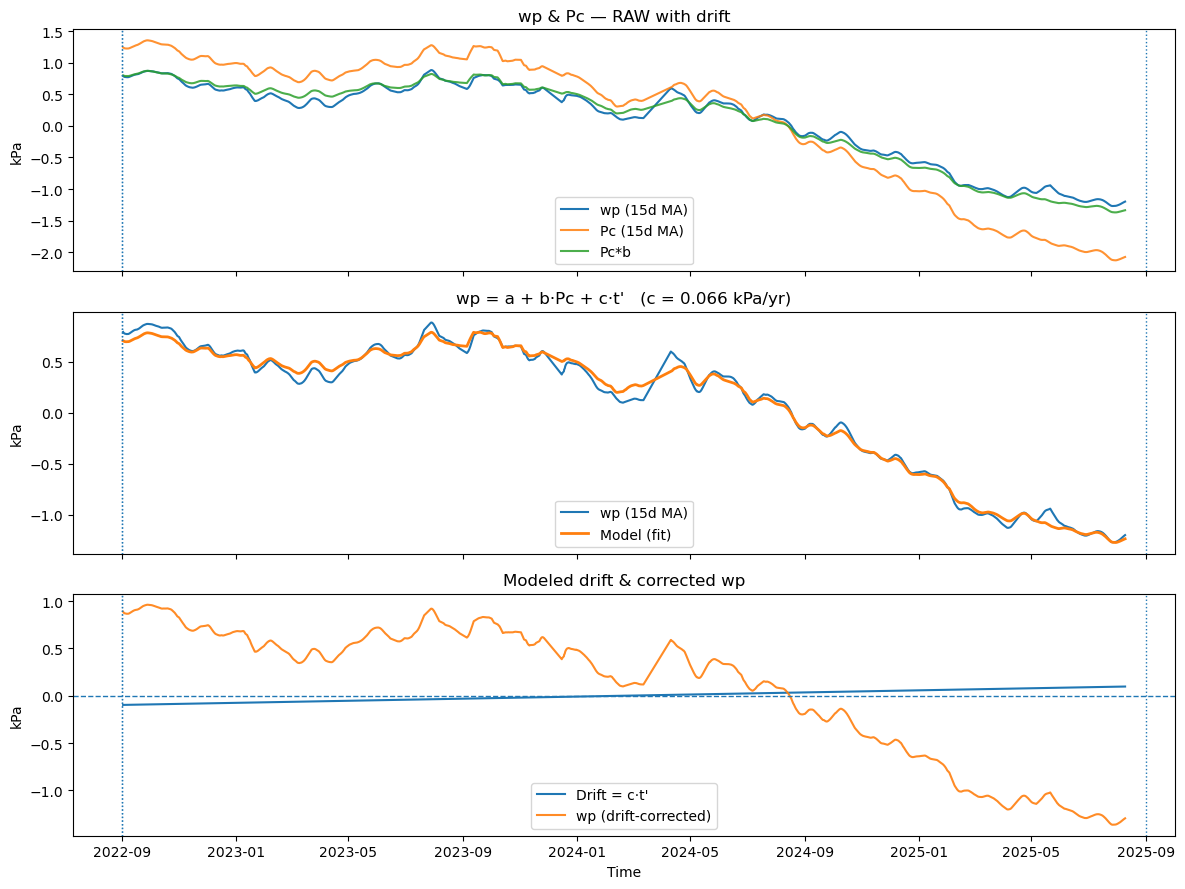

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------- windows -------
show0 = pd.Timestamp('2022-09-01')
t0    = pd.Timestamp('2022-09-01')
t1    = pd.Timestamp('2025-09-01')
to_years = 365.25 * 86400.0

# ------- prep -------
df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

df = df.dropna(subset=["time", "Pc", "wp"]).sort_values("time")

df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No Pc/wp data in 2022-09..2025-09 window.")

ma_full = (df_show.set_index("time")[["Pc", "wp"]]
           .rolling("15D").mean()
           .dropna()
           .copy())
ma_full["time"] = ma_full.index

# ------- FIT (2022-09..2025-09) -------
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("FIT window (2022-09..2025-09) empty after 15d MA.")

# RAW Pc, centered time only (for stability)
t_mid_fit = ma_fit.index[0] + (ma_fit.index[-1] - ma_fit.index[0]) / 2
ma_fit["tprime_years"] = (ma_fit.index - t_mid_fit).total_seconds() / to_years

# wp = a + b*Pc + c*t'
y = ma_fit["wp"].to_numpy(float)
X = np.column_stack([
    np.ones(len(ma_fit)),
    ma_fit["Pc"].to_numpy(float),
    ma_fit["tprime_years"].to_numpy(float)
])
(a, b, c), *_ = np.linalg.lstsq(X, y, rcond=None)

# Diagnostics
ma_fit["wp_hat"] = X @ np.array([a, b, c])
ma_fit["resid"]  = y - ma_fit["wp_hat"]
rmse = float(np.sqrt(np.mean(ma_fit["resid"]**2)))

print("\nwp ~ a + b·Pc + c·t'   (RAW Pc; t' centered in FIT: 2022-09..2025-09)")
print(f"a (kPa)     = {a:.4f}")
print(f"b (kPa/kPa) = {b:.4f}   # coupling to Pc")
print(f"c (kPa/yr)  = {c:.4f}   # linear drift rate")
print(f"RMSE (kPa)  = {rmse:.4f}")
print(f"N (15d-MA)  = {len(ma_fit)}")

# ------- Apply across FULL show window -------
ma_full["tprime_years"] = (ma_full.index - t_mid_fit).total_seconds() / to_years
ma_full["wp_hat"] = a + b*ma_full["Pc"].to_numpy(float) + c*ma_full["tprime_years"].to_numpy(float)
ma_full["drift_component"] = c * ma_full["tprime_years"]
ma_full["wp_driftcorr"] = ma_full["wp"] - ma_full["drift_component"]

# ------- Plots -------
fit_mask = (ma_full.index >= t0) & (ma_full.index < t1)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(ma_full["time"], ma_full["wp"], label="wp (15d MA)")
axes[0].plot(ma_full["time"], ma_full["Pc"], label="Pc (15d MA)", alpha=0.85)
axes[0].plot(ma_full["time"], ma_full["Pc"]*b, label="Pc*b", alpha=0.85)
axes[0].set_ylabel("kPa"); axes[0].legend(); axes[0].set_title("wp & Pc — RAW with drift")

axes[1].plot(ma_full["time"], ma_full["wp"], label="wp (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "wp_hat"], lw=2, label="Model (fit)")
axes[1].set_ylabel("kPa"); axes[1].legend()
axes[1].set_title(f"wp = a + b·Pc + c·t'   (c = {c:.3f} kPa/yr)")

axes[2].plot(ma_full["time"], ma_full["drift_component"], label="Drift = c·t'")
axes[2].plot(ma_full["time"], ma_full["wp_driftcorr"], label="wp (drift-corrected)", alpha=0.9)
axes[2].axhline(0, ls="--", lw=1); axes[2].set_ylabel("kPa"); axes[2].set_xlabel("Time")
axes[2].legend(); axes[2].set_title("Modeled drift & corrected wp")

for ax in axes:
    ax.axvline(show0, ls=":", lw=1); ax.axvline(t0, ls=":", lw=1); ax.axvline(t1, ls=":", lw=1)

plt.tight_layout(); plt.show()

# Params for reuse
wp_model_with_drift = {"a": a, "b": b, "c": c, "t_mid_fit": t_mid_fit}


In [40]:
# ----------- 6) start→finish depth metrics for wp/Pc (cm) -----------
CM_PER_KPA = 9.94  # cm per kPa ( +kPa => deeper )

def window_means(s, n=30):
    s = s.dropna()
    n = min(n, len(s)//2) if len(s) >= 2 else 0
    if n == 0:
        return np.nan, np.nan, None, None
    first = s.iloc[:n].mean()
    last  = s.iloc[-n:].mean()
    return first, last, s.index[0], s.index[-1]

def to_depth_cm(p_kpa):
    return p_kpa * CM_PER_KPA

# Series (kPa)
wp_kPa     = ma_full["wp"]
Pc_kPa     = ma_full["Pc"]
drift_kPa  = ma_full["drift_component"]     # c * t'
wp_dc_kPa  = ma_full["wp_driftcorr"]         # already wp - drift

# (1) BEFORE drift correction: raw wp
f1, l1, t_first, t_last = window_means(wp_kPa, n=30)
d_before_cm = (l1 - f1) * CM_PER_KPA

# (2) AFTER drift correction: drift-corrected wp
f2, l2, _, _ = window_means(wp_dc_kPa, n=30)
d_after_cm = (l2 - f2) * CM_PER_KPA

# (3) Reference (assumed drift-free) used for fitting: Pc
f3, l3, _, _ = window_means(Pc_kPa, n=30)
d_ref_cm = (l3 - f3) * CM_PER_KPA

print("\nDepth change (first 30 vs last 30 of 15-day MAs) — wp/Pc")
print(f"Window start: {t_first:%Y-%m-%d}, window end: {t_last:%Y-%m-%d}")
print(f"  • BEFORE drift correction (wp raw):           {d_before_cm:+.2f} cm  ( + = deeper )")
print(f"  • AFTER  drift correction (wp − c·t′):        {d_after_cm:+.2f} cm")
print(f"  • Reference (no-drift) station (Pc) change:   {d_ref_cm:+.2f} cm")

# ----------- 6b) also print start/end depths (cm) -----------
rows = []
def add_row(label, p_first, p_last):
    d_first = to_depth_cm(p_first) if np.isfinite(p_first) else np.nan
    d_last  = to_depth_cm(p_last)  if np.isfinite(p_last)  else np.nan
    rows.append({
        "metric": label,
        "start_depth_cm": d_first,
        "end_depth_cm": d_last,
        "delta_depth_cm": d_last - d_first
    })

add_row("wp BEFORE drift", f1, l1)
add_row("wp AFTER drift",  f2, l2)
add_row("Reference Pc",    f3, l3)

depth_summary_wp = pd.DataFrame(rows)

print("\nStart/End Depths (first/last 30-point MAs; + = deeper):")
for _, r in depth_summary_wp.iterrows():
    print(f"  • {r['metric']:<16}  start = {r['start_depth_cm']:+.2f} cm, "
          f"end = {r['end_depth_cm']:+.2f} cm,  Δ = {r['delta_depth_cm']:+.2f} cm")

# Optional: keep the summary df around
# depth_summary_wp



Depth change (first 30 vs last 30 of 15-day MAs) — wp/Pc
Window start: 2022-09-02, window end: 2025-08-09
  • BEFORE drift correction (wp raw):           -19.80 cm  ( + = deeper )
  • AFTER  drift correction (wp − c·t′):        -21.72 cm
  • Reference (no-drift) station (Pc) change:   -32.97 cm

Start/End Depths (first/last 30-point MAs; + = deeper):
  • wp BEFORE drift   start = +7.70 cm, end = -12.10 cm,  Δ = -19.80 cm
  • wp AFTER drift    start = +8.66 cm, end = -13.06 cm,  Δ = -21.72 cm
  • Reference Pc      start = +12.20 cm, end = -20.77 cm,  Δ = -32.97 cm


In [41]:
# Create DataFrame with time and drift-corrected pressure
output_df = pd.DataFrame({
    'time': wp_dc_kPa.index,
    'pressure_drift_corrected_kPa': wp_dc_kPa.values
})

# Save to CSV
output_file = 'wp_drifcor.csv'
output_df.to_csv(output_file, index=False)
print(f"\nSaved {len(output_df)} records to {output_file}")
print(f"Columns: {list(output_df.columns)}")
print(f"\nFirst few rows:")
print(output_df.head())


Saved 5600 records to wp_drifcor.csv
Columns: ['time', 'pressure_drift_corrected_kPa']

First few rows:
                 time  pressure_drift_corrected_kPa
0 2022-09-02 11:45:00                      0.887895
1 2022-09-02 15:45:00                      0.884424
2 2022-09-02 19:45:00                      0.880941
3 2022-09-02 23:45:00                      0.879081
4 2022-09-03 03:45:00                      0.877776



wp ~ a + b·Pc   (RAW; no drift; FIT: 2022-09..2025-09)
a (kPa)     = 0.0071
b (kPa/kPa) = 0.5952   # coupling to Pc
RMSE (kPa)  = 0.0578
N (15d-MA)  = 5600


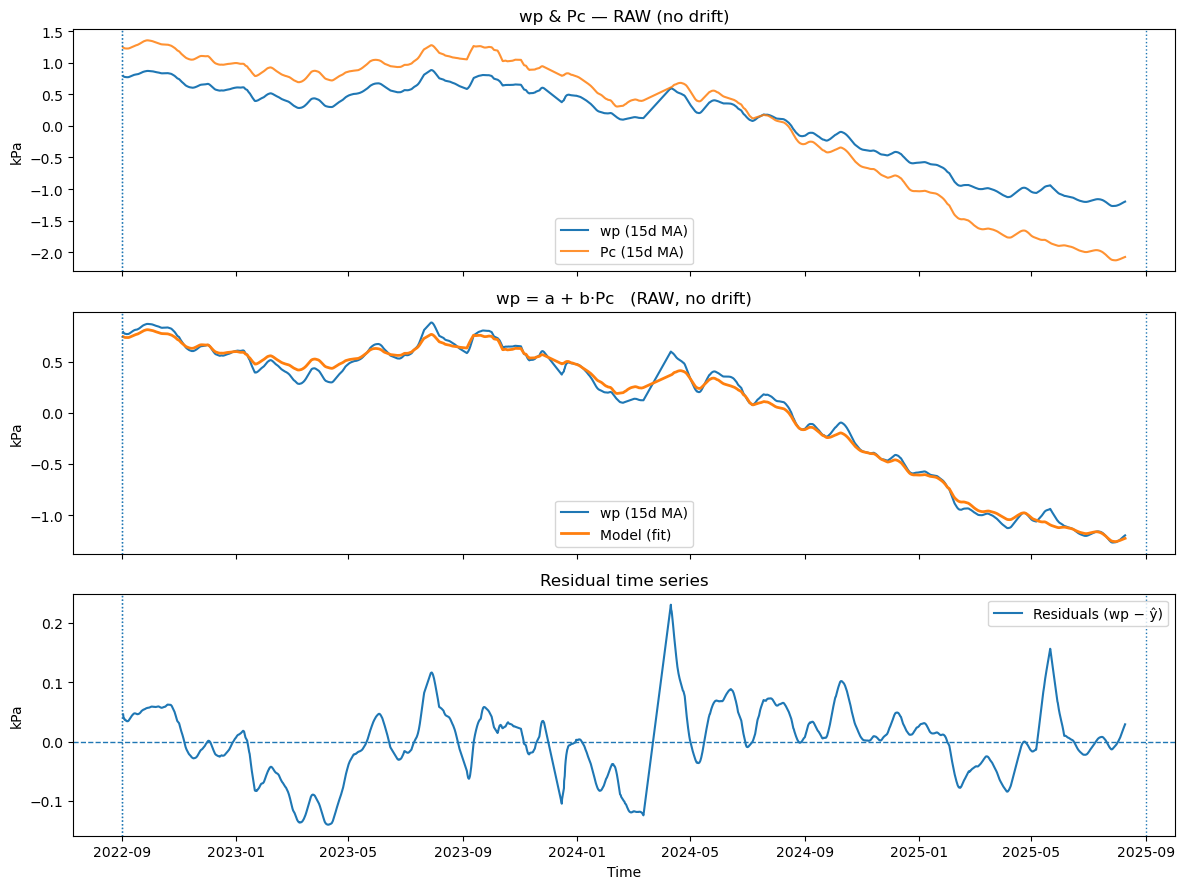

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------- windows -------
show0 = pd.Timestamp('2022-09-01')
t0    = pd.Timestamp('2022-09-01')
t1    = pd.Timestamp('2025-09-01')

# ------- prep -------
df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

df = df.dropna(subset=["time", "Pc", "wp"]).sort_values("time")

df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No Pc/wp data in 2022-09..2025-09 window.")

ma_full = (df_show.set_index("time")[["Pc", "wp"]]
           .rolling("15D").mean()
           .dropna()
           .copy())
ma_full["time"] = ma_full.index

# ------- FIT (2022-09..2025-09) -------
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("FIT window (2022-09..2025-09) empty after 15d MA.")

# wp = a + b*Pc  (RAW; no time term)
y = ma_fit["wp"].to_numpy(float)
X = np.column_stack([np.ones(len(ma_fit)), ma_fit["Pc"].to_numpy(float)])
(a, b), *_ = np.linalg.lstsq(X, y, rcond=None)

# Diagnostics
ma_fit["wp_hat"] = X @ np.array([a, b])
ma_fit["resid"]  = y - ma_fit["wp_hat"]
rmse = float(np.sqrt(np.mean(ma_fit["resid"]**2)))

print("\nwp ~ a + b·Pc   (RAW; no drift; FIT: 2022-09..2025-09)")
print(f"a (kPa)     = {a:.4f}")
print(f"b (kPa/kPa) = {b:.4f}   # coupling to Pc")
print(f"RMSE (kPa)  = {rmse:.4f}")
print(f"N (15d-MA)  = {len(ma_fit)}")

# ------- Apply across FULL show window -------
ma_full["wp_hat"] = a + b*ma_full["Pc"].to_numpy(float)
ma_full["resid"]  = ma_full["wp"] - ma_full["wp_hat"]

# ------- Plots -------
fit_mask = (ma_full.index >= t0) & (ma_full.index < t1)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(ma_full["time"], ma_full["wp"], label="wp (15d MA)")
axes[0].plot(ma_full["time"], ma_full["Pc"], label="Pc (15d MA)", alpha=0.85)
axes[0].set_ylabel("kPa"); axes[0].legend(); axes[0].set_title("wp & Pc — RAW (no drift)")

axes[1].plot(ma_full["time"], ma_full["wp"], label="wp (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "wp_hat"], lw=2, label="Model (fit)")
axes[1].set_ylabel("kPa"); axes[1].legend()
axes[1].set_title("wp = a + b·Pc   (RAW, no drift)")

axes[2].plot(ma_full["time"], ma_full["resid"], label="Residuals (wp − ŷ)")
axes[2].axhline(0, ls="--", lw=1); axes[2].set_ylabel("kPa"); axes[2].set_xlabel("Time")
axes[2].legend(); axes[2].set_title("Residual time series")

for ax in axes:
    ax.axvline(show0, ls=":", lw=1); ax.axvline(t0, ls=":", lw=1); ax.axvline(t1, ls=":", lw=1)

plt.tight_layout(); plt.show()

# Params for reuse
wp_model_no_drift = {"a": a, "b": b}



Pw ~ a + b·wp + c·t'   (wp raw; t' centered in FIT: 2023-03..2025-09)
a (kPa)     = 0.0414
b (kPa/kPa) = 0.9680   # coupling to wp
c (kPa/yr)  = 0.3341   # Pw linear drift rate
RMSE (kPa)  = 0.0379
N (15d-MA)  = 4591


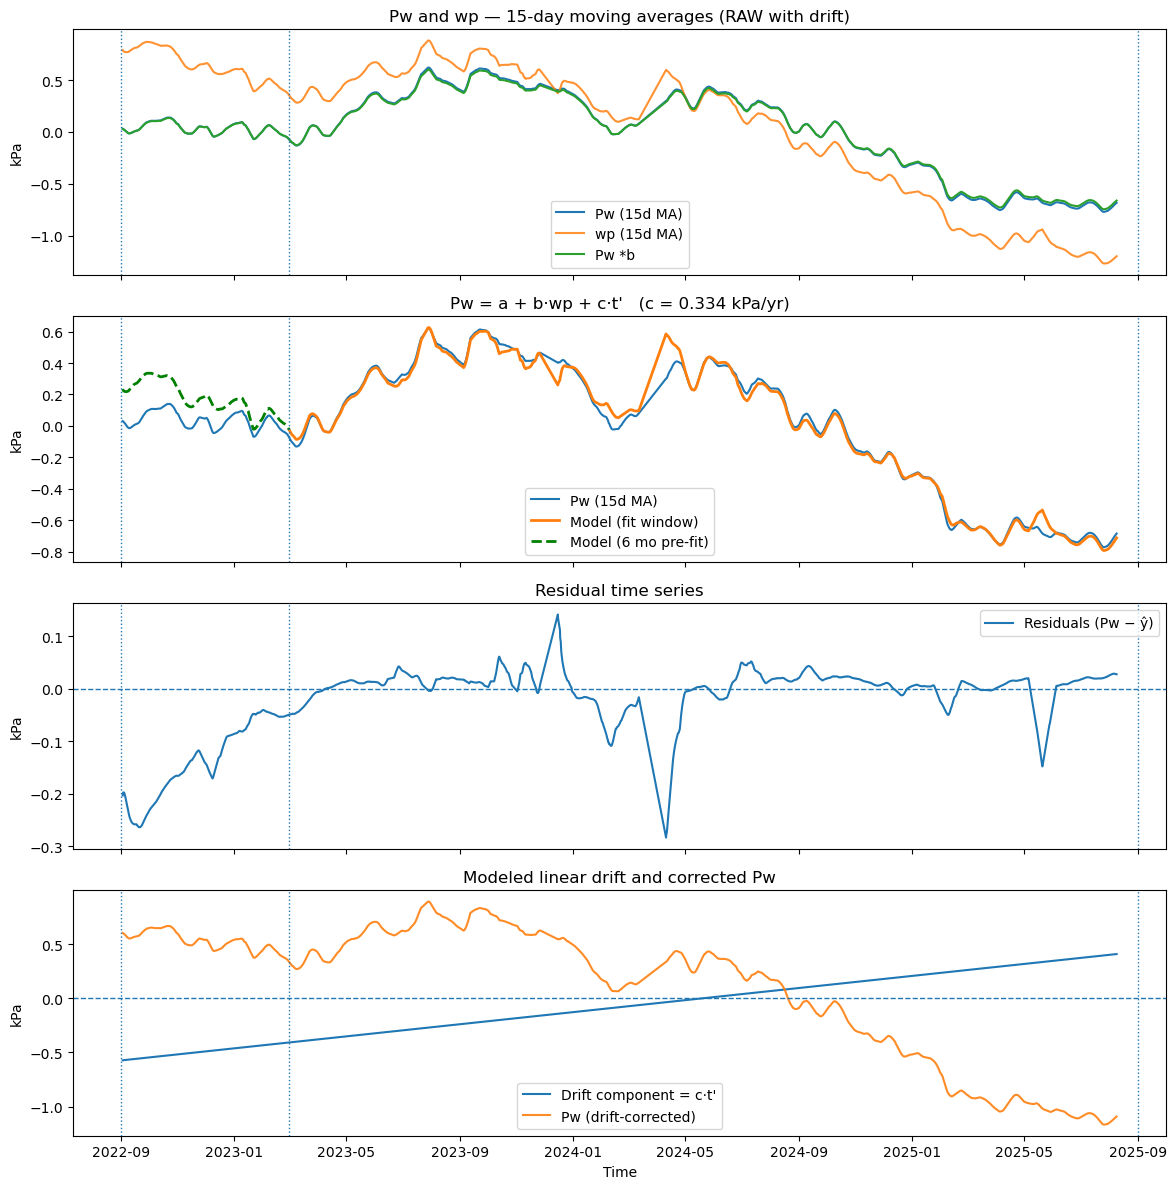

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) windows + prep -----------
show0 = pd.Timestamp('2022-09-01')   # display starts (adds prior year)
t0    = pd.Timestamp('2023-03-01')   # fit start
t1    = pd.Timestamp('2025-09-01')   # fit end (exclusive)
to_years = 365.25 * 86400.0

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
# normalize timezone info if present
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

# Keep Pw (drifting, FETCH West) and wp (drift-free, Node-B)
df = df.dropna(subset=["time", "Pw", "wp"]).sort_values("time")

# Show-window subset (prior year + fit window)
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("Pw model show window (2022-09 to 2025-09) has no data.")

# 15-day moving averages (time-based)
ma_full = df_show.set_index("time")[["Pw", "wp"]].rolling("15D").mean().dropna().copy()
ma_full["time"] = ma_full.index

# Fit subset (strictly within t0..t1)
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("Pw model fit window (2023-03 to 2025-09) has no data after MA.")

# ----------- 1) RAW + DRIFT regressors (wp raw; center time only) -----------
t_mid_fit = ma_fit.index[0] + (ma_fit.index[-1] - ma_fit.index[0]) / 2
ma_fit["tprime_years"] = (ma_fit.index - t_mid_fit).total_seconds() / to_years  # centered years

# ----------- 2) Fit Pw = a + b*wp + c*t' -----------
y = ma_fit["Pw"].to_numpy(float)
X = np.column_stack([
    np.ones(len(ma_fit)),                      # a
    ma_fit["wp"].to_numpy(float),              # b * wp (RAW)
    ma_fit["tprime_years"].to_numpy(float)     # c * t'
])
(a_w, b_w, c_w), *_ = np.linalg.lstsq(X, y, rcond=None)

# Diagnostics (fit window only)
ma_fit["Pw_hat"] = X @ np.array([a_w, b_w, c_w])
ma_fit["resid"]  = y - ma_fit["Pw_hat"]
rmse = float(np.sqrt(np.mean(ma_fit["resid"]**2)))

print("\nPw ~ a + b·wp + c·t'   (wp raw; t' centered in FIT: 2023-03..2025-09)")
print(f"a (kPa)     = {a_w:.4f}")
print(f"b (kPa/kPa) = {b_w:.4f}   # coupling to wp")
print(f"c (kPa/yr)  = {c_w:.4f}   # Pw linear drift rate")
print(f"RMSE (kPa)  = {rmse:.4f}")
print(f"N (15d-MA)  = {len(ma_fit)}")

# ----------- 3) Apply across FULL show window (same t' centering) -----------
ma_full["tprime_years"] = (ma_full.index - t_mid_fit).total_seconds() / to_years
ma_full["Pw_hat"] = a_w + b_w * ma_full["wp"].to_numpy(float) + c_w * ma_full["tprime_years"].to_numpy(float)
ma_full["resid"]  = ma_full["Pw"] - ma_full["Pw_hat"]
ma_full["drift_component"] = c_w * ma_full["tprime_years"]
ma_full["Pw_driftcorr"] = ma_full["Pw"] - ma_full["drift_component"]

# Masks for plotting
fit_mask   = (ma_full.index >= t0) & (ma_full.index < t1)
pre6_start = max(show0, t0 - pd.DateOffset(months=6))
pre6_mask  = (ma_full.index >= pre6_start) & (ma_full.index < t0)

# ----------- 4) plots -----------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# (a) Pw vs wp (both 15d MA) across FULL window
axes[0].plot(ma_full["time"], ma_full["Pw"], label="Pw (15d MA)")
axes[0].plot(ma_full["time"], ma_full["wp"], label="wp (15d MA)", alpha=0.85)
axes[0].plot(ma_full["time"], ma_full["Pw"]*b_w, label="Pw *b")
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("Pw and wp — 15-day moving averages (RAW with drift)")

# (b) Pw vs model with 6-month back-prediction
axes[1].plot(ma_full["time"], ma_full["Pw"], label="Pw (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "Pw_hat"], lw=2, label="Model (fit window)")
axes[1].plot(ma_full.loc[pre6_mask, "time"], ma_full.loc[pre6_mask, "Pw_hat"],
             ls="--", lw=2, color="green", label="Model (6 mo pre-fit)")
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title(f"Pw = a + b·wp + c·t'   (c = {c_w:.3f} kPa/yr)")

# (c) residuals across FULL window
axes[2].plot(ma_full["time"], ma_full["resid"], label="Residuals (Pw − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].legend(loc="best")
axes[2].set_title("Residual time series")

# (d) drift term & drift-corrected Pw across FULL window
axes[3].plot(ma_full["time"], ma_full["drift_component"], label="Drift component = c·t'")
axes[3].plot(ma_full["time"], ma_full["Pw_driftcorr"], label="Pw (drift-corrected)", alpha=0.9)
axes[3].axhline(0, ls="--", lw=1)
axes[3].set_ylabel("kPa"); axes[3].set_xlabel("Time"); axes[3].legend(loc="best")
axes[3].set_title("Modeled linear drift and corrected Pw")

# window markers
for ax in axes:
    ax.axvline(show0, ls=":", lw=1)
    ax.axvline(t0,    ls=":", lw=1)
    ax.axvline(t1,    ls=":", lw=1)

plt.tight_layout(); plt.show()

# Save params for reuse
pw_model_with_drift = {"a": a_w, "b": b_w, "c": c_w, "t_mid_fit": t_mid_fit}



Pw ~ a + b·wp   (RAW; no drift; FIT: 2023-03..2025-09)
a (kPa)     = 0.0262
b (kPa/kPa) = 0.6297   # coupling to wp
RMSE (kPa)  = 0.1058
N (15d-MA)  = 4591


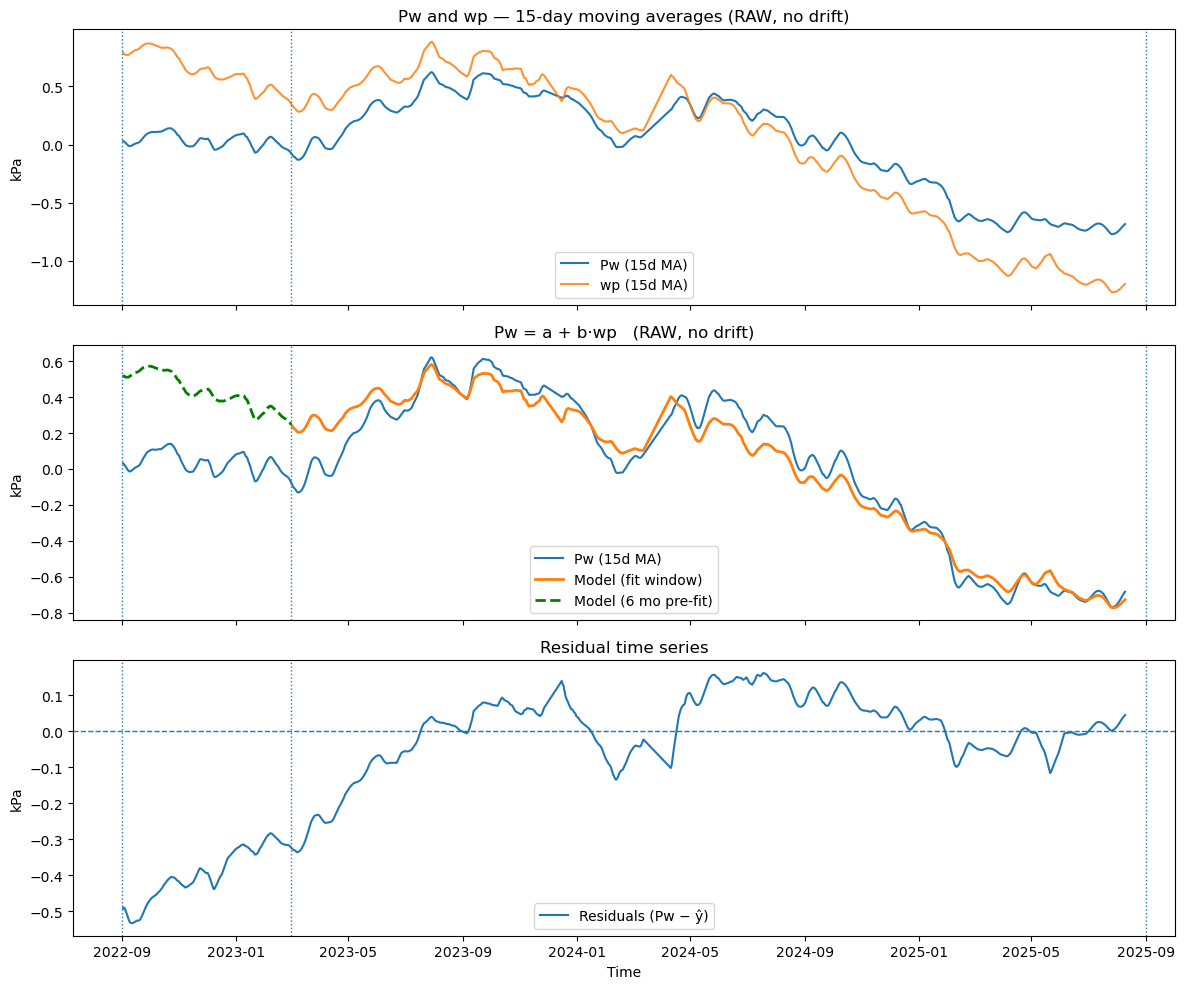

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) windows + prep -----------
show0 = pd.Timestamp('2022-09-01')   # display starts (adds prior year)
t0    = pd.Timestamp('2023-03-01')   # fit start
t1    = pd.Timestamp('2025-09-01')   # fit end (exclusive)

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
# normalize timezone info if present
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

# Keep Pw (drifting, FETCH West) and wp (drift-free, Node-B)
df = df.dropna(subset=["time", "Pw", "wp"]).sort_values("time")

# Show-window subset (prior year + fit window)
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("Pw model show window (2022-09 to 2025-09) has no data.")

# 15-day moving averages (time-based)
ma_full = df_show.set_index("time")[["Pw", "wp"]].rolling("15D").mean().dropna().copy()
ma_full["time"] = ma_full.index

# Fit subset (strictly within t0..t1)
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("Pw model fit window (2023-03 to 2025-09) has no data after MA.")

# ----------- 1) RAW (no drift): Pw = a + b*wp -----------
y = ma_fit["Pw"].to_numpy(float)
X = np.column_stack([np.ones(len(ma_fit)), ma_fit["wp"].to_numpy(float)])
(a_w, b_w), *_ = np.linalg.lstsq(X, y, rcond=None)

# Diagnostics (fit window only)
ma_fit["Pw_hat"] = X @ np.array([a_w, b_w])
ma_fit["resid"]  = y - ma_fit["Pw_hat"]
rmse = float(np.sqrt(np.mean(ma_fit["resid"]**2)))

print("\nPw ~ a + b·wp   (RAW; no drift; FIT: 2023-03..2025-09)")
print(f"a (kPa)     = {a_w:.4f}")
print(f"b (kPa/kPa) = {b_w:.4f}   # coupling to wp")
print(f"RMSE (kPa)  = {rmse:.4f}")
print(f"N (15d-MA)  = {len(ma_fit)}")

# ----------- 2) Apply across FULL show window -----------
ma_full["Pw_hat"] = a_w + b_w * ma_full["wp"].to_numpy(float)
ma_full["resid"]  = ma_full["Pw"] - ma_full["Pw_hat"]

# Masks for plotting (includes dashed 6-month pre-fit prediction)
fit_mask   = (ma_full.index >= t0) & (ma_full.index < t1)
pre6_start = max(show0, t0 - pd.DateOffset(months=6))
pre6_mask  = (ma_full.index >= pre6_start) & (ma_full.index < t0)

# ----------- 3) plots -----------
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# (a) Pw vs wp (both 15d MA) across FULL window
axes[0].plot(ma_full["time"], ma_full["Pw"], label="Pw (15d MA)")
axes[0].plot(ma_full["time"], ma_full["wp"], label="wp (15d MA)", alpha=0.85)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("Pw and wp — 15-day moving averages (RAW, no drift)")

# (b) Pw vs model with 6-month back-prediction
axes[1].plot(ma_full["time"], ma_full["Pw"], label="Pw (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "Pw_hat"], lw=2, label="Model (fit window)")
axes[1].plot(ma_full.loc[pre6_mask, "time"], ma_full.loc[pre6_mask, "Pw_hat"],
             ls="--", lw=2, color="green", label="Model (6 mo pre-fit)")
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title("Pw = a + b·wp   (RAW, no drift)")

# (c) residuals across FULL window
axes[2].plot(ma_full["time"], ma_full["resid"], label="Residuals (Pw − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].legend(loc="best"); axes[2].set_xlabel("Time")
axes[2].set_title("Residual time series")

# window markers
for ax in axes:
    ax.axvline(show0, ls=":", lw=1)
    ax.axvline(t0,    ls=":", lw=1)
    ax.axvline(t1,    ls=":", lw=1)

plt.tight_layout(); plt.show()

# Save params for reuse
pw_model_no_drift = {"a": a_w, "b": b_w}



Pw ~ a + b·Pc + c·t'   (Pc raw; t' centered in FIT: 2023-03..2025-09)
a (kPa)     = 0.0570
b (kPa/kPa) = 0.6671   # coupling to Pc
c (kPa/yr)  = 0.4818   # linear drift rate
RMSE (kPa)  = 0.0543
N (15d-MA)  = 4591


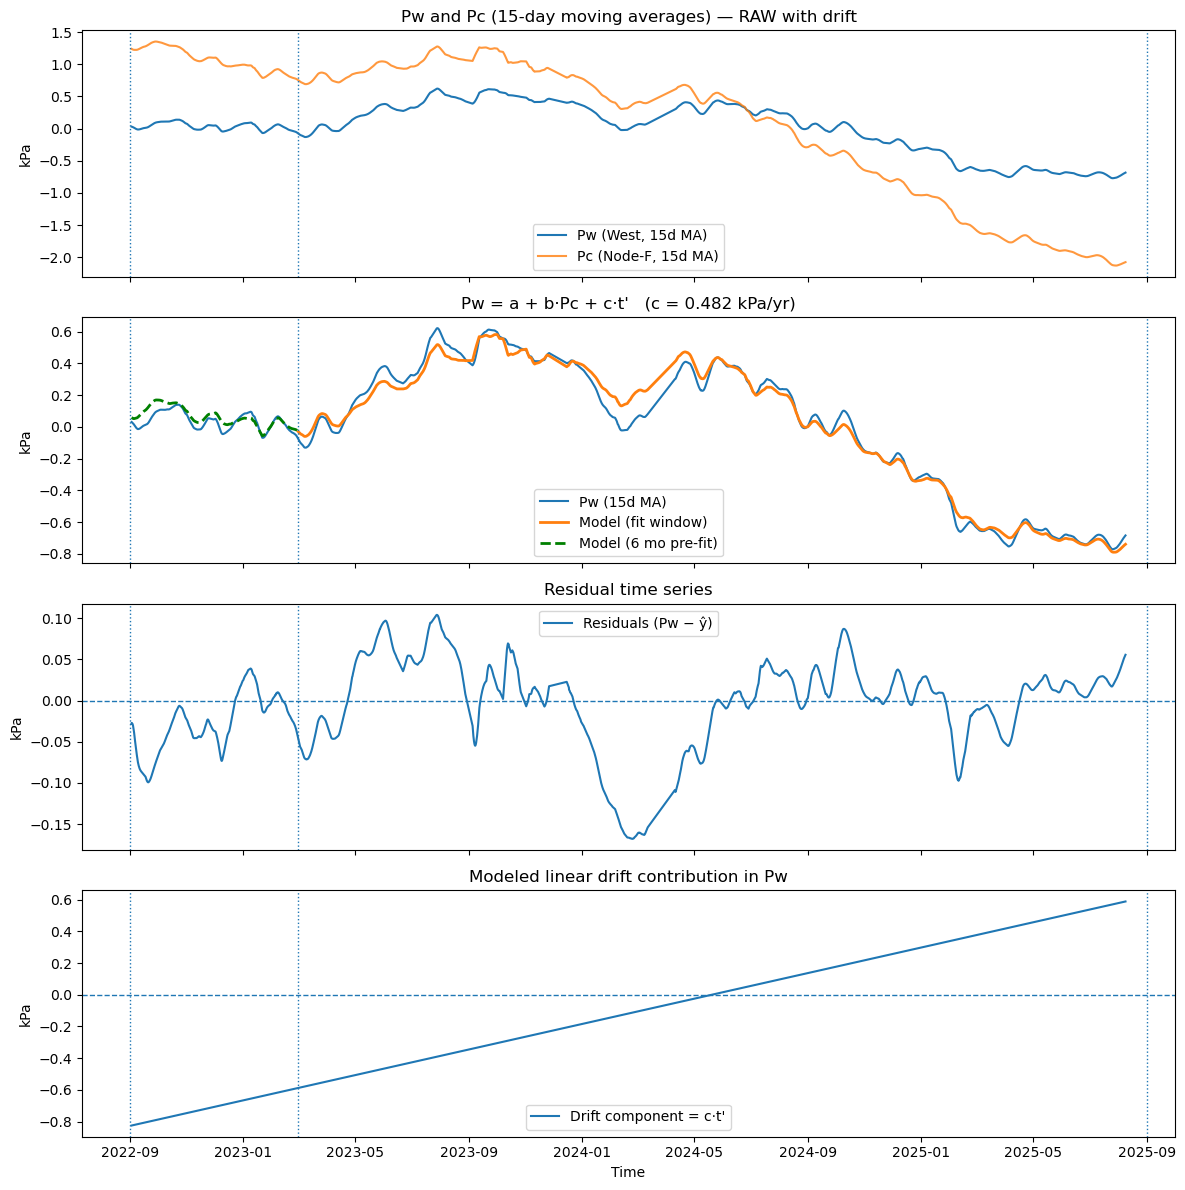

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) windows + prep -----------
show0 = pd.Timestamp('2022-09-01')   # show from here (adds the prior year)
t0    = pd.Timestamp('2023-03-01')   # fit start
t1    = pd.Timestamp('2025-09-01')   # fit end (exclusive)
to_years = 365.25 * 86400.0

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
# drop tz to avoid mixed tz errors
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

df = df.dropna(subset=["time", "Pw", "Pc"]).sort_values("time")

# Keep a display window covering the extra year + fit window
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No data in the combined show window (2022-09 to 2025-09).")

# 15-day moving average (time-based)
ma_full = (df_show.set_index("time")[["Pw", "Pc"]]
           .rolling("15D").mean().dropna().copy())
ma_full["time"] = ma_full.index

# Extract the FIT subset (strictly in-window)
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("Pw model fit window (2023-03 to 2025-09) has no data after MA.")

# ----------- 1) RAW + DRIFT regressors: Pc raw; center only time -----------
t_mid_fit = ma_fit.index[0] + (ma_fit.index[-1] - ma_fit.index[0]) / 2
ma_fit["tprime_years"] = (ma_fit.index - t_mid_fit).total_seconds() / to_years

# ----------- 2) Fit Pw = a + b*Pc + c*t' -----------
y = ma_fit["Pw"].to_numpy(float)
X = np.column_stack([
    np.ones(len(ma_fit)),
    ma_fit["Pc"].to_numpy(float),             # RAW Pc (no demeaning)
    ma_fit["tprime_years"].to_numpy(float)    # centered time
])
(a_n, b_n, c_n), *_ = np.linalg.lstsq(X, y, rcond=None)

# Diagnostics on the FIT window
ma_fit["Pw_hat"] = X @ np.array([a_n, b_n, c_n])
ma_fit["resid"]  = y - ma_fit["Pw_hat"]
rmse = float(np.sqrt(np.mean(ma_fit["resid"]**2)))

print("\nPw ~ a + b·Pc + c·t'   (Pc raw; t' centered in FIT: 2023-03..2025-09)")
print(f"a (kPa)     = {a_n:.4f}")
print(f"b (kPa/kPa) = {b_n:.4f}   # coupling to Pc")
print(f"c (kPa/yr)  = {c_n:.4f}   # linear drift rate")
print(f"RMSE (kPa)  = {rmse:.4f}")
print(f"N (15d-MA)  = {len(ma_fit)}")

# ----------- 3) Apply across FULL window (same t' centering) -----------
ma_full["tprime_years"] = (ma_full.index - t_mid_fit).total_seconds() / to_years
ma_full["Pw_hat"] = a_n + b_n * ma_full["Pc"].to_numpy(float) + c_n * ma_full["tprime_years"].to_numpy(float)
ma_full["resid"]  = ma_full["Pw"] - ma_full["Pw_hat"]
ma_full["drift_component"] = c_n * ma_full["tprime_years"]

# Masks for plotting (fit + 6-month pre-fit back-prediction)
fit_mask   = (ma_full.index >= t0) & (ma_full.index < t1)
pre6_start = max(show0, t0 - pd.DateOffset(months=6))
pre6_mask  = (ma_full.index >= pre6_start) & (ma_full.index < t0)

# ----------- 4) plots -----------
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# (a) Pw & Pc (15d MA)
axes[0].plot(ma_full["time"], ma_full["Pw"], label="Pw (West, 15d MA)")
axes[0].plot(ma_full["time"], ma_full["Pc"], label="Pc (Node-F, 15d MA)", alpha=0.8)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("Pw and Pc (15-day moving averages) — RAW with drift")

# (b) Model vs data, incl. 6-month pre-fit prediction (dashed green)
axes[1].plot(ma_full["time"], ma_full["Pw"], label="Pw (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "Pw_hat"], lw=2, label="Model (fit window)")
axes[1].plot(ma_full.loc[pre6_mask, "time"], ma_full.loc[pre6_mask, "Pw_hat"],
             ls="--", lw=2, color="green", label="Model (6 mo pre-fit)")
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title(f"Pw = a + b·Pc + c·t'   (c = {c_n:.3f} kPa/yr)")

# (c) residuals
axes[2].plot(ma_full["time"], ma_full["resid"], label="Residuals (Pw − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].legend(loc="best")
axes[2].set_title("Residual time series")

# (d) drift component
axes[3].plot(ma_full["time"], ma_full["drift_component"], label="Drift component = c·t'")
axes[3].axhline(0, ls="--", lw=1)
axes[3].set_ylabel("kPa"); axes[3].set_xlabel("Time"); axes[3].legend(loc="best")
axes[3].set_title("Modeled linear drift contribution in Pw")

# window markers
for ax in axes:
    ax.axvline(show0, ls=":", lw=1)
    ax.axvline(t0,    ls=":", lw=1)
    ax.axvline(t1,    ls=":", lw=1)

plt.tight_layout(); plt.show()

# Reuse params later
pw_pc_with_drift_params = {"a": a_n, "b": b_n, "c": c_n, "t_mid_fit": t_mid_fit}


In [46]:
# ----------- 6) start→finish depth metrics for Pw/Pc (cm) -----------
CM_PER_KPA = 9.94  # cm per kPa ( +kPa => deeper )

def window_means(s, n=30):
    s = s.dropna()
    n = min(n, len(s)//2) if len(s) >= 2 else 0
    if n == 0:
        return np.nan, np.nan, None, None
    first = s.iloc[:n].mean()
    last  = s.iloc[-n:].mean()
    return first, last, s.index[0], s.index[-1]

def to_depth_cm(p_kpa):
    return p_kpa * CM_PER_KPA

# Series (kPa)
Pw_kPa     = ma_full["Pw"]
Pc_kPa     = ma_full["Pc"]
drift_kPa  = ma_full["drift_component"]  # c_n * t' for Pw model

# (1) BEFORE drift correction: raw Pw
f1, l1, t_first, t_last = window_means(Pw_kPa, n=30)
d_before_cm = (l1 - f1) * CM_PER_KPA

# (2) AFTER drift correction: remove modeled linear drift from Pw
Pw_dc_kPa = Pw_kPa - drift_kPa
f2, l2, _, _ = window_means(Pw_dc_kPa, n=30)
d_after_cm = (l2 - f2) * CM_PER_KPA

# (3) Reference (assumed drift-free) used for fitting: Pc
f3, l3, _, _ = window_means(Pc_kPa, n=30)
d_ref_cm = (l3 - f3) * CM_PER_KPA

print("\nDepth change (first 30 vs last 30 of 15-day MAs) — Pw/Pc")
print(f"Window start: {t_first:%Y-%m-%d}, window end: {t_last:%Y-%m-%d}")
print(f"  • BEFORE drift correction (Pw raw):           {d_before_cm:+.2f} cm  ( + = deeper )")
print(f"  • AFTER  drift correction (Pw − c·t′):        {d_after_cm:+.2f} cm")
print(f"  • Reference (no-drift) station (Pc) change:   {d_ref_cm:+.2f} cm")

# ----------- 6b) also print start/end depths (cm) -----------
rows = []
def add_row(label, p_first, p_last):
    d_first = to_depth_cm(p_first) if np.isfinite(p_first) else np.nan
    d_last  = to_depth_cm(p_last)  if np.isfinite(p_last)  else np.nan
    rows.append({
        "metric": label,
        "start_depth_cm": d_first,
        "end_depth_cm": d_last,
        "delta_depth_cm": d_last - d_first
    })

add_row("Pw BEFORE drift", f1, l1) 
add_row("Pw AFTER drift",  f2, l2)
add_row("Reference Pc",    f3, l3)

depth_summary_pw = pd.DataFrame(rows)

print("\nStart/End Depths (first/last 30-point MAs; + = deeper):")
for _, r in depth_summary_pw.iterrows():
    print(f"  • {r['metric']:<16}  start = {r['start_depth_cm']:+.2f} cm, "
          f"end = {r['end_depth_cm']:+.2f} cm,  Δ = {r['delta_depth_cm']:+.2f} cm")

# Optional: keep the summary df around for logging/saving
# depth_summary_pw



Depth change (first 30 vs last 30 of 15-day MAs) — Pw/Pc
Window start: 2022-09-02, window end: 2025-08-09
  • BEFORE drift correction (Pw raw):           -7.14 cm  ( + = deeper )
  • AFTER  drift correction (Pw − c·t′):        -21.12 cm
  • Reference (no-drift) station (Pc) change:   -32.97 cm

Start/End Depths (first/last 30-point MAs; + = deeper):
  • Pw BEFORE drift   start = +0.15 cm, end = -6.99 cm,  Δ = -7.14 cm
  • Pw AFTER drift    start = +8.32 cm, end = -12.81 cm,  Δ = -21.12 cm
  • Reference Pc      start = +12.20 cm, end = -20.77 cm,  Δ = -32.97 cm


In [47]:
# Create DataFrame with time and drift-corrected pressure
output_df = pd.DataFrame({
    'time': Pw_dc_kPa.index,
    'pressure_drift_corrected_kPa': Pw_dc_kPa.values
})

# Save to CSV
output_file = 'Pw_drifcor.csv'
output_df.to_csv(output_file, index=False)
print(f"\nSaved {len(output_df)} records to {output_file}")
print(f"Columns: {list(output_df.columns)}")
print(f"\nFirst few rows:")
print(output_df.head())


Saved 5600 records to Pw_drifcor.csv
Columns: ['time', 'pressure_drift_corrected_kPa']

First few rows:
                 time  pressure_drift_corrected_kPa
0 2022-09-02 11:45:00                      0.856253
1 2022-09-02 15:45:00                      0.854763
2 2022-09-02 19:45:00                      0.854300
3 2022-09-02 23:45:00                      0.853452
4 2022-09-03 03:45:00                      0.851820



Pw ~ a + b·Pc   (RAW; no drift; FIT: 2023-03..2025-09)
a (kPa)     = 0.0299
b (kPa/kPa) = 0.3685   # coupling to Pc
RMSE (kPa)  = 0.1335
N (15d-MA)  = 4591


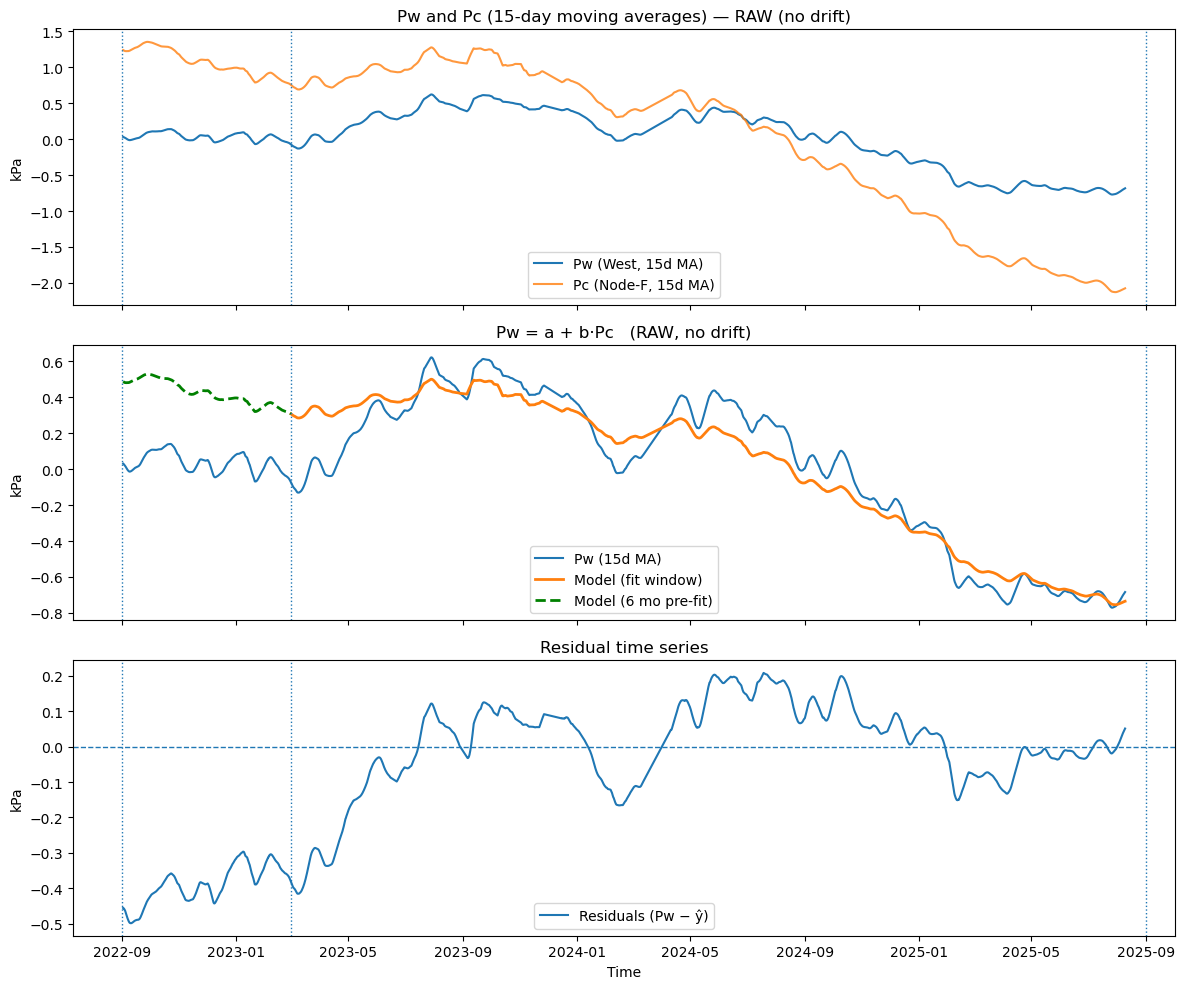

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------- 0) windows + prep -----------
show0 = pd.Timestamp('2022-09-01')   # show from here (adds the prior year)
t0    = pd.Timestamp('2023-03-01')   # fit start
t1    = pd.Timestamp('2025-09-01')   # fit end (exclusive)

df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
# drop tz to avoid mixed tz errors
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

df = df.dropna(subset=["time", "Pw", "Pc"]).sort_values("time")

# Keep a display window covering the extra year + fit window
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No data in the combined show window (2022-09 to 2025-09).")

# 15-day moving average (time-based)
ma_full = (df_show.set_index("time")[["Pw", "Pc"]]
           .rolling("15D").mean().dropna().copy())
ma_full["time"] = ma_full.index

# Extract the FIT subset (strictly in-window)
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("Pw model fit window (2023-03 to 2025-09) has no data after MA.")

# ----------- 1) RAW (no drift): Pw = a + b*Pc -----------
y = ma_fit["Pw"].to_numpy(float)
X = np.column_stack([
    np.ones(len(ma_fit)),
    ma_fit["Pc"].to_numpy(float)             # RAW Pc
])
(a_n, b_n), *_ = np.linalg.lstsq(X, y, rcond=None)

# Diagnostics on the FIT window
ma_fit["Pw_hat"] = X @ np.array([a_n, b_n])
ma_fit["resid"]  = y - ma_fit["Pw_hat"]
rmse = float(np.sqrt(np.mean(ma_fit["resid"]**2)))

print("\nPw ~ a + b·Pc   (RAW; no drift; FIT: 2023-03..2025-09)")
print(f"a (kPa)     = {a_n:.4f}")
print(f"b (kPa/kPa) = {b_n:.4f}   # coupling to Pc")
print(f"RMSE (kPa)  = {rmse:.4f}")
print(f"N (15d-MA)  = {len(ma_fit)}")

# ----------- 2) Apply across FULL window -----------
ma_full["Pw_hat"] = a_n + b_n * ma_full["Pc"].to_numpy(float)
ma_full["resid"]  = ma_full["Pw"] - ma_full["Pw_hat"]

# Masks for plotting (fit + 6-month pre-fit back-prediction)
fit_mask   = (ma_full.index >= t0) & (ma_full.index < t1)
pre6_start = max(show0, t0 - pd.DateOffset(months=6))
pre6_mask  = (ma_full.index >= pre6_start) & (ma_full.index < t0)

# ----------- 3) plots -----------
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# (a) Pw & Pc (15d MA)
axes[0].plot(ma_full["time"], ma_full["Pw"], label="Pw (West, 15d MA)")
axes[0].plot(ma_full["time"], ma_full["Pc"], label="Pc (Node-F, 15d MA)", alpha=0.8)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("Pw and Pc (15-day moving averages) — RAW (no drift)")

# (b) Model vs data, incl. 6-month pre-fit prediction (dashed green)
axes[1].plot(ma_full["time"], ma_full["Pw"], label="Pw (15d MA)")
axes[1].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "Pw_hat"], lw=2, label="Model (fit window)")
axes[1].plot(ma_full.loc[pre6_mask, "time"], ma_full.loc[pre6_mask, "Pw_hat"],
             ls="--", lw=2, color="green", label="Model (6 mo pre-fit)")
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title("Pw = a + b·Pc   (RAW, no drift)")

# (c) residuals
axes[2].plot(ma_full["time"], ma_full["resid"], label="Residuals (Pw − ŷ)")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].legend(loc="best"); axes[2].set_xlabel("Time")
axes[2].set_title("Residual time series")

# window markers
for ax in axes:
    ax.axvline(show0, ls=":", lw=1)
    ax.axvline(t0,    ls=":", lw=1)
    ax.axvline(t1,    ls=":", lw=1)

plt.tight_layout(); plt.show()

# Reuse params later
pw_pc_no_drift_params = {"a": a_n, "b": b_n}



Model: (Pc − Pw) = a + b·(Pc − wp) + c·t'   (t' centered in 2023-03..2025-09)
a (kPa)         = -0.0415
b (kPa/kPa)     = 1.0330   # coupling between differentials
c (kPa/yr)      = -0.3410   # linear drift in (Pc−Pw)
RMSE (kPa)      = 0.0386
N (15d-MA pts)  = 4591


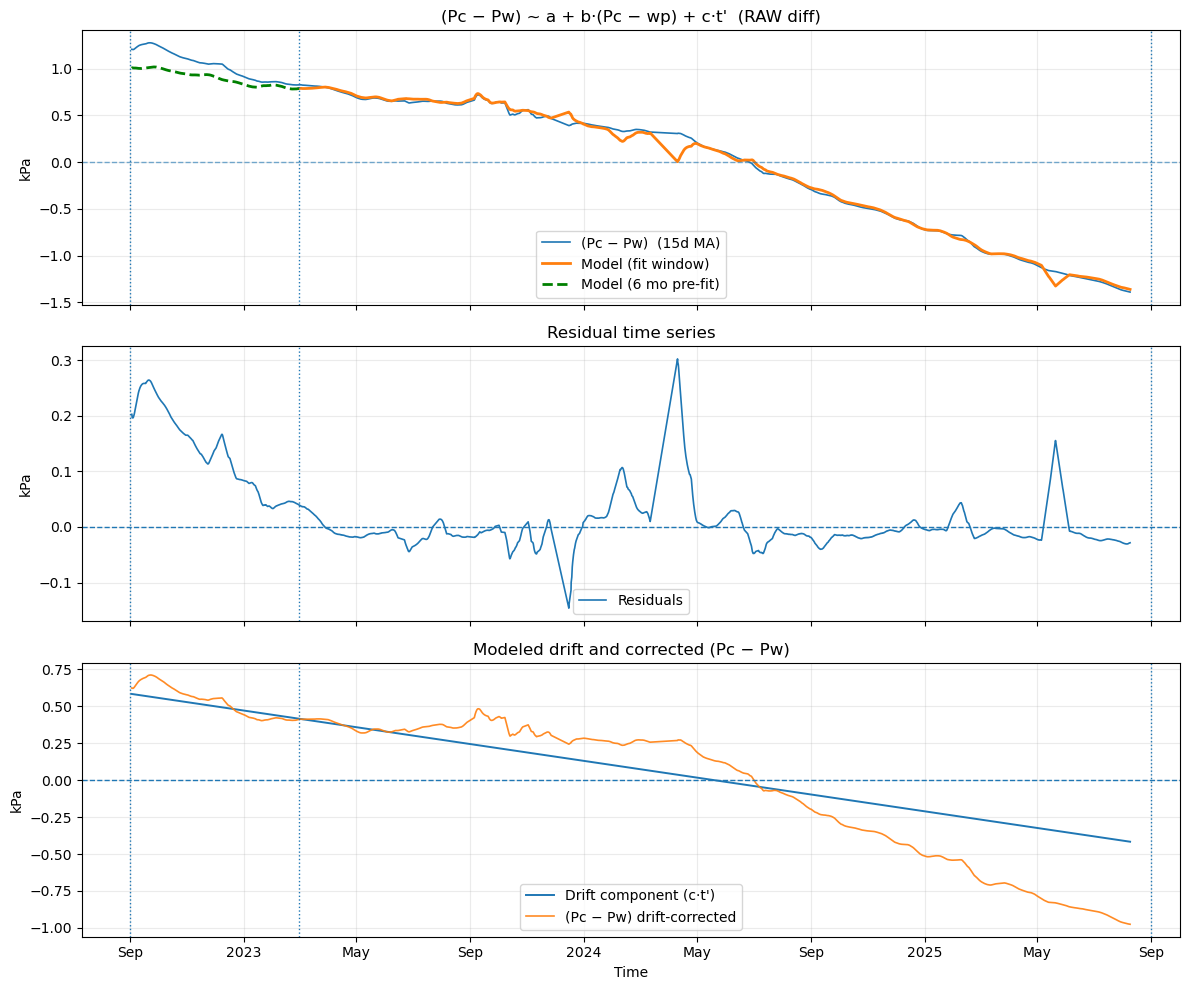

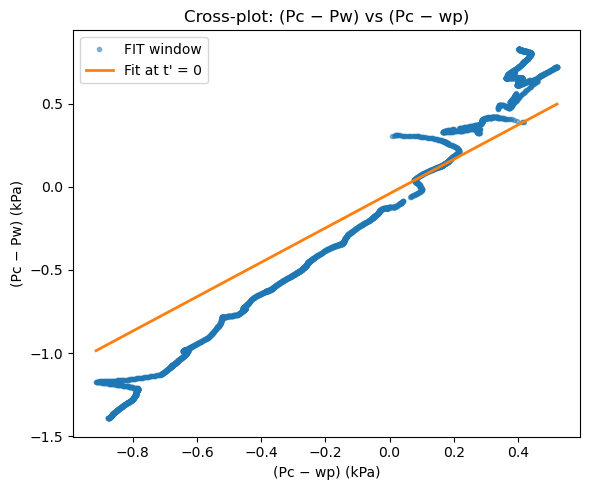

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -------- windows --------
show0 = pd.Timestamp('2022-09-01')   # display starts (adds prior year)
t0    = pd.Timestamp('2023-03-01')   # FIT start
t1    = pd.Timestamp('2025-09-01')   # FIT end (exclusive)
to_years = 365.25 * 86400.0

# -------- prep --------
df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

need = ["time", "Pc", "Pw", "wp"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

df = df.dropna(subset=need).sort_values("time")

# Differentials (RAW)
df["y"] = df["Pc"] - df["Pw"]   # target: (Pc - Pw)
df["x"] = df["Pc"] - df["wp"]   # predictor: (Pc - wp)

# Show-window subset
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No data in 2022-09..2025-09 for (Pc-Pw) fit.")

# 15-day moving averages for stability (remove .rolling(...) to use raw samples)
ma_full = (df_show.set_index("time")[["x", "y"]]
           .rolling("15D").mean()
           .dropna()
           .copy())
ma_full["time"] = ma_full.index

# FIT subset
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("FIT window (2023-03..2025-09) empty after 15d MA.")

# Center time within FIT window
t_mid_fit = ma_fit.index[0] + (ma_fit.index[-1] - ma_fit.index[0]) / 2
ma_fit["tprime_years"] = (ma_fit.index - t_mid_fit).total_seconds() / to_years

# ---- Fit: y = a + b*x + c*t' ----
Y = ma_fit["y"].to_numpy(float)
X = np.column_stack([
    np.ones(len(ma_fit)),
    ma_fit["x"].to_numpy(float),
    ma_fit["tprime_years"].to_numpy(float),
])
(a, b, c), *_ = np.linalg.lstsq(X, Y, rcond=None)

# Diagnostics on FIT window
ma_fit["y_hat"] = X @ np.array([a, b, c])
ma_fit["resid"] = ma_fit["y"] - ma_fit["y_hat"]
rmse = float(np.sqrt(np.mean(ma_fit["resid"]**2)))

print("\nModel: (Pc − Pw) = a + b·(Pc − wp) + c·t'   (t' centered in 2023-03..2025-09)")
print(f"a (kPa)         = {a:.4f}")
print(f"b (kPa/kPa)     = {b:.4f}   # coupling between differentials")
print(f"c (kPa/yr)      = {c:.4f}   # linear drift in (Pc−Pw)")
print(f"RMSE (kPa)      = {rmse:.4f}")
print(f"N (15d-MA pts)  = {len(ma_fit)}")

# ---- Apply across FULL window for back-prediction & drift term ----
ma_full["tprime_years"] = (ma_full.index - t_mid_fit).total_seconds() / to_years
ma_full["y_hat"] = a + b*ma_full["x"].to_numpy(float) + c*ma_full["tprime_years"].to_numpy(float)
ma_full["drift_component"] = c * ma_full["tprime_years"]         # c·t' only
ma_full["y_driftcorr"] = ma_full["y"] - ma_full["drift_component"]

# Masks
fit_mask   = (ma_full.index >= t0) & (ma_full.index < t1)
pre6_start = max(show0, t0 - pd.DateOffset(months=6))
pre6_mask  = (ma_full.index >= pre6_start) & (ma_full.index < t0)

# -------- Plots --------
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# (1) Data & model (with 6-month pre-fit dashed green)
axes[0].plot(ma_full["time"], ma_full["y"], lw=1.2, label="(Pc − Pw)  (15d MA)")
axes[0].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "y_hat"], lw=2.0, label="Model (fit window)")
axes[0].plot(ma_full.loc[pre6_mask, "time"], ma_full.loc[pre6_mask, "y_hat"],
             lw=2.0, ls="--", color="green", label="Model (6 mo pre-fit)")
axes[0].axhline(0, ls="--", lw=1, alpha=0.6)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("(Pc − Pw) ~ a + b·(Pc − wp) + c·t'  (RAW diff)")

# (2) Residuals
axes[1].plot(ma_full["time"], ma_full["y"] - ma_full["y_hat"], lw=1.2, label="Residuals")
axes[1].axhline(0, ls="--", lw=1)
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title("Residual time series")

# (3) Drift term & drift-corrected series
axes[2].plot(ma_full["time"], ma_full["drift_component"], lw=1.4, label="Drift component (c·t')")
axes[2].plot(ma_full["time"], ma_full["y_driftcorr"], lw=1.2, alpha=0.9, label="(Pc − Pw) drift-corrected")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].set_xlabel("Time"); axes[2].legend(loc="best")
axes[2].set_title("Modeled drift and corrected (Pc − Pw)")

for ax in axes:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.axvline(show0, ls=":", lw=1)
    ax.axvline(t0,    ls=":", lw=1)
    ax.axvline(t1,    ls=":", lw=1)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# ---- Cross-plot (FIT window only; t'=0 slice) ----
plt.figure(figsize=(6,5))
plt.plot(ma_fit["x"], ma_fit["y"], ".", alpha=0.5, label="FIT window")
xg = np.linspace(ma_fit["x"].min(), ma_fit["x"].max(), 200)
yg = a + b*xg  # t' = 0 slice
plt.plot(xg, yg, lw=2, label="Fit at t' = 0")
plt.xlabel("(Pc − wp) (kPa)"); plt.ylabel("(Pc − Pw) (kPa)")
plt.title("Cross-plot: (Pc − Pw) vs (Pc − wp)")
plt.legend(); plt.tight_layout(); plt.show()

# Parameters if you want to store them:
diff_fit_params_with_drift = {"a": a, "b": b, "c": c, "t_mid_fit": t_mid_fit}



Model: (Pc − Pw) = a + b·(Pc − wp)   (RAW; no drift; FIT: 2023-03..2025-09)
a (kPa)         = -0.0178
b (kPa/kPa)     = 1.5608   # coupling between differentials
RMSE (kPa)      = 0.0808
N (15d-MA pts)  = 4591


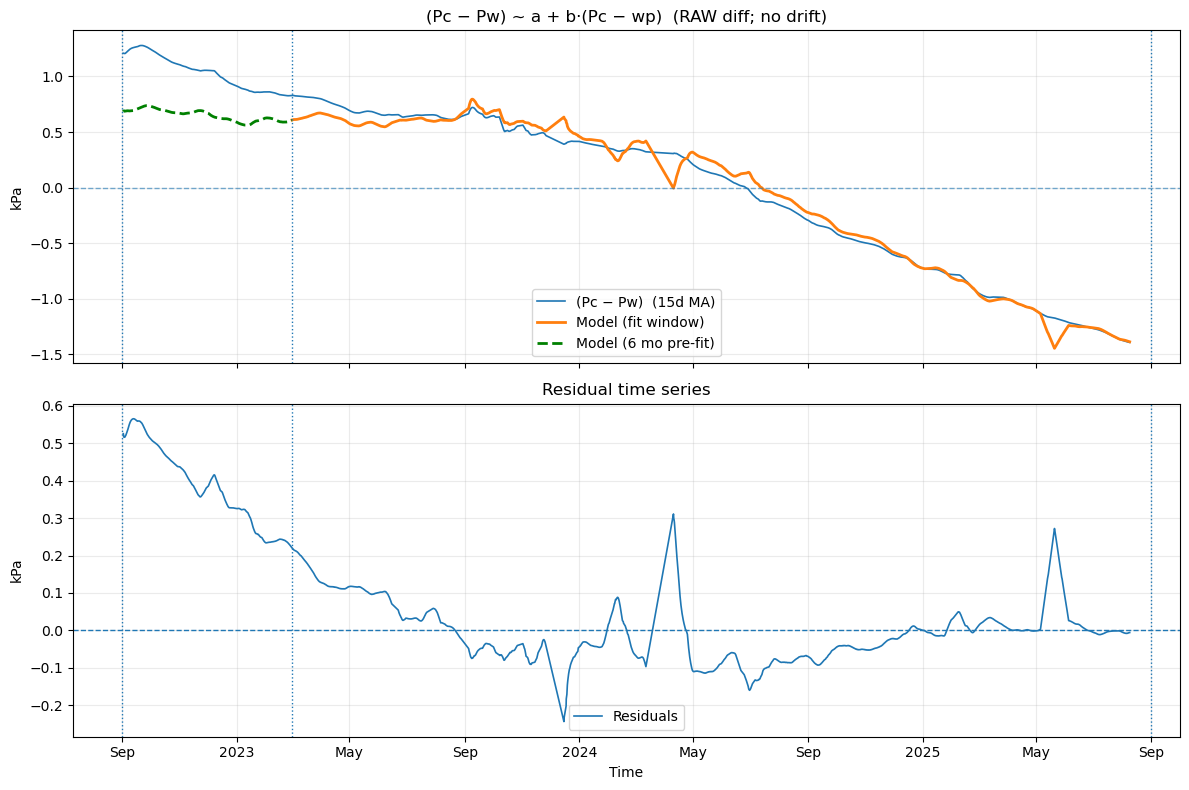

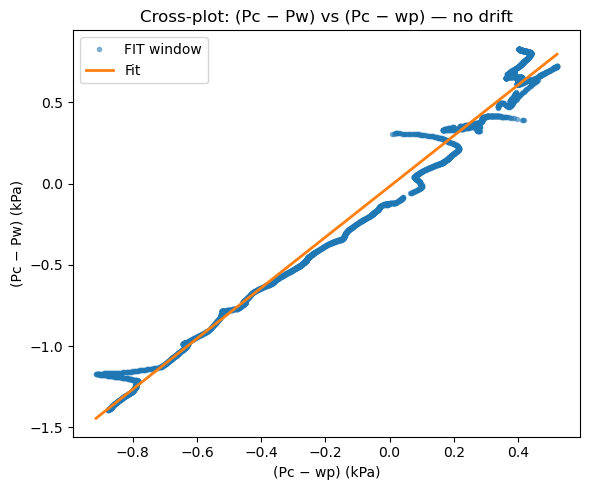

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -------- windows --------
show0 = pd.Timestamp('2022-09-01')   # display starts (adds prior year)
t0    = pd.Timestamp('2023-03-01')   # FIT start
t1    = pd.Timestamp('2025-09-01')   # FIT end (exclusive)

# -------- prep --------
df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

need = ["time", "Pc", "Pw", "wp"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

df = df.dropna(subset=need).sort_values("time")

# Differentials (RAW)
df["y"] = df["Pc"] - df["Pw"]   # target: (Pc - Pw)
df["x"] = df["Pc"] - df["wp"]   # predictor: (Pc - wp)

# Show-window subset
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No data in 2022-09..2025-09 for (Pc-Pw) fit.")

# 15-day moving averages (remove rolling(...) to use raw samples)
ma_full = (df_show.set_index("time")[["x", "y"]]
           .rolling("15D").mean()
           .dropna()
           .copy())
ma_full["time"] = ma_full.index

# FIT subset
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("FIT window (2023-03..2025-09) empty after 15d MA.")

# ---- Fit: y = a + b*x  (NO drift) ----
Y = ma_fit["y"].to_numpy(float)
X = np.column_stack([
    np.ones(len(ma_fit)),
    ma_fit["x"].to_numpy(float),
])
(a, b), *_ = np.linalg.lstsq(X, Y, rcond=None)

# Diagnostics on FIT window
ma_fit["y_hat"] = X @ np.array([a, b])
ma_fit["resid"] = ma_fit["y"] - ma_fit["y_hat"]
rmse = float(np.sqrt(np.mean(ma_fit["resid"]**2)))

print("\nModel: (Pc − Pw) = a + b·(Pc − wp)   (RAW; no drift; FIT: 2023-03..2025-09)")
print(f"a (kPa)         = {a:.4f}")
print(f"b (kPa/kPa)     = {b:.4f}   # coupling between differentials")
print(f"RMSE (kPa)      = {rmse:.4f}")
print(f"N (15d-MA pts)  = {len(ma_fit)}")

# ---- Apply across FULL window for back-prediction ----
ma_full["y_hat"] = a + b*ma_full["x"].to_numpy(float)

# Masks (styling)
fit_mask   = (ma_full.index >= t0) & (ma_full.index < t1)
pre6_start = max(show0, t0 - pd.DateOffset(months=6))
pre6_mask  = (ma_full.index >= pre6_start) & (ma_full.index < t0)

# -------- Plots --------
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# (1) Data & model (with 6-month pre-fit dashed green)
axes[0].plot(ma_full["time"], ma_full["y"], lw=1.2, label="(Pc − Pw)  (15d MA)")
axes[0].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "y_hat"], lw=2.0, label="Model (fit window)")
axes[0].plot(ma_full.loc[pre6_mask, "time"], ma_full.loc[pre6_mask, "y_hat"],
             lw=2.0, ls="--", color="green", label="Model (6 mo pre-fit)")
axes[0].axhline(0, ls="--", lw=1, alpha=0.6)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("(Pc − Pw) ~ a + b·(Pc − wp)  (RAW diff; no drift)")

# (2) Residuals
axes[1].plot(ma_full["time"], ma_full["y"] - ma_full["y_hat"], lw=1.2, label="Residuals")
axes[1].axhline(0, ls="--", lw=1)
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best"); axes[1].set_xlabel("Time")
axes[1].set_title("Residual time series")

for ax in axes:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.axvline(show0, ls=":", lw=1)
    ax.axvline(t0,    ls=":", lw=1)
    ax.axvline(t1,    ls=":", lw=1)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# ---- Cross-plot (FIT window only) ----
plt.figure(figsize=(6,5))
plt.plot(ma_fit["x"], ma_fit["y"], ".", alpha=0.5, label="FIT window")
xg = np.linspace(ma_fit["x"].min(), ma_fit["x"].max(), 200)
yg = a + b*xg
plt.plot(xg, yg, lw=2, label="Fit")
plt.xlabel("(Pc − wp) (kPa)"); plt.ylabel("(Pc − Pw) (kPa)")
plt.title("Cross-plot: (Pc − Pw) vs (Pc − wp) — no drift")
plt.legend(); plt.tight_layout(); plt.show()

# Parameters if you want to store them:
diff_fit_params_no_drift = {"a": a, "b": b}



Model: (Pc − Pe) = a + b·(Pc − ep) + c·t'   (t' centered in 2023-03..2025-09)
a (kPa)         = 0.0069
b (kPa/kPa)     = 0.5969   # coupling between differentials
c (kPa/yr)      = -0.1618   # linear drift in (Pc−Pe)
RMSE (kPa)      = 0.0320
N (15d-MA pts)  = 4591


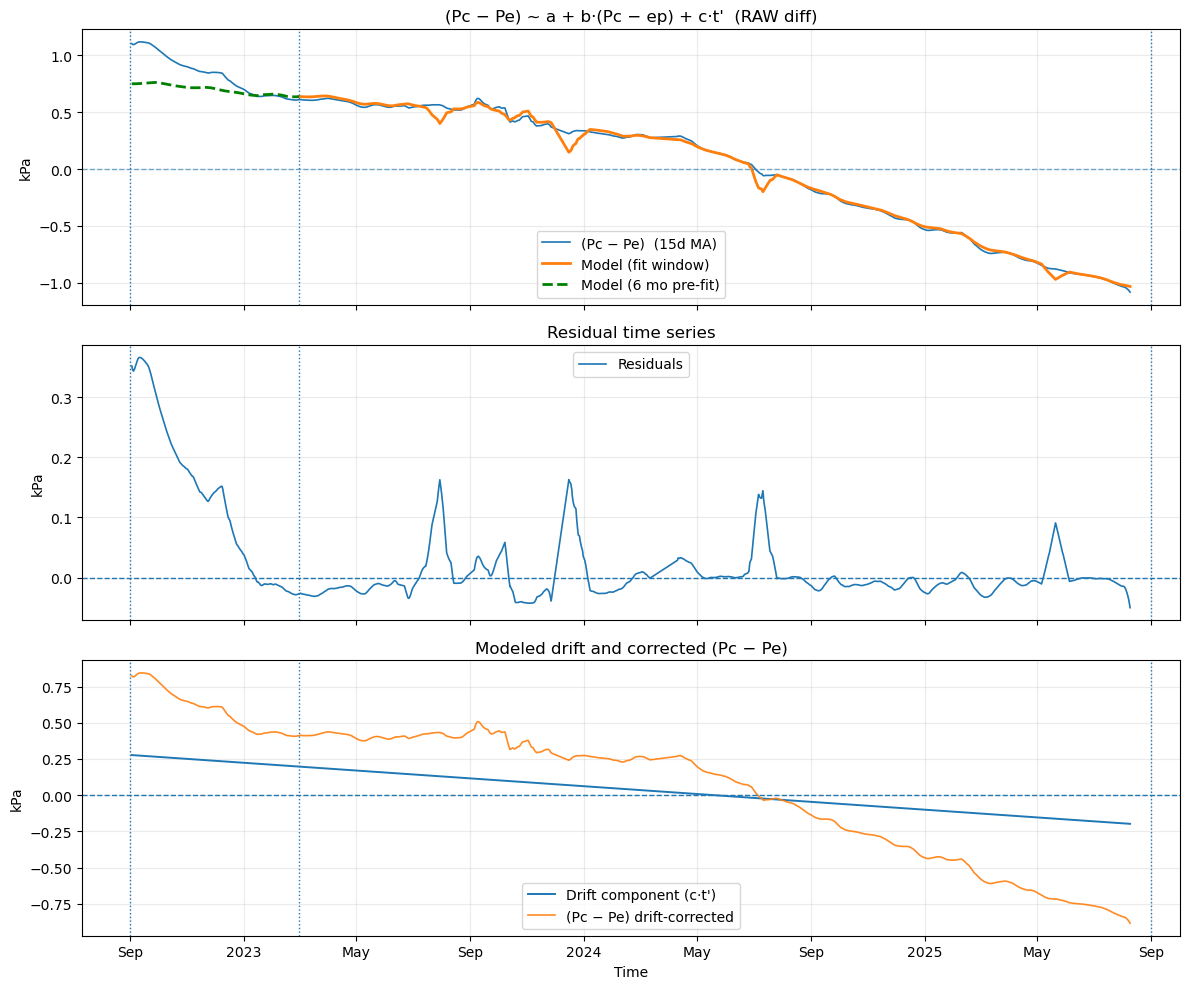

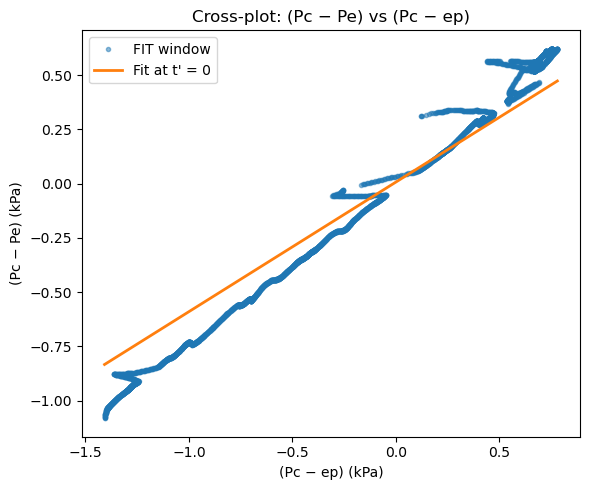

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -------- windows --------
show0 = pd.Timestamp('2022-09-01')   # display starts (adds prior year)
t0    = pd.Timestamp('2023-03-01')   # FIT start
t1    = pd.Timestamp('2025-09-01')   # FIT end (exclusive)
to_years = 365.25 * 86400.0

# -------- prep --------
df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
# normalize timezone if present
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

need = ["time", "Pc", "Pe", "ep"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

df = df.dropna(subset=need).sort_values("time")

# Build raw differentials
df["y"] = df["Pc"] - df["Pe"]      # target
df["x"] = df["Pc"] - df["ep"]      # predictor

# Show-window subset (prior year + fit window)
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No data in 2022-09..2025-09 for differential fit.")

# 15-day moving averages for stability
ma_full = (df_show.set_index("time")[["x", "y"]]
           .rolling("15D").mean()
           .dropna()
           .copy())
ma_full["time"] = ma_full.index

# Fit subset
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("FIT window (2023-03..2025-09) empty after 15d MA.")

# Center time within FIT window
t_mid_fit = ma_fit.index[0] + (ma_fit.index[-1] - ma_fit.index[0]) / 2
ma_fit["tprime_years"] = (ma_fit.index - t_mid_fit).total_seconds() / to_years

# ---- Fit: y = a + b*x + c*t' ----
Y = ma_fit["y"].to_numpy(float)
X = np.column_stack([
    np.ones(len(ma_fit)),
    ma_fit["x"].to_numpy(float),
    ma_fit["tprime_years"].to_numpy(float),
])
(a, b, c), *_ = np.linalg.lstsq(X, Y, rcond=None)

# Diagnostics on FIT window
ma_fit["y_hat"] = X @ np.array([a, b, c])
ma_fit["resid"] = ma_fit["y"] - ma_fit["y_hat"]
rmse = float(np.sqrt(np.mean(ma_fit["resid"]**2)))

print("\nModel: (Pc − Pe) = a + b·(Pc − ep) + c·t'   (t' centered in 2023-03..2025-09)")
print(f"a (kPa)         = {a:.4f}")
print(f"b (kPa/kPa)     = {b:.4f}   # coupling between differentials")
print(f"c (kPa/yr)      = {c:.4f}   # linear drift in (Pc−Pe)")
print(f"RMSE (kPa)      = {rmse:.4f}")
print(f"N (15d-MA pts)  = {len(ma_fit)}")

# ---- Apply across FULL show window for back-pred & drift term ----
ma_full["tprime_years"] = (ma_full.index - t_mid_fit).total_seconds() / to_years
ma_full["y_hat"] = a + b*ma_full["x"].to_numpy(float) + c*ma_full["tprime_years"].to_numpy(float)
ma_full["drift_component"] = c * ma_full["tprime_years"]         # c·t' only
ma_full["y_driftcorr"] = ma_full["y"] - ma_full["drift_component"]

# Masks (6-month pre-fit window + fit)
fit_mask   = (ma_full.index >= t0) & (ma_full.index < t1)
pre6_start = max(show0, t0 - pd.DateOffset(months=6))
pre6_mask  = (ma_full.index >= pre6_start) & (ma_full.index < t0)

# -------- Plots --------
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# (1) Data & model
axes[0].plot(ma_full["time"], ma_full["y"], lw=1.2, label="(Pc − Pe)  (15d MA)")
axes[0].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "y_hat"], lw=2.0, label="Model (fit window)")
axes[0].plot(ma_full.loc[pre6_mask, "time"], ma_full.loc[pre6_mask, "y_hat"],
             lw=2.0, ls="--", color="green", label="Model (6 mo pre-fit)")
axes[0].axhline(0, ls="--", lw=1, alpha=0.6)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("(Pc − Pe) ~ a + b·(Pc − ep) + c·t'  (RAW diff)")

# (2) Residuals
axes[1].plot(ma_full["time"], ma_full["y"] - ma_full["y_hat"], lw=1.2, label="Residuals")
axes[1].axhline(0, ls="--", lw=1)
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best")
axes[1].set_title("Residual time series")

# (3) Drift term & drift-corrected series
axes[2].plot(ma_full["time"], ma_full["drift_component"], lw=1.4, label="Drift component (c·t')")
axes[2].plot(ma_full["time"], ma_full["y_driftcorr"], lw=1.2, alpha=0.9, label="(Pc − Pe) drift-corrected")
axes[2].axhline(0, ls="--", lw=1)
axes[2].set_ylabel("kPa"); axes[2].set_xlabel("Time"); axes[2].legend(loc="best")
axes[2].set_title("Modeled drift and corrected (Pc − Pe)")

for ax in axes:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.axvline(show0, ls=":", lw=1)
    ax.axvline(t0,    ls=":", lw=1)
    ax.axvline(t1,    ls=":", lw=1)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# ---- Cross-plot (FIT window only; t'=0 slice) ----
plt.figure(figsize=(6,5))
plt.plot(ma_fit["x"], ma_fit["y"], ".", alpha=0.5, label="FIT window")
xg = np.linspace(ma_fit["x"].min(), ma_fit["x"].max(), 200)
yg = a + b*xg  # t' = 0 slice
plt.plot(xg, yg, lw=2, label="Fit at t' = 0")
plt.xlabel("(Pc − ep) (kPa)"); plt.ylabel("(Pc − Pe) (kPa)")
plt.title("Cross-plot: (Pc − Pe) vs (Pc − ep)")
plt.legend(); plt.tight_layout(); plt.show()

# If you want the parameters programmatically:
diff_fit_params_with_drift = {"a": a, "b": b, "c": c, "t_mid_fit": t_mid_fit}



Model: (Pc − Pe) = a + b·(Pc − ep)   (RAW; no drift; FIT: 2023-03..2025-09)
a (kPa)         = 0.0178
b (kPa/kPa)     = 0.7547   # coupling between differentials
RMSE (kPa)      = 0.0439
N (15d-MA pts)  = 4591


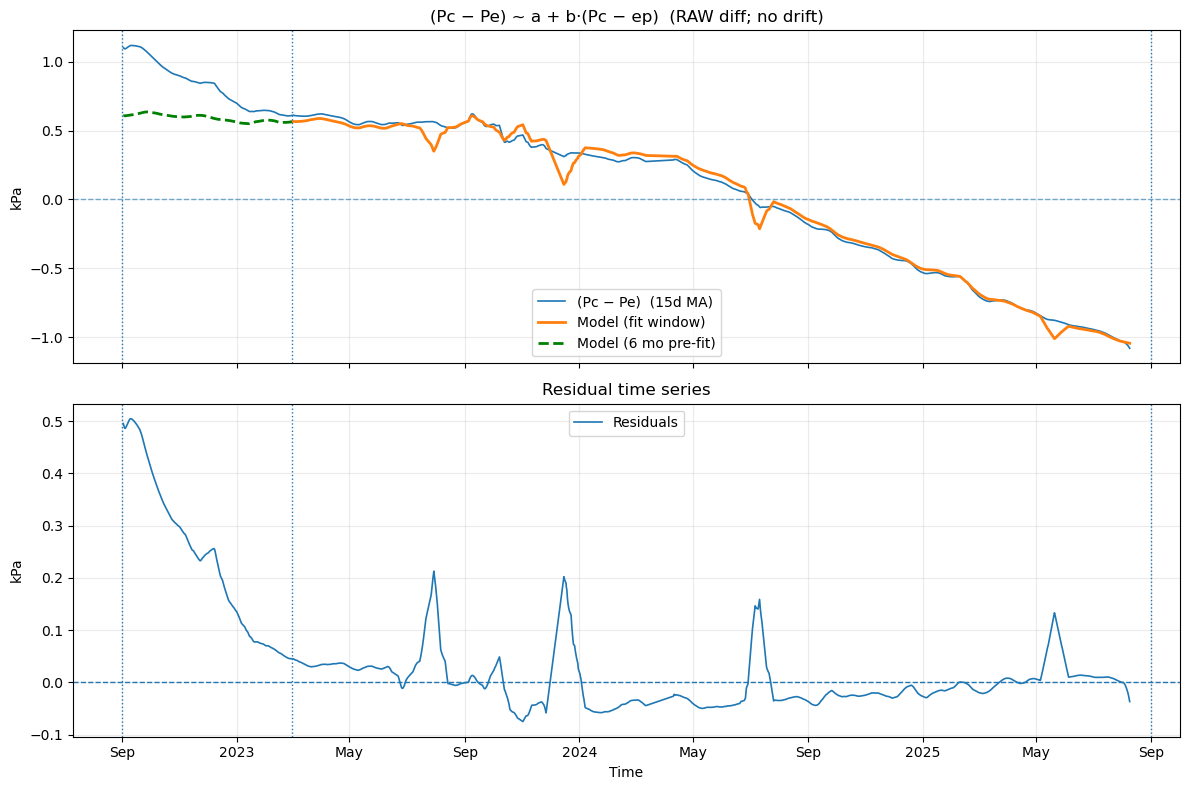

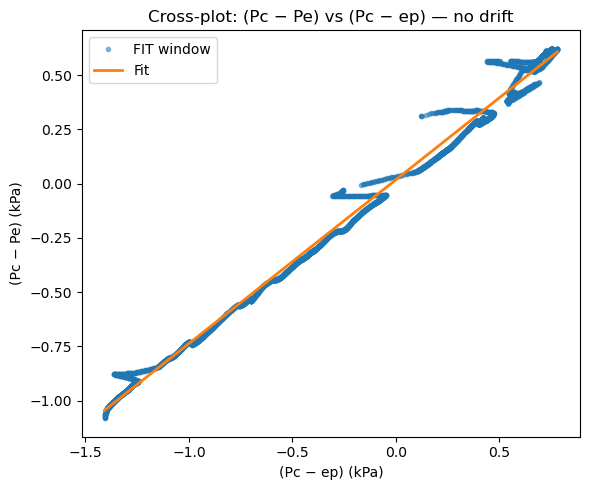

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -------- windows --------
show0 = pd.Timestamp('2022-09-01')   # display starts (adds prior year)
t0    = pd.Timestamp('2023-03-01')   # FIT start
t1    = pd.Timestamp('2025-09-01')   # FIT end (exclusive)

# -------- prep --------
df = merged.copy()
df["time"] = pd.to_datetime(df["time"], errors="coerce")
# normalize timezone if present
for _ in range(2):
    try:
        df["time"] = df["time"].dt.tz_convert(None); break
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None); break
        except Exception:
            pass

need = ["time", "Pc", "Pe", "ep"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

df = df.dropna(subset=need).sort_values("time")

# Build raw differentials
df["y"] = df["Pc"] - df["Pe"]      # target
df["x"] = df["Pc"] - df["ep"]      # predictor

# Show-window subset
df_show = df[(df["time"] >= show0) & (df["time"] < t1)].copy()
if df_show.empty:
    raise ValueError("No data in 2022-09..2025-09 for differential fit.")

# 15-day moving averages for stability
ma_full = (df_show.set_index("time")[["x", "y"]]
           .rolling("15D").mean()
           .dropna()
           .copy())
ma_full["time"] = ma_full.index

# Fit subset
ma_fit = ma_full[(ma_full.index >= t0) & (ma_full.index < t1)].copy()
if ma_fit.empty:
    raise ValueError("FIT window (2023-03..2025-09) empty after 15d MA.")

# ---- Fit: y = a + b*x (NO drift) ----
Y = ma_fit["y"].to_numpy(float)
X = np.column_stack([
    np.ones(len(ma_fit)),
    ma_fit["x"].to_numpy(float),
])
(a, b), *_ = np.linalg.lstsq(X, Y, rcond=None)

# Diagnostics on FIT window
ma_fit["y_hat"] = X @ np.array([a, b])
ma_fit["resid"] = ma_fit["y"] - ma_fit["y_hat"]
rmse = float(np.sqrt(np.mean(ma_fit["resid"]**2)))

print("\nModel: (Pc − Pe) = a + b·(Pc − ep)   (RAW; no drift; FIT: 2023-03..2025-09)")
print(f"a (kPa)         = {a:.4f}")
print(f"b (kPa/kPa)     = {b:.4f}   # coupling between differentials")
print(f"RMSE (kPa)      = {rmse:.4f}")
print(f"N (15d-MA pts)  = {len(ma_fit)}")

# ---- Apply across FULL show window for back-prediction ----
ma_full["y_hat"] = a + b*ma_full["x"].to_numpy(float)

# Masks (6-month pre-fit window + fit)
fit_mask   = (ma_full.index >= t0) & (ma_full.index < t1)
pre6_start = max(show0, t0 - pd.DateOffset(months=6))
pre6_mask  = (ma_full.index >= pre6_start) & (ma_full.index < t0)

# -------- Plots --------
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# (1) Data & model (with dashed green 6-month pre-fit)
axes[0].plot(ma_full["time"], ma_full["y"], lw=1.2, label="(Pc − Pe)  (15d MA)")
axes[0].plot(ma_full.loc[fit_mask, "time"], ma_full.loc[fit_mask, "y_hat"], lw=2.0, label="Model (fit window)")
axes[0].plot(ma_full.loc[pre6_mask, "time"], ma_full.loc[pre6_mask, "y_hat"],
             lw=2.0, ls="--", color="green", label="Model (6 mo pre-fit)")
axes[0].axhline(0, ls="--", lw=1, alpha=0.6)
axes[0].set_ylabel("kPa"); axes[0].legend(loc="best")
axes[0].set_title("(Pc − Pe) ~ a + b·(Pc − ep)  (RAW diff; no drift)")

# (2) Residuals
axes[1].plot(ma_full["time"], ma_full["y"] - ma_full["y_hat"], lw=1.2, label="Residuals")
axes[1].axhline(0, ls="--", lw=1)
axes[1].set_ylabel("kPa"); axes[1].legend(loc="best"); axes[1].set_xlabel("Time")
axes[1].set_title("Residual time series")

for ax in axes:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.axvline(show0, ls=":", lw=1)
    ax.axvline(t0,    ls=":", lw=1)
    ax.axvline(t1,    ls=":", lw=1)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# ---- Cross-plot (FIT window only) ----
plt.figure(figsize=(6,5))
plt.plot(ma_fit["x"], ma_fit["y"], ".", alpha=0.5, label="FIT window")
xg = np.linspace(ma_fit["x"].min(), ma_fit["x"].max(), 200)
yg = a + b*xg
plt.plot(xg, yg, lw=2, label="Fit")
plt.xlabel("(Pc − ep) (kPa)"); plt.ylabel("(Pc − Pe) (kPa)")
plt.title("Cross-plot: (Pc − Pe) vs (Pc − ep) — no drift")
plt.legend(); plt.tight_layout(); plt.show()

# If you want the parameters programmatically:
diff_fit_params_no_drift = {"a": a, "b": b}


In [47]:
import numpy as np

# ---------------- inputs ----------------
# Observed baseline changes (cm): [EF-NF, WF-NF, WF-EF]
y = np.array([24.0, 12.0, 36.0])

# G columns = unit-slip (1 m) responses from [East_fault, West_fault]
G = np.array([
    [9.04,  3.76],   # EF-NF
    [5.53, 17.07],   # WF-NF
    [14.42, 22.64],  # WF-EF
])

g1, g2 = G[:, 0], G[:, 1]

# -------------- helpers -----------------
def solve_unconstrained(G, y):
    s, *_ = np.linalg.lstsq(G, y, rcond=None)
    ypred = G @ s
    resid = y - ypred
    rmse = np.sqrt(np.mean(resid**2))
    return s, ypred, resid, rmse

def best_on_boundary(col, y):
    """Best 1D fit y ≈ col * s (s >= 0)."""
    s = max(0.0, (col @ y) / (col @ col))
    ypred = col * s
    resid = y - ypred
    rmse = np.sqrt(np.mean(resid**2))
    return s, ypred, resid, rmse

def solve_nonnegative(G, y):
    # Unconstrained
    s_uc, y_uc, r_uc, rmse_uc = solve_unconstrained(G, y)
    if np.all(s_uc >= 0):
        return s_uc, y_uc, r_uc, rmse_uc

    # Otherwise, check both boundaries: (sE>=0,sW=0) and (sE=0,sW>=0)
    sE_b, yE_b, rE_b, rmseE = best_on_boundary(G[:,0], y)
    sW_b, yW_b, rW_b, rmseW = best_on_boundary(G[:,1], y)
    if rmseE <= rmseW:
        s = np.array([sE_b, 0.0])
        return s, yE_b, rE_b, rmseE
    else:
        s = np.array([0.0, sW_b])
        return s, yW_b, rW_b, rmseW

def best_with_min_west(G, y, min_west=0.0):
    """Force sW >= min_west, sE >= 0; solve for best sE analytically."""
    g1, g2 = G[:,0], G[:,1]
    # For fixed sW, optimal sE>=0 is projection in 1D:
    def best_sE(sW):
        rhs = y - g2*sW
        sE = (g1 @ rhs) / (g1 @ g1)
        return max(0.0, sE)

    sW_grid = np.linspace(min_west, min_west + 3.0, 601)
    best = None
    for sW in sW_grid:
        sE = best_sE(sW)
        ypred = g1*sE + g2*sW
        resid = y - ypred
        rmse = np.sqrt(np.mean(resid**2))
        if (best is None) or (rmse < best[0]):
            best = (rmse, sE, sW, ypred, resid)
    rmse, sE, sW, ypred, resid = best
    return np.array([sE, sW]), ypred, resid, rmse

# --------- run & report ----------
s_uc, y_uc, r_uc, rmse_uc = solve_unconstrained(G, y)
print("[Unconstrained] sE=%.3f m, sW=%.3f m, RMSE=%.3f cm" % (s_uc[0], s_uc[1], rmse_uc))
print("  pred:", np.round(y_uc,3), "  resid:", np.round(r_uc,3))

s_nn, y_nn, r_nn, rmse_nn = solve_nonnegative(G, y)
print("[Nonnegative]  sE=%.3f m, sW=%.3f m, RMSE=%.3f cm" % (s_nn[0], s_nn[1], rmse_nn))
print("  pred:", np.round(y_nn,3), "  resid:", np.round(r_nn,3))

# Example: require West >= 0.10 m (strictly positive both)
s_minW, y_minW, r_minW, rmse_minW = best_with_min_west(G, y, min_west=0.10)
print("[West≥0.10m]   sE=%.3f m, sW=%.3f m, RMSE=%.3f cm" % (s_minW[0], s_minW[1], rmse_minW))
print("  pred:", np.round(y_minW,3), "  resid:", np.round(r_minW,3))


[Unconstrained] sE=2.750 m, sW=-0.172 m, RMSE=0.242 cm
  pred: [24.216 12.269 35.761]   resid: [-0.216 -0.269  0.239]
[Nonnegative]  sE=2.506 m, sW=0.000 m, RMSE=1.327 cm
  pred: [22.652 13.857 36.133]   resid: [ 1.348 -1.857 -0.133]
[West≥0.10m]   sE=2.364 m, sW=0.100 m, RMSE=2.076 cm
  pred: [21.744 14.778 36.349]   resid: [ 2.256 -2.778 -0.349]
